# 03_price_prediction.ipynb


**Mục tiêu:**


# Thư viện

In [65]:
import warnings
warnings.simplefilter('ignore')

import json
import joblib
import sys
import time
from datetime import datetime
from pathlib import Path
from IPython.display import Markdown, display

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import shap

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.feature_selection import f_regression, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy import sparse
from scipy.stats import kruskal, spearmanr

from optuna.importance import get_param_importances
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    root_mean_squared_error = None

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError as error:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = error

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError as error:
    CatBoostRegressor = None
    CATBOOST_AVAILABLE = False
    CATBOOST_IMPORT_ERROR = error


def find_project_root(start_path=None):
    """Find the repository root without depending on the notebook working directory."""
    current_path = Path(start_path or Path.cwd()).resolve()
    for candidate in [current_path, *current_path.parents]:
        if (
            (candidate / "pyproject.toml").exists()
            and (candidate / "README.md").exists()
        ) or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Project root could not be found from the current directory.")


PROJECT_ROOT = find_project_root()
TARGET = "log_price"
TEST_SIZE = 0.2
N_SPLITS = 5
RANDOM_STATE = 42
RUN_STARTED_AT = datetime.now().isoformat(timespec="seconds")

N_TRIALS_HGBR = 30
N_TRIALS_XGB = 30
EARLY_STOPPING_ROUNDS = 50
HGB_N_ITER_NO_CHANGE = 20
HGB_MAX_ITER = 1000
XGB_MAX_ESTIMATORS = 2000
TUNING_TIMEOUT = None
N_JOBS = -1

EXPLAIN_RANDOM_STATE = 42
PERMUTATION_SAMPLE_SIZE = 2000
PERMUTATION_REPEATS = 5
SHAP_SAMPLE_SIZE = 1000
SHAP_BACKGROUND_SIZE = 200
TOP_N_IMPORTANCE = 15
N_DEPENDENCE_FEATURES = 3
N_LOCAL_EXPLANATIONS = 3
EXPLAIN_N_JOBS = -1

PRICE_MODELING_OUTPUT_DIR = PROJECT_ROOT / "ml" / "outputs" / "price_modeling"
OUTPUT_DIRS = {
    "csv": PRICE_MODELING_OUTPUT_DIR / "csv",
    "charts": PRICE_MODELING_OUTPUT_DIR / "charts",
    "models": PRICE_MODELING_OUTPUT_DIR / "models",
    "metadata": PRICE_MODELING_OUTPUT_DIR / "metadata",
}

for output_dir in OUTPUT_DIRS.values():
    output_dir.mkdir(parents=True, exist_ok=True)


def format_output_path(output_path):
    return output_path.relative_to(PROJECT_ROOT).as_posix()


def save_dataframe(dataframe, filename):
    output_path = OUTPUT_DIRS["csv"] / filename
    dataframe.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"Saved: {format_output_path(output_path)}")
    return output_path


def save_figure(filename, figure=None):
    output_path = OUTPUT_DIRS["charts"] / filename
    if figure is not None:
        plt.figure(figure.number)
    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )
    print(f"Saved: {format_output_path(output_path)}")
    return output_path


def json_default(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, pd.Series):
        return value.to_dict()
    if isinstance(value, pd.DataFrame):
        return value.to_dict(orient="records")
    if isinstance(value, Path):
        return value.as_posix()
    return str(value)


def save_json(data, filename):
    output_path = OUTPUT_DIRS["metadata"] / filename
    with output_path.open("w", encoding="utf-8") as file:
        json.dump(
            data,
            file,
            indent=4,
            ensure_ascii=False,
            default=json_default,
        )
    print(f"Saved: {format_output_path(output_path)}")
    return output_path


print(f"Project root: {PROJECT_ROOT}")
print(f"Output root: {format_output_path(PRICE_MODELING_OUTPUT_DIR)}")


Project root: D:\Projects\Y2026_Sources\airbnb-analytics-platform
Output root: ml/outputs/price_modeling


# Dữ liệu

In [2]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.motherduck import connect_motherduck
from utils.sql import query_dataframe

connection = connect_motherduck(read_only=True)


In [3]:
df_model = query_dataframe(
    connection,
    """
    select *
    from airbnb_analytics.gold.listing_features
    """
)

print("Kích thước dữ liệu:", df_model.shape)
df_model.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Kích thước dữ liệu: (23273, 32)


,listing_id,host_id,neighbourhood,property_type,room_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,has_reviews,amenities_count,log_price
0,441869,699499,Vadhana,Private room in rental unit,Private room,4,1.0,1.0,2.0,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,15,7.283448
1,788043,4070562,Khlong San,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,30,...,4.99,4.97,4.96,4.97,4.99,4.78,4.89,1,35,6.580639
2,820395,822284,Bang Sue,Entire guesthouse,Entire home/apt,2,1.0,1.0,1.0,7,...,4.80,4.86,4.73,4.87,4.93,4.00,4.73,1,19,6.857514
3,1060320,5171292,Khlong San,Shared room in rental unit,Shared room,12,6.5,1.0,12.0,1,...,4.50,4.67,4.58,4.83,4.92,4.00,4.33,1,16,5.549076
4,1412787,7616231,Khlong San,Entire rental unit,Entire home/apt,4,1.0,1.0,2.0,3,...,4.69,4.77,4.68,4.55,4.70,4.76,4.70,1,33,7.483807


## Hàm xử lý cố định

**Mục tiêu:**
- Do `property_type` có 74 giá trị gây khó khăn cho quá trình Encoding, vì vậy, thực hiện gom nhóm property theo loại tài sản nhằm giảm số lượng cột khi thực hiện One-Hot Encoding.
- Điền khuyến 0 cho `review_per_month`

In [4]:
def group_property_type(value):
    """Gom property_type thành property_base_group."""

    if pd.isna(value):
        return "Unknown"

    text = str(value).lower().strip()

    if any(k in text for k in ["serviced apartment", "aparthotel"]):
        return "Serviced Apartment / Aparthotel"

    if "hostel" in text:
        return "Hostel"

    if any(k in text for k in [
        "guesthouse", "guest house", "bed and breakfast"
    ]):
        return "Guesthouse / B&B"

    if any(k in text for k in [
        "hotel", "resort", "ryokan", "kezhan"
    ]):
        return "Hotel / Resort"

    if "villa" in text:
        return "Villa"

    if "loft" in text:
        return "Loft"

    if any(k in text for k in [
        "rental unit", "condo", "apartment"
    ]):
        return "Apartment / Condo"

    if any(k in text for k in [
        "treehouse", "tiny home", "earthen home",
        "earth home", "dome", "tower", "lighthouse",
        "castle", "shipping container", "container",
        "hut", "tent"
    ]):
        return "Unique Stay"

    if any(k in text for k in [
        "cabin", "nature lodge", "farm stay", "barn",
        "houseboat", "boat", "island", "camper/rv"
    ]):
        return "Special Stay"

    if any(k in text for k in [
        "townhouse", "guest suite", "vacation home",
        "casa particular", "bungalow", "cottage",
        "chalet", "house", "home"
    ]):
        return "House / Home"

    return "Other"


def prepare_features(df):
    """
    Xử lý cố định trước khi chia train/test:
    - Gom property_type thành property_base_group
    - Gán reviews_per_month = 0 cho listing không có review
    """

    data = df.copy()

    # Gom loại tài sản
    data["property_base_group"] = (
        data["property_type"]
        .apply(group_property_type)
    )

    # Bỏ property_type gốc
    data = data.drop(
        columns=["property_type"],
        errors="ignore"
    )

    # Listing không có review thì reviews_per_month = 0
    if {"has_reviews", "reviews_per_month"}.issubset(data.columns):
        data.loc[
            data["has_reviews"] == 0,
            "reviews_per_month"
        ] = 0

    return data

In [5]:
# Áp dụng
df_model = prepare_features(df_model)

display(
    df_model["property_base_group"]
    .value_counts()
    .to_frame("listing_count")
)

,listing_count
property_base_group,
Apartment / Condo,16731
House / Home,3066
Hotel / Resort,1565
Serviced Apartment / Aparthotel,640
Guesthouse / B&B,455
Hostel,361
Loft,180
Villa,97
Unique Stay,90


## Xác định biến đầu vào và biến mục tiêu

In [6]:
# Tách biến mục tiêu
y = df_model[TARGET].copy()

# Tách biến đầu vào
X = df_model.drop(
    columns=[TARGET] + ['listing_id', 'host_id']
).copy()

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)


Kích thước X: (23273, 29)
Kích thước y: (23273,)


In [7]:
y.describe()

count    23273.000000
mean         7.327586
std          0.758660
min          1.609438
25%          6.828712
50%          7.229839
75%          7.699842
max         13.815512
Name: log_price, dtype: float64

In [8]:
feature_types = pd.DataFrame({
    "feature": X.columns,
    "dtype": X.dtypes.astype(str).values,
    "missing_count": X.isna().sum().values,
    "missing_rate": (
        X.isna().mean().mul(100).round(2).values
    ),
    "unique_count": X.nunique(dropna=True).values
})

save_dataframe(feature_types, "01_feature_quality_summary.csv")
feature_types


Saved: ml/outputs/price_modeling/csv/01_feature_quality_summary.csv


,feature,dtype,missing_count,missing_rate,unique_count
0,neighbourhood,str,0,0.00,50
1,room_type,str,0,0.00,4
2,accommodates,int32,0,0.00,16
3,bathrooms,float64,60,0.26,31
4,bedrooms,float64,88,0.38,20
5,beds,float64,53,0.23,32
6,minimum_nights,int32,0,0.00,83
7,maximum_nights,int32,0,0.00,136
8,instant_bookable,bool,0,0.00,2
9,host_response_time,str,7,0.03,5


In [9]:
# Phân nhóm các biến
numeric_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

boolean_features = X.select_dtypes(
    include=["bool", "boolean"]
).columns.tolist()

print("Biến số:", len(numeric_features))
print("Biến phân loại:", len(categorical_features))
print("Biến boolean:", len(boolean_features))

Biến số: 23
Biến phân loại: 4
Biến boolean: 2


# Chia tập dữ liệu

In [10]:
id_columns = [
    col for col in ["listing_id", "host_id"]
    if col in df_model.columns
]

# Lưu metadata riêng
metadata = df_model[id_columns].copy()

# Biến mục tiêu
y = df_model[TARGET].copy()

# Biến đầu vào, không chứa ID và target
X = df_model.drop(
    columns=[TARGET] + id_columns
).copy()

# Chia dữ liệu
X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X,
    y,
    metadata,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("X train:", X_train.shape)
print("X test:", X_test.shape)
print("y train:", y_train.shape)
print("y test:", y_test.shape)


X train: (18618, 29)
X test: (4655, 29)
y train: (18618,)
y test: (4655,)


In [11]:
# Check log_price distribution in train and test sets
target_split_summary = pd.DataFrame({
    "train": y_train.describe(),
    "test": y_test.describe()
})

save_dataframe(
    target_split_summary.reset_index().rename(columns={"index": "statistic"}),
    "02_target_split_summary.csv",
)
target_split_summary


Saved: ml/outputs/price_modeling/csv/02_target_split_summary.csv


,train,test
count,18618.000000,4655.000000
mean,7.323807,7.342697
std,0.760417,0.751482
min,1.609438,5.517453
25%,6.827629,6.843750
50%,7.228388,7.241366
75%,7.696213,7.725771
max,13.815512,13.815512


**Nhận xét:** Tập train và test có phân phối log_price ***tương đối tương đồng*** về trung bình, trung vị, độ lệch chuẩn và các phân vị. Điều này cho thấy phép chia dữ liệu ngẫu nhiên giữ được cấu trúc phân phối chung của biến mục tiêu. Tuy nhiên, ***tập train chứa một số giá trị thấp*** không xuất hiện trong tập test, vì vậy cần tiếp tục theo dõi sai số ở các phân khúc giá thấp trong bước đánh giá mô hình.

# Pipeline tiền xử lý dữ liệu

**Tổng hợp pipeline tiền xử lý dữ liệu:**

| Nhóm biến | Biến | Cách xử lý |
|---|---|---|
| Biến mục tiêu | `price` | Loại các dòng có `price` thiếu, bằng 0 hoặc âm |
| Biến mục tiêu | `price` | Tạo `log_price = log1p(price)` và sử dụng `log_price` làm target |
| Định danh | `listing_id`, `host_id` | Loại khỏi tập feature, chỉ giữ lại để truy vết kết quả |
| Quy mô chỗ ở | `accommodates` | Giữ nguyên và kiểm tra các giá trị bất hợp lý |
| Quy mô chỗ ở | `bedrooms`, `bathrooms`, `beds` | Điền giá trị thiếu bằng median |
| Loại phòng | `room_type` | One-Hot Encoding |
| Loại tài sản | `property_type` | Gom từ 74 nhóm xuống khoảng 10–14 nhóm tài sản |
| Loại tài sản | `property_group` | One-Hot Encoding sau khi gom nhóm |
| Vị trí | `neighbourhood` | Giữ nguyên và One-Hot Encoding |
| Host | `host_response_rate`, `host_acceptance_rate` | Chuyển chuỗi phần trăm sang số trong khoảng `0–1` |
| Host | `host_response_rate`, `host_acceptance_rate` | Điền giá trị thiếu bằng median |
| Host | `host_response_time` | Điền giá trị thiếu bằng `"Unknown"` |
| Host | `host_response_time` | One-Hot Encoding |
| Host | `host_is_superhost` | Giá trị thiếu điền `0` |
| Host | `host_listings_count`, `host_total_listings_count` | Điền giá trị thiếu bằng median |
| Review | `number_of_reviews` | Giữ nguyên giá trị `0` |
| Review | `number_of_reviews_ltm` | Giữ nguyên giá trị `0` |
| Review | `reviews_per_month` | Điền `0` nếu listing chưa có review |
| Review | Các biến `review_scores_*` | Điền median và tạo cờ thiếu; có thể giữ NaN tự nhiên với CatBoost, XGBoost hoặc LightGBM |
| Review dẫn xuất | `has_reviews` | Tạo giá trị `1` nếu listing có review, ngược lại là `0` |
| Số đêm | `minimum_nights`, `maximum_nights` | Giữ nguyên, chưa áp dụng log-transform ở bước đầu |
| Biến số thông thường | `accommodates`, các biến tỷ lệ, khoảng cách | Áp dụng `StandardScaler` khi sử dụng mô hình tuyến tính hoặc KNN |
| Biến số thông thường | Các biến số | Không bắt buộc scale khi sử dụng Random Forest, XGBoost hoặc LightGBM |
| Biến phân loại hiếm | Category có tần suất rất thấp | Gom vào nhóm `"Other"` |

In [12]:
# =========================================================
# 1. KHAI BÁO NHÓM BIẾN
# =========================================================

numeric_features = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "amenities_count",
    "host_response_rate",
    "host_acceptance_rate",
    "host_listings_count",
    "host_total_listings_count",
    "calculated_host_listings_count"
]

review_count_features = [
    "number_of_reviews",
    "number_of_reviews_ltm",
    "reviews_per_month"
]

review_score_features = [
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value"
]

categorical_features = [
    "neighbourhood",
    "room_type",
    "property_base_group",
    "host_response_time"
]

binary_features = [
    "instant_bookable",
    "host_is_superhost",
    "has_reviews"
]


# Chỉ giữ các cột thực sự tồn tại trong X_train
def keep_existing_columns(columns, dataframe):
    return [col for col in columns if col in dataframe.columns]


numeric_features = keep_existing_columns(
    numeric_features,
    X_train
)

review_count_features = keep_existing_columns(
    review_count_features,
    X_train
)

review_score_features = keep_existing_columns(
    review_score_features,
    X_train
)

categorical_features = keep_existing_columns(
    categorical_features,
    X_train
)

binary_features = keep_existing_columns(
    binary_features,
    X_train
)


# =========================================================
# 2. PIPELINE BIẾN SỐ THÔNG THƯỜNG
# =========================================================
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# =========================================================
# 3. PIPELINE BIẾN ĐẾM REVIEW
# =========================================================
# number_of_reviews và number_of_reviews_ltm đã giữ giá trị 0 thật.
# reviews_per_month đã được gán 0 khi listing không có review.
# Median chỉ xử lý các trường hợp thiếu bất thường còn lại.

review_count_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# =========================================================
# 4. PIPELINE REVIEW SCORE CHO MODEL KHÔNG HỖ TRỢ NaN
# =========================================================
review_score_imputed_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# =========================================================
# 5. PIPELINE BIẾN PHÂN LOẠI
# =========================================================
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Unknown"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=30,
                sparse_output=True
            )
        )
    ]
)


# =========================================================
# 6. PIPELINE BIẾN NHỊ PHÂN
# =========================================================
binary_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        )
    ]
)


# =========================================================
# 7. PREPROCESSOR CHO MODEL KHÔNG HỖ TRỢ MISSING
# =========================================================
# Dùng cho:
# Linear Regression, Ridge, Lasso, KNN,
# Random Forest và các model sklearn thông thường.

preprocessor_imputed = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "review_count",
            review_count_pipeline,
            review_count_features
        ),
        (
            "review_score",
            review_score_imputed_pipeline,
            review_score_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            binary_pipeline,
            binary_features
        )
    ],
    remainder="drop"
)


# =========================================================
# 8. PREPROCESSOR CHO MODEL HỖ TRỢ NATIVE MISSING
# =========================================================
# Dùng cho XGBoost hoặc LightGBM.
# review_scores_* được giữ nguyên NaN để model tự xử lý.

preprocessor_native_missing = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "review_count",
            review_count_pipeline,
            review_count_features
        ),
        (
            "review_score",
            "passthrough",
            review_score_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            binary_pipeline,
            binary_features
        )
    ],
    remainder="drop"
)


# =========================================================
# 9. KIỂM TRA NHÓM BIẾN
# =========================================================
print("Numeric features:", numeric_features)
print("Review count features:", review_count_features)
print("Review score features:", review_score_features)
print("Categorical features:", categorical_features)
print("Binary features:", binary_features)

Numeric features: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'amenities_count', 'host_response_rate', 'host_acceptance_rate', 'host_listings_count', 'host_total_listings_count', 'calculated_host_listings_count']
Review count features: ['number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month']
Review score features: ['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value']
Categorical features: ['neighbourhood', 'room_type', 'property_base_group', 'host_response_time']
Binary features: ['instant_bookable', 'host_is_superhost', 'has_reviews']


# Baseline mô hình hồi quy giá

Phần này chỉ dùng `X_train` và `y_train` để đánh giá baseline bằng 5-fold Cross-Validation. `X_test` và `y_test` được giữ riêng cho bước đánh giá cuối.

In [13]:
cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

if not XGBOOST_AVAILABLE:
    print(f"Không import được xgboost: {XGBOOST_IMPORT_ERROR}")

if not CATBOOST_AVAILABLE:
    print(f"Không import được catboost: {CATBOOST_IMPORT_ERROR}")


## Hàm tính metric và số feature sau preprocessing

Adjusted R² dùng số feature thực tế sau khi preprocessor đã fit trong từng fold.

In [14]:
def calculate_rmse(y_true, y_pred):
    if root_mean_squared_error is not None:
        return root_mean_squared_error(y_true, y_pred)
    return np.sqrt(mean_squared_error(y_true, y_pred))


def calculate_adjusted_r2(r2, n_observations, n_features):
    if n_observations <= n_features + 1:
        return np.nan
    return 1 - (1 - r2) * (n_observations - 1) / (
        n_observations - n_features - 1
    )


def get_pipeline_n_features(fitted_pipeline, X_validation):
    if hasattr(fitted_pipeline, "named_steps") and "preprocessor" in fitted_pipeline.named_steps:
        transformed = fitted_pipeline.named_steps["preprocessor"].transform(X_validation)
        return transformed.shape[1]

    if hasattr(fitted_pipeline, "n_features_in_"):
        return fitted_pipeline.n_features_in_

    return X_validation.shape[1]


def make_failed_fold_row(model_name, fold_number, train_index, validation_index, error):
    return {
        "model": model_name,
        "fold": fold_number,
        "n_train": len(train_index),
        "n_validation": len(validation_index),
        "n_features": np.nan,
        "mae": np.nan,
        "rmse": np.nan,
        "r2": np.nan,
        "adjusted_r2": np.nan,
        "fit_time_seconds": np.nan,
        "predict_time_seconds": np.nan,
        "status": "failed",
        "error_message": str(error)
    }

## Hàm đánh giá K-Fold cho pipeline sklearn

Mỗi fold tự fit toàn bộ preprocessing bên trong pipeline để tránh data leakage.

In [15]:
def evaluate_model_cv(model_name, pipeline, X_train, y_train, cv):
    fold_rows = []
    prediction_rows = []

    for fold_number, (train_index, validation_index) in enumerate(
        cv.split(X_train, y_train),
        start=1
    ):
        X_fold_train = X_train.iloc[train_index]
        X_fold_validation = X_train.iloc[validation_index]
        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]
        fitted_pipeline = clone(pipeline)

        try:
            fit_start = time.perf_counter()
            fitted_pipeline.fit(X_fold_train, y_fold_train)
            fit_time = time.perf_counter() - fit_start

            n_features = get_pipeline_n_features(
                fitted_pipeline,
                X_fold_validation
            )

            predict_start = time.perf_counter()
            y_pred = fitted_pipeline.predict(X_fold_validation)
            predict_time = time.perf_counter() - predict_start

            mae = mean_absolute_error(y_fold_validation, y_pred)
            rmse = calculate_rmse(y_fold_validation, y_pred)
            r2 = r2_score(y_fold_validation, y_pred)
            adjusted_r2 = calculate_adjusted_r2(
                r2,
                len(y_fold_validation),
                n_features
            )

            if np.isnan(adjusted_r2):
                print(
                    f"[{model_name}] Fold {fold_number}/{N_SPLITS} | "
                    "Adjusted R² không hợp lệ vì n <= p + 1"
                )

            fold_rows.append({
                "model": model_name,
                "fold": fold_number,
                "n_train": len(train_index),
                "n_validation": len(validation_index),
                "n_features": n_features,
                "mae": mae,
                "rmse": rmse,
                "r2": r2,
                "adjusted_r2": adjusted_r2,
                "fit_time_seconds": fit_time,
                "predict_time_seconds": predict_time,
                "status": "success",
                "error_message": ""
            })

            prediction_rows.append(pd.DataFrame({
                "model": model_name,
                "fold": fold_number,
                "row_index": y_fold_validation.index,
                "actual_log_price": y_fold_validation.to_numpy(),
                "predicted_log_price": y_pred,
                "residual": y_fold_validation.to_numpy() - y_pred,
                "absolute_error": np.abs(y_fold_validation.to_numpy() - y_pred)
            }))

            print(
                f"[{model_name}] Fold {fold_number}/{N_SPLITS} | "
                f"MAE={mae:.4f} | RMSE={rmse:.4f} | "
                f"R2={r2:.4f} | Adj.R2={adjusted_r2:.4f}"
            )

        except Exception as error:
            fold_rows.append(
                make_failed_fold_row(
                    model_name,
                    fold_number,
                    train_index,
                    validation_index,
                    error
                )
            )
            print(f"[{model_name}] Fold {fold_number}/{N_SPLITS} lỗi: {error}")

    return fold_rows, prediction_rows

## Pipeline baseline

DummyRegressor, Ridge và RandomForest dùng `preprocessor_imputed`. HistGradientBoosting và XGBoost dùng `preprocessor_native_missing`; riêng HistGradientBoosting ép output về dense.

In [16]:
preprocessor_hgb_dense = clone(preprocessor_native_missing)
preprocessor_hgb_dense.set_params(sparse_threshold=0.0)

baseline_pipelines = {
    "DummyRegressor": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor_imputed)),
            ("model", DummyRegressor(strategy="median"))
        ]
    ),
    "Ridge": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor_imputed)),
            ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
        ]
    ),
    "RandomForestRegressor": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor_imputed)),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=1,
                    n_jobs=-1,
                    random_state=RANDOM_STATE
                )
            )
        ]
    ),
    "HistGradientBoostingRegressor": Pipeline(
        steps=[
            ("preprocessor", preprocessor_hgb_dense),
            (
                "model",
                HistGradientBoostingRegressor(
                    learning_rate=0.1,
                    max_iter=200,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )
}

if XGBOOST_AVAILABLE:
    baseline_pipelines["XGBRegressor"] = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor_native_missing)),
            (
                "model",
                XGBRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=6,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="reg:squarederror",
                    n_jobs=-1,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

list(baseline_pipelines.keys())

['DummyRegressor',
 'Ridge',
 'RandomForestRegressor',
 'HistGradientBoostingRegressor',
 'XGBRegressor']

## Hàm đánh giá CatBoost

CatBoost không dùng One-Hot Encoding. Categorical được giữ dạng chuỗi, missing categorical điền `Unknown`, còn `review_scores_*` được giữ NaN.

In [17]:
def prepare_catboost_fold_data(X_fold_train, X_fold_validation):
    catboost_columns = keep_existing_columns(
        numeric_features
        + review_count_features
        + review_score_features
        + categorical_features
        + binary_features,
        X_fold_train
    )

    X_train_cb = X_fold_train[catboost_columns].copy()
    X_validation_cb = X_fold_validation[catboost_columns].copy()

    categorical_cols = keep_existing_columns(categorical_features, X_train_cb)
    median_impute_cols = keep_existing_columns(
        numeric_features + review_count_features,
        X_train_cb
    )
    review_score_cols = keep_existing_columns(review_score_features, X_train_cb)
    binary_cols = keep_existing_columns(binary_features, X_train_cb)

    for col in categorical_cols:
        X_train_cb[col] = X_train_cb[col].fillna("Unknown").astype(str)
        X_validation_cb[col] = X_validation_cb[col].fillna("Unknown").astype(str)

    for col in median_impute_cols:
        X_train_cb[col] = pd.to_numeric(X_train_cb[col], errors="coerce")
        X_validation_cb[col] = pd.to_numeric(X_validation_cb[col], errors="coerce")
        median_value = X_train_cb[col].median()
        X_train_cb[col] = X_train_cb[col].fillna(median_value)
        X_validation_cb[col] = X_validation_cb[col].fillna(median_value)

    for col in review_score_cols:
        X_train_cb[col] = pd.to_numeric(X_train_cb[col], errors="coerce")
        X_validation_cb[col] = pd.to_numeric(X_validation_cb[col], errors="coerce")

    for col in binary_cols:
        mode_values = X_train_cb[col].mode(dropna=True)
        fill_value = mode_values.iloc[0] if len(mode_values) else 0
        X_train_cb[col] = X_train_cb[col].fillna(fill_value).astype(float)
        X_validation_cb[col] = X_validation_cb[col].fillna(fill_value).astype(float)

    cat_feature_indices = [
        X_train_cb.columns.get_loc(col)
        for col in categorical_cols
    ]

    return X_train_cb, X_validation_cb, cat_feature_indices


def evaluate_catboost_cv(X_train, y_train, cv):
    model_name = "CatBoostRegressor"
    fold_rows = []
    prediction_rows = []

    if not CATBOOST_AVAILABLE:
        print(f"Không chạy CatBoostRegressor vì chưa import được catboost: {CATBOOST_IMPORT_ERROR}")
        return fold_rows, prediction_rows

    for fold_number, (train_index, validation_index) in enumerate(
        cv.split(X_train, y_train),
        start=1
    ):
        X_fold_train = X_train.iloc[train_index]
        X_fold_validation = X_train.iloc[validation_index]
        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]

        try:
            X_train_cb, X_validation_cb, cat_feature_indices = prepare_catboost_fold_data(
                X_fold_train,
                X_fold_validation
            )

            model = CatBoostRegressor(
                iterations=300,
                learning_rate=0.05,
                depth=6,
                loss_function="RMSE",
                verbose=0,
                allow_writing_files=False,
                random_seed=RANDOM_STATE
            )

            fit_start = time.perf_counter()
            model.fit(
                X_train_cb,
                y_fold_train,
                cat_features=cat_feature_indices
            )
            fit_time = time.perf_counter() - fit_start

            predict_start = time.perf_counter()
            y_pred = model.predict(X_validation_cb)
            predict_time = time.perf_counter() - predict_start

            n_features = X_train_cb.shape[1]
            mae = mean_absolute_error(y_fold_validation, y_pred)
            rmse = calculate_rmse(y_fold_validation, y_pred)
            r2 = r2_score(y_fold_validation, y_pred)
            adjusted_r2 = calculate_adjusted_r2(
                r2,
                len(y_fold_validation),
                n_features
            )

            fold_rows.append({
                "model": model_name,
                "fold": fold_number,
                "n_train": len(train_index),
                "n_validation": len(validation_index),
                "n_features": n_features,
                "mae": mae,
                "rmse": rmse,
                "r2": r2,
                "adjusted_r2": adjusted_r2,
                "fit_time_seconds": fit_time,
                "predict_time_seconds": predict_time,
                "status": "success",
                "error_message": ""
            })

            prediction_rows.append(pd.DataFrame({
                "model": model_name,
                "fold": fold_number,
                "row_index": y_fold_validation.index,
                "actual_log_price": y_fold_validation.to_numpy(),
                "predicted_log_price": y_pred,
                "residual": y_fold_validation.to_numpy() - y_pred,
                "absolute_error": np.abs(y_fold_validation.to_numpy() - y_pred)
            }))

            print(
                f"[{model_name}] Fold {fold_number}/{N_SPLITS} | "
                f"MAE={mae:.4f} | RMSE={rmse:.4f} | "
                f"R2={r2:.4f} | Adj.R2={adjusted_r2:.4f}"
            )

        except Exception as error:
            fold_rows.append(
                make_failed_fold_row(
                    model_name,
                    fold_number,
                    train_index,
                    validation_index,
                    error
                )
            )
            print(f"[{model_name}] Fold {fold_number}/{N_SPLITS} lỗi: {error}")

    return fold_rows, prediction_rows

## Chạy baseline Cross-Validation

Tất cả model được đánh giá trên các fold tạo từ `X_train`, `y_train`. Không dùng test set ở bước này.

In [18]:
all_fold_rows = []
all_prediction_frames = []

for model_name, pipeline in baseline_pipelines.items():
    fold_rows, prediction_frames = evaluate_model_cv(
        model_name=model_name,
        pipeline=pipeline,
        X_train=X_train,
        y_train=y_train,
        cv=cv
    )
    all_fold_rows.extend(fold_rows)
    all_prediction_frames.extend(prediction_frames)

catboost_fold_rows, catboost_prediction_frames = evaluate_catboost_cv(
    X_train=X_train,
    y_train=y_train,
    cv=cv
)
all_fold_rows.extend(catboost_fold_rows)
all_prediction_frames.extend(catboost_prediction_frames)

fold_results = pd.DataFrame(all_fold_rows)

if all_prediction_frames:
    fold_predictions = pd.concat(
        all_prediction_frames,
        ignore_index=True
    )
else:
    fold_predictions = pd.DataFrame(
        columns=[
            "model",
            "fold",
            "row_index",
            "actual_log_price",
            "predicted_log_price",
            "residual",
            "absolute_error"
        ]
    )

save_dataframe(fold_results, "03_baseline_cv_fold_results.csv")
fold_results


[DummyRegressor] Fold 1/5 | MAE=0.5681 | RMSE=0.7792 | R2=-0.0170 | Adj.R2=-0.0417
[DummyRegressor] Fold 2/5 | MAE=0.5572 | RMSE=0.7566 | R2=-0.0155 | Adj.R2=-0.0403
[DummyRegressor] Fold 3/5 | MAE=0.5532 | RMSE=0.7578 | R2=-0.0165 | Adj.R2=-0.0414
[DummyRegressor] Fold 4/5 | MAE=0.5571 | RMSE=0.7766 | R2=-0.0119 | Adj.R2=-0.0367
[DummyRegressor] Fold 5/5 | MAE=0.5484 | RMSE=0.7610 | R2=-0.0174 | Adj.R2=-0.0426
[Ridge] Fold 1/5 | MAE=0.3833 | RMSE=0.5303 | R2=0.5290 | Adj.R2=0.5176
[Ridge] Fold 2/5 | MAE=0.3747 | RMSE=0.5155 | R2=0.5286 | Adj.R2=0.5170
[Ridge] Fold 3/5 | MAE=0.3746 | RMSE=0.5401 | R2=0.4836 | Adj.R2=0.4710
[Ridge] Fold 4/5 | MAE=0.3841 | RMSE=0.5550 | R2=0.4832 | Adj.R2=0.4706
[Ridge] Fold 5/5 | MAE=0.3723 | RMSE=0.5280 | R2=0.5102 | Adj.R2=0.4981
[RandomForestRegressor] Fold 1/5 | MAE=0.2903 | RMSE=0.4413 | R2=0.6738 | Adj.R2=0.6659
[RandomForestRegressor] Fold 2/5 | MAE=0.2880 | RMSE=0.4476 | R2=0.6446 | Adj.R2=0.6359
[RandomForestRegressor] Fold 3/5 | MAE=0.2840 | R

,model,fold,n_train,n_validation,n_features,mae,rmse,r2,adjusted_r2,fit_time_seconds,predict_time_seconds,status,error_message
0,DummyRegressor,1,14894,3724,88,0.568113,0.779219,-0.017042,-0.041664,0.408447,0.037592,success,
1,DummyRegressor,2,14894,3724,89,0.557240,0.756562,-0.015453,-0.040323,0.233358,0.048244,success,
2,DummyRegressor,3,14894,3724,89,0.553175,0.757813,-0.016514,-0.041410,0.259886,0.036954,success,
3,DummyRegressor,4,14895,3723,89,0.557144,0.776615,-0.011888,-0.036677,0.306299,0.038142,success,
4,DummyRegressor,5,14895,3723,90,0.548362,0.761038,-0.017433,-0.042645,0.261264,0.038828,success,
5,Ridge,1,14894,3724,88,0.383260,0.530253,0.529037,0.517636,0.360967,0.057141,success,
6,Ridge,2,14894,3724,89,0.374714,0.515495,0.528567,0.517021,0.691983,0.043870,success,
7,Ridge,3,14894,3724,89,0.374587,0.540113,0.483632,0.470986,0.321515,0.039045,success,
8,Ridge,4,14895,3723,89,0.384101,0.554995,0.483228,0.470568,0.536503,0.058745,success,
9,Ridge,5,14895,3723,90,0.372338,0.528031,0.510207,0.498070,0.379846,0.051045,success,


## Tổng hợp kết quả baseline

Bảng summary được sắp xếp theo RMSE trung bình, sau đó MAE và R².

In [19]:
successful_fold_results = fold_results.query("status == 'success'").copy()

model_summary = (
    successful_fold_results
    .groupby("model", as_index=False)
    .agg(
        successful_folds=("fold", "count"),
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        r2_mean=("r2", "mean"),
        r2_std=("r2", "std"),
        adjusted_r2_mean=("adjusted_r2", "mean"),
        adjusted_r2_std=("adjusted_r2", "std"),
        fit_time_mean=("fit_time_seconds", "mean"),
        predict_time_mean=("predict_time_seconds", "mean")
    )
)

if not model_summary.empty:
    model_summary = (
        model_summary
        .sort_values(
            by=["rmse_mean", "mae_mean", "r2_mean", "rmse_std"],
            ascending=[True, True, False, True]
        )
        .reset_index(drop=True)
    )

    metric_columns = [
        "mae_mean", "mae_std",
        "rmse_mean", "rmse_std",
        "r2_mean", "r2_std",
        "adjusted_r2_mean", "adjusted_r2_std"
    ]
    time_columns = ["fit_time_mean", "predict_time_mean"]

    model_summary[metric_columns] = model_summary[metric_columns].round(6)
    model_summary[time_columns] = model_summary[time_columns].round(3)

save_dataframe(model_summary, "04_baseline_model_summary.csv")
model_summary


Saved: ml/outputs/price_modeling/csv/04_baseline_model_summary.csv


,model,successful_folds,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,adjusted_r2_mean,adjusted_r2_std,fit_time_mean,predict_time_mean
0,HistGradientBoostingRegressor,5,0.288344,0.003314,0.427621,0.013614,0.683504,0.017352,0.675751,0.017797,5.828,0.193
1,XGBRegressor,5,0.294620,0.003256,0.434179,0.013628,0.673764,0.016737,0.665773,0.017159,3.146,0.093
2,RandomForestRegressor,5,0.287313,0.003988,0.445948,0.011877,0.655829,0.015887,0.647398,0.016281,55.811,0.370
3,CatBoostRegressor,5,0.319274,0.002936,0.460252,0.011039,0.633461,0.013829,0.630583,0.013937,16.069,0.028
4,Ridge,5,0.377800,0.005459,0.533778,0.014748,0.506934,0.022761,0.494856,0.023346,0.458,0.050
5,DummyRegressor,5,0.556807,0.007291,0.766249,0.010815,-0.015666,0.002239,-0.040543,0.002314,0.294,0.040


**Nhận xét:** 
- Kết quả baseline cho thấy HistGradientBoostingRegressor tốt nhất tổng thể, với RMSE thấp nhất 0.4276, R² cao nhất 0.6835 và thời gian huấn luyện hợp lý. RandomForestRegressor có MAE thấp nhất 0.2873, nhưng RMSE cao hơn và thời gian huấn luyện chậm nhất, khoảng 55.7 giây.
- XGBRegressor đứng thứ hai, hiệu năng gần HistGradientBoosting nhưng huấn luyện nhanh hơn. CatBoostRegressor chưa vượt trội trong cấu hình baseline hiện tại. Ridge cho kết quả thấp hơn đáng kể, cho thấy quan hệ giữa các đặc trưng và giá có tính phi tuyến. DummyRegressor có R² âm, xác nhận các mô hình học máy đều cải thiện rõ so với dự đoán cơ sở.
Nên chọn HistGradientBoosting, XGBoost và Random Forest làm các mô hình tiềm năng cho bước feature selection và tuning tiếp theo.

# Feature Selection cho mô hình giá

Phần này chỉ dùng `X_train`, `y_train`. `X_test`, `y_test` được giữ nguyên cho đánh giá cuối sau tuning.

In [20]:
feature_groups = {
    "numeric": numeric_features,
    "review_count": review_count_features,
    "review_score": review_score_features,
    "categorical": categorical_features,
    "binary": binary_features,
}

all_original_features = (
    numeric_features
    + review_count_features
    + review_score_features
    + categorical_features
    + binary_features
)

feature_group_lookup = {
    feature: group
    for group, features in feature_groups.items()
    for feature in features
}

feature_counts = pd.Series(all_original_features).value_counts()
duplicate_features = feature_counts[feature_counts > 1].index.tolist()
missing_from_x_train = [
    feature for feature in all_original_features
    if feature not in X_train.columns
]
features_missing_from_list = [
    feature for feature in X_train.columns
    if feature not in all_original_features
]

print("Original feature count:", len(all_original_features))
print("Unique feature count:", len(set(all_original_features)))
print("Duplicate features:", duplicate_features if duplicate_features else "None")
print("Features missing from X_train:", missing_from_x_train if missing_from_x_train else "None")
print("Features in X_train but missing from feature list:", features_missing_from_list if features_missing_from_list else "None")

feature_check_summary = pd.DataFrame({"feature": sorted(set(all_original_features + X_train.columns.tolist()))})
feature_check_summary["in_feature_list"] = feature_check_summary["feature"].isin(all_original_features)
feature_check_summary["in_x_train"] = feature_check_summary["feature"].isin(X_train.columns)
feature_check_summary["feature_group"] = feature_check_summary["feature"].map(feature_group_lookup)

save_dataframe(feature_check_summary, "05_feature_check_summary.csv")
feature_check_summary


Original feature count: 29
Unique feature count: 29
Duplicate features: None
Features missing from X_train: None
Features in X_train but missing from feature list: None
Saved: ml/outputs/price_modeling/csv/05_feature_check_summary.csv


,feature,in_feature_list,in_x_train,feature_group
0,accommodates,True,True,numeric
1,amenities_count,True,True,numeric
2,bathrooms,True,True,numeric
3,bedrooms,True,True,numeric
4,beds,True,True,numeric
5,calculated_host_listings_count,True,True,numeric
6,has_reviews,True,True,binary
7,host_acceptance_rate,True,True,numeric
8,host_is_superhost,True,True,binary
9,host_listings_count,True,True,numeric


## Univariate Feature Selection

Biến số và nhị phân dùng `f_regression` và `mutual_info_regression`; categorical được One-Hot theo từng biến rồi gom điểm về feature gốc.

In [21]:
numeric_like_features = keep_existing_columns(
    numeric_features + review_count_features + review_score_features + binary_features,
    X_train,
)

numeric_univariate_imputer = SimpleImputer(strategy="median")
X_train_numeric_univariate = pd.DataFrame(
    numeric_univariate_imputer.fit_transform(X_train[numeric_like_features]),
    columns=numeric_like_features,
    index=X_train.index,
)

f_scores, f_pvalues = f_regression(X_train_numeric_univariate, y_train)
mi_scores = mutual_info_regression(
    X_train_numeric_univariate,
    y_train,
    random_state=RANDOM_STATE,
)

univariate_numeric_results = pd.DataFrame({
    "feature": numeric_like_features,
    "feature_group": [feature_group_lookup.get(feature, "unknown") for feature in numeric_like_features],
    "f_score": f_scores,
    "f_pvalue": f_pvalues,
    "mutual_info_score": mi_scores,
})
univariate_numeric_results["f_rank"] = univariate_numeric_results["f_score"].rank(ascending=False, method="min").astype(int)
univariate_numeric_results["mutual_info_rank"] = univariate_numeric_results["mutual_info_score"].rank(ascending=False, method="min").astype(int)
univariate_numeric_results = univariate_numeric_results.sort_values(["mutual_info_rank", "f_rank"]).reset_index(drop=True)

save_dataframe(univariate_numeric_results, "06_univariate_numeric_results.csv")
univariate_numeric_results


Saved: ml/outputs/price_modeling/csv/06_univariate_numeric_results.csv


,feature,feature_group,f_score,f_pvalue,mutual_info_score,f_rank,mutual_info_rank
0,host_total_listings_count,numeric,244.503349,9.147043e-55,0.574780,6,1
1,calculated_host_listings_count,numeric,163.378708,2.965879e-37,0.566656,8,2
2,host_listings_count,numeric,219.602967,2.111541e-49,0.566245,7,3
3,host_acceptance_rate,numeric,116.428230,4.605414e-27,0.349261,11,4
4,accommodates,numeric,7523.850150,0.000000e+00,0.298944,1,5
5,bedrooms,numeric,4810.090667,0.000000e+00,0.255101,2,6
6,bathrooms,numeric,3347.370369,0.000000e+00,0.232878,3,7
7,minimum_nights,numeric,39.614901,3.162252e-10,0.205989,12,8
8,amenities_count,numeric,538.682384,1.693216e-117,0.204327,5,9
9,beds,numeric,2428.940504,0.000000e+00,0.194389,4,10


In [22]:
categorical_rows = []

for feature in keep_existing_columns(categorical_features, X_train):
    categorical_imputer = SimpleImputer(strategy="constant", fill_value="Unknown")
    X_categorical = categorical_imputer.fit_transform(X_train[[feature]])

    encoder = OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=30,
        sparse_output=False,
    )
    X_encoded = encoder.fit_transform(X_categorical)

    if X_encoded.shape[1] == 0:
        mi_values = np.array([])
    else:
        mi_values = mutual_info_regression(
            X_encoded,
            y_train,
            discrete_features=True,
            random_state=RANDOM_STATE,
        )

    categorical_rows.append({
        "feature": feature,
        "n_encoded_columns": X_encoded.shape[1],
        "mutual_info_sum": mi_values.sum() if len(mi_values) else 0.0,
        "mutual_info_mean": mi_values.mean() if len(mi_values) else 0.0,
        "mutual_info_max": mi_values.max() if len(mi_values) else 0.0,
    })

univariate_categorical_results = pd.DataFrame(categorical_rows)
if not univariate_categorical_results.empty:
    univariate_categorical_results["rank"] = univariate_categorical_results["mutual_info_sum"].rank(ascending=False, method="min").astype(int)
    univariate_categorical_results = univariate_categorical_results.sort_values("rank").reset_index(drop=True)

save_dataframe(univariate_categorical_results, "07_univariate_categorical_results.csv")
univariate_categorical_results


Saved: ml/outputs/price_modeling/csv/07_univariate_categorical_results.csv


,feature,n_encoded_columns,mutual_info_sum,mutual_info_mean,mutual_info_max,rank
0,neighbourhood,44,0.405493,0.009216,0.066713,1
1,property_base_group,11,0.192996,0.017545,0.068313,2
2,room_type,4,0.175912,0.043978,0.076284,3
3,host_response_time,6,0.143756,0.023959,0.059715,4


In [23]:
def min_max_scale(series):
    series = pd.to_numeric(series, errors="coerce").fillna(0)
    min_value = series.min()
    max_value = series.max()
    if max_value == min_value:
        return pd.Series(np.ones(len(series)), index=series.index)
    return (series - min_value) / (max_value - min_value)


numeric_summary = univariate_numeric_results[[
    "feature",
    "feature_group",
    "mutual_info_score",
    "mutual_info_rank",
]].rename(columns={
    "mutual_info_score": "raw_univariate_score",
    "mutual_info_rank": "raw_univariate_rank",
})

categorical_summary = univariate_categorical_results[["feature", "mutual_info_sum", "rank"]].rename(columns={
    "mutual_info_sum": "raw_univariate_score",
    "rank": "raw_univariate_rank",
})
categorical_summary["feature_group"] = "categorical"

univariate_feature_summary = pd.concat([numeric_summary, categorical_summary], ignore_index=True)
univariate_feature_summary["univariate_score"] = min_max_scale(univariate_feature_summary["raw_univariate_score"])
univariate_feature_summary["univariate_rank"] = univariate_feature_summary["univariate_score"].rank(ascending=False, method="min").astype(int)
univariate_feature_summary["selection_note"] = np.where(
    univariate_feature_summary["univariate_rank"] <= max(1, int(np.ceil(len(all_original_features) * 0.4))),
    "Univariate score cao",
    "Ch? d?ng l?m tham kh?o",
)
univariate_feature_summary = univariate_feature_summary[[
    "feature",
    "feature_group",
    "univariate_score",
    "univariate_rank",
    "selection_note",
]].sort_values("univariate_rank").reset_index(drop=True)

save_dataframe(univariate_feature_summary, "08_univariate_feature_summary.csv")
univariate_feature_summary


Saved: ml/outputs/price_modeling/csv/08_univariate_feature_summary.csv


,feature,feature_group,univariate_score,univariate_rank,selection_note
0,host_total_listings_count,numeric,1.000000,1,Univariate score cao
1,calculated_host_listings_count,numeric,0.984792,2,Univariate score cao
2,host_listings_count,numeric,0.984024,3,Univariate score cao
3,neighbourhood,categorical,0.683103,4,Univariate score cao
4,host_acceptance_rate,numeric,0.577839,5,Univariate score cao
5,accommodates,numeric,0.483649,6,Univariate score cao
6,bedrooms,numeric,0.401575,7,Univariate score cao
7,bathrooms,numeric,0.359976,8,Univariate score cao
8,minimum_nights,numeric,0.309640,9,Univariate score cao
9,amenities_count,numeric,0.306529,10,Univariate score cao


## Tree-based Feature Selection

RandomForest dùng `preprocessor_imputed`, XGBoost dùng `preprocessor_native_missing`. Importance được tính trên validation split nội bộ từ train và gom các cột One-Hot về feature gốc.

In [24]:
def get_safe_feature_names(fitted_preprocessor, original_features):
    try:
        return fitted_preprocessor.get_feature_names_out().tolist()
    except Exception:
        transformed = fitted_preprocessor.transform(X_train[original_features].head(1))
        return [f"feature_{idx}" for idx in range(transformed.shape[1])]


def map_transformed_feature_to_original(transformed_feature, original_features):
    name = transformed_feature.split("__", 1)[-1]
    for feature in sorted(original_features, key=len, reverse=True):
        if name == feature or name.startswith(f"{feature}_"):
            return feature
    return name


def summarize_transformed_importance(feature_names, importances, original_features, value_name):
    rows = pd.DataFrame({
        "transformed_feature": feature_names,
        value_name: importances,
    })
    rows["feature"] = rows["transformed_feature"].apply(
        lambda value: map_transformed_feature_to_original(value, original_features)
    )
    grouped = rows.groupby("feature", as_index=False).agg(
        importance_sum=(value_name, "sum"),
        importance_mean=(value_name, "mean"),
        importance_max=(value_name, "max"),
        n_transformed_features=("transformed_feature", "count"),
    )
    return grouped.rename(columns={
        "importance_sum": f"{value_name}_sum",
        "importance_mean": f"{value_name}_mean",
        "importance_max": f"{value_name}_max",
    })


def compute_tree_feature_importance(model_name, pipeline, X_train, y_train):
    X_tree_train, X_tree_validation, y_tree_train, y_tree_validation = train_test_split(
        X_train,
        y_train,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )
    fitted_pipeline = clone(pipeline)
    fitted_pipeline.fit(X_tree_train, y_tree_train)

    fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
    fitted_model = fitted_pipeline.named_steps["model"]
    X_validation_transformed = fitted_preprocessor.transform(X_tree_validation)
    feature_names = get_safe_feature_names(fitted_preprocessor, all_original_features)

    built_in_importance = getattr(fitted_model, "feature_importances_", np.zeros(len(feature_names)))
    permutation = permutation_importance(
        fitted_model,
        X_validation_transformed,
        y_tree_validation,
        n_repeats=5,
        random_state=RANDOM_STATE,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )

    built_in_grouped = summarize_transformed_importance(
        feature_names,
        built_in_importance,
        all_original_features,
        "built_in_importance",
    )
    permutation_grouped = summarize_transformed_importance(
        feature_names,
        permutation.importances_mean,
        all_original_features,
        "permutation_importance",
    )
    importance = built_in_grouped.merge(permutation_grouped, on="feature", how="outer").fillna(0)
    importance["model"] = model_name
    return importance.sort_values("permutation_importance_sum", ascending=False).reset_index(drop=True)


tree_importance_errors = {}

rf_importance_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_imputed)),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

try:
    rf_feature_importance = compute_tree_feature_importance(
        "RandomForestRegressor",
        rf_importance_pipeline,
        X_train,
        y_train,
    )
except Exception as error:
    tree_importance_errors["RandomForestRegressor"] = str(error)
    rf_feature_importance = pd.DataFrame()
    print(f"RandomForestRegressor importance lỗi: {error}")

if XGBOOST_AVAILABLE:
    xgb_importance_pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor_native_missing)),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])
    try:
        xgb_feature_importance = compute_tree_feature_importance(
            "XGBRegressor",
            xgb_importance_pipeline,
            X_train,
            y_train,
        )
    except Exception as error:
        tree_importance_errors["XGBRegressor"] = str(error)
        xgb_feature_importance = pd.DataFrame()
        print(f"XGBRegressor importance lỗi: {error}")
else:
    xgb_feature_importance = pd.DataFrame()
    tree_importance_errors["XGBRegressor"] = str(XGBOOST_IMPORT_ERROR)
    print(f"Bỏ qua XGBRegressor importance: {XGBOOST_IMPORT_ERROR}")

print("Tree importance errors:", tree_importance_errors if tree_importance_errors else "Không có")

Tree importance errors: Không có


In [25]:
def get_permutation_table(importance_df, model_prefix):
    if importance_df.empty:
        return pd.DataFrame(columns=["feature", f"{model_prefix}_permutation_importance"])
    return importance_df[["feature", "permutation_importance_sum"]].rename(
        columns={"permutation_importance_sum": f"{model_prefix}_permutation_importance"}
    )


rf_permutation = get_permutation_table(rf_feature_importance, "rf")
xgb_permutation = get_permutation_table(xgb_feature_importance, "xgb")

tree_feature_summary = pd.DataFrame({"feature": all_original_features})
tree_feature_summary = tree_feature_summary.merge(rf_permutation, on="feature", how="left")
tree_feature_summary = tree_feature_summary.merge(xgb_permutation, on="feature", how="left")
tree_feature_summary[["rf_permutation_importance", "xgb_permutation_importance"]] = tree_feature_summary[[
    "rf_permutation_importance",
    "xgb_permutation_importance",
]].fillna(0)
tree_feature_summary["tree_importance_mean"] = tree_feature_summary[[
    "rf_permutation_importance",
    "xgb_permutation_importance",
]].replace(0, np.nan).mean(axis=1).fillna(0)
tree_feature_summary["tree_rank"] = tree_feature_summary["tree_importance_mean"].rank(ascending=False, method="min").astype(int)
tree_feature_summary = tree_feature_summary.sort_values("tree_rank").reset_index(drop=True)

save_dataframe(tree_feature_summary, "09_tree_feature_summary.csv")
tree_feature_summary


Saved: ml/outputs/price_modeling/csv/09_tree_feature_summary.csv


,feature,rf_permutation_importance,xgb_permutation_importance,tree_importance_mean,tree_rank
0,accommodates,0.174254,0.114925,0.144589,1
1,neighbourhood,0.134120,0.103486,0.118803,2
2,bedrooms,0.131723,0.099399,0.115561,3
3,bathrooms,0.074356,0.041946,0.058151,4
4,room_type,0.042068,0.040217,0.041142,5
5,host_total_listings_count,0.024832,0.030691,0.027761,6
6,amenities_count,0.022759,0.021886,0.022322,7
7,review_scores_location,0.028204,0.014204,0.021204,8
8,calculated_host_listings_count,0.022662,0.017705,0.020183,9
9,host_response_time,0.020321,0.019893,0.020107,10


## Kiểm tra feature trùng thông tin

Tương quan Spearman được tính trên nhóm biến số trong `X_train`.

In [26]:
correlation_features = keep_existing_columns(
    numeric_features + review_count_features + review_score_features + binary_features,
    X_train,
)
correlation_data = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X_train[correlation_features]),
    columns=correlation_features,
    index=X_train.index,
)

spearman_corr = correlation_data.corr(method="spearman")
high_corr_rows = []
for i, feature_1 in enumerate(correlation_features):
    for feature_2 in correlation_features[i + 1:]:
        corr_value = spearman_corr.loc[feature_1, feature_2]
        if abs(corr_value) >= 0.85:
            high_corr_rows.append({
                "feature_1": feature_1,
                "feature_2": feature_2,
                "spearman_correlation": corr_value,
            })

high_correlation_pairs = pd.DataFrame(high_corr_rows)
if not high_correlation_pairs.empty:
    high_correlation_pairs = high_correlation_pairs.sort_values(
        "spearman_correlation",
        key=lambda values: values.abs(),
        ascending=False,
    ).reset_index(drop=True)

save_dataframe(high_correlation_pairs, "10_high_correlation_pairs.csv")
high_correlation_pairs


Saved: ml/outputs/price_modeling/csv/10_high_correlation_pairs.csv


,feature_1,feature_2,spearman_correlation
0,host_listings_count,host_total_listings_count,0.973245
1,host_listings_count,calculated_host_listings_count,0.954417
2,host_total_listings_count,calculated_host_listings_count,0.925815
3,number_of_reviews_ltm,reviews_per_month,0.910488
4,number_of_reviews,reviews_per_month,0.889576
5,number_of_reviews,number_of_reviews_ltm,0.851354


## Xây dựng selected feature set

Giữ feature quan trọng theo tree/univariate, giữ categorical có ý nghĩa nghiệp vụ, và không loại quá mạnh.

In [27]:
high_correlation_features = set()
if not high_correlation_pairs.empty:
    high_correlation_features = set(high_correlation_pairs["feature_1"]).union(
        set(high_correlation_pairs["feature_2"])
    )

feature_selection_summary = pd.DataFrame({
    "feature": all_original_features,
    "feature_group": [feature_group_lookup.get(feature, "unknown") for feature in all_original_features],
})
feature_selection_summary = feature_selection_summary.merge(
    univariate_feature_summary[["feature", "univariate_rank"]],
    on="feature",
    how="left",
).merge(
    tree_feature_summary[["feature", "tree_rank", "tree_importance_mean"]],
    on="feature",
    how="left",
)

max_rank = len(all_original_features) + 1
feature_selection_summary["univariate_rank"] = feature_selection_summary["univariate_rank"].fillna(max_rank)
feature_selection_summary["tree_rank"] = feature_selection_summary["tree_rank"].fillna(max_rank)
feature_selection_summary["tree_importance_mean"] = feature_selection_summary["tree_importance_mean"].fillna(0)
feature_selection_summary["high_correlation_flag"] = feature_selection_summary["feature"].isin(high_correlation_features)
feature_selection_summary["selection_score"] = (
    feature_selection_summary["tree_rank"] * 0.65
    + feature_selection_summary["univariate_rank"] * 0.35
)

must_keep_features = {
    "neighbourhood",
    "room_type",
    "property_base_group",
    "has_reviews",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "amenities_count",
    "minimum_nights",
}.intersection(all_original_features)

total_features = len(all_original_features)
min_selected = int(np.ceil(total_features * 0.60))
target_selected = int(np.ceil(total_features * 0.75))
max_selected = int(np.ceil(total_features * 0.80))
tree_rank_cutoff = int(np.ceil(total_features * 0.65))
univariate_rank_cutoff = int(np.ceil(total_features * 0.50))

selected_set = set(
    feature_selection_summary.loc[
        (feature_selection_summary["tree_rank"] <= tree_rank_cutoff)
        | (feature_selection_summary["univariate_rank"] <= univariate_rank_cutoff),
        "feature",
    ]
).union(must_keep_features)

ordered_candidates = feature_selection_summary.sort_values(
    ["selection_score", "tree_rank", "univariate_rank"]
)["feature"].tolist()

for feature in ordered_candidates:
    if len(selected_set) >= target_selected:
        break
    selected_set.add(feature)

if len(selected_set) > max_selected:
    for feature in reversed(ordered_candidates):
        if len(selected_set) <= max_selected:
            break
        if feature in selected_set and feature not in must_keep_features:
            selected_set.remove(feature)

if len(selected_set) < min_selected:
    for feature in ordered_candidates:
        if len(selected_set) >= min_selected:
            break
        selected_set.add(feature)

selected_features = [feature for feature in all_original_features if feature in selected_set]
removed_features = [feature for feature in all_original_features if feature not in selected_set]
feature_selection_summary["selected"] = feature_selection_summary["feature"].isin(selected_features)

def build_selection_reason(row):
    if row["selected"]:
        reasons = []
        if row["feature"] in must_keep_features:
            reasons.append("giữ vì quan trọng nghiệp vụ")
        if row["tree_rank"] <= tree_rank_cutoff:
            reasons.append("tree importance cao")
        if row["univariate_rank"] <= univariate_rank_cutoff:
            reasons.append("univariate score tốt")
        if not reasons:
            reasons.append("giữ để không loại quá mạnh")
        return "; ".join(reasons)

    reasons = ["loại vì xếp hạng thấp hơn nhóm được giữ"]
    if row["high_correlation_flag"]:
        reasons.append("có tương quan cao với feature khác")
    return "; ".join(reasons)

feature_selection_summary["reason"] = feature_selection_summary.apply(build_selection_reason, axis=1)
feature_selection_summary = feature_selection_summary.sort_values(
    ["selected", "selection_score"],
    ascending=[False, True],
).reset_index(drop=True)
feature_selection_summary = feature_selection_summary[[
    "feature",
    "feature_group",
    "univariate_rank",
    "tree_rank",
    "tree_importance_mean",
    "high_correlation_flag",
    "selected",
    "reason",
]]

print("Số feature ban đầu:", len(all_original_features))
print("Số feature được giữ:", len(selected_features))
print("Số feature bị loại:", len(removed_features))
print("Feature được giữ:", selected_features)
print("Feature bị loại:", removed_features)
save_dataframe(feature_selection_summary, "11_feature_selection_summary.csv")

save_json(
    {
        "target": TARGET,
        "selected_features": selected_features,
        "removed_features": removed_features,
        "selected_feature_count": len(selected_features),
        "removed_feature_count": len(removed_features),
        "original_feature_count": len(all_original_features),
        "must_keep_features": sorted(must_keep_features),
        "random_state": RANDOM_STATE,
    },
    "01_selected_features.json",
)
feature_selection_summary


Số feature ban đầu: 29
Số feature được giữ: 22
Số feature bị loại: 7
Feature được giữ: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'amenities_count', 'host_response_rate', 'host_acceptance_rate', 'host_listings_count', 'host_total_listings_count', 'calculated_host_listings_count', 'number_of_reviews_ltm', 'reviews_per_month', 'review_scores_accuracy', 'review_scores_location', 'review_scores_value', 'neighbourhood', 'room_type', 'property_base_group', 'host_response_time', 'has_reviews']
Feature bị loại: ['number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'instant_bookable', 'host_is_superhost']
Saved: ml/outputs/price_modeling/csv/11_feature_selection_summary.csv
Saved: ml/outputs/price_modeling/metadata/01_selected_features.json


,feature,feature_group,univariate_rank,tree_rank,tree_importance_mean,high_correlation_flag,selected,reason
0,neighbourhood,categorical,4,2,0.118803,False,True,giữ vì quan trọng nghiệp vụ; tree importance c...
1,accommodates,numeric,6,1,0.144589,False,True,giữ vì quan trọng nghiệp vụ; tree importance c...
2,host_total_listings_count,numeric,1,6,0.027761,True,True,tree importance cao; univariate score tốt
3,bedrooms,numeric,7,3,0.115561,False,True,giữ vì quan trọng nghiệp vụ; tree importance c...
4,bathrooms,numeric,8,4,0.058151,False,True,giữ vì quan trọng nghiệp vụ; tree importance c...
5,calculated_host_listings_count,numeric,2,9,0.020183,True,True,tree importance cao; univariate score tốt
6,room_type,categorical,13,5,0.041142,False,True,giữ vì quan trọng nghiệp vụ; tree importance c...
7,amenities_count,numeric,10,7,0.022322,False,True,giữ vì quan trọng nghiệp vụ; tree importance c...
8,host_acceptance_rate,numeric,5,12,0.018392,False,True,tree importance cao; univariate score tốt
9,host_listings_count,numeric,3,14,0.014851,True,True,tree importance cao; univariate score tốt


## Preprocessor cho selected feature set

Tạo preprocessor mới, không thay đổi preprocessor cũ. Transformer vẫn fit bên trong từng fold.

In [28]:
selected_numeric_features = [feature for feature in numeric_features if feature in selected_features]
selected_review_count_features = [feature for feature in review_count_features if feature in selected_features]
selected_review_score_features = [feature for feature in review_score_features if feature in selected_features]
selected_categorical_features = [feature for feature in categorical_features if feature in selected_features]
selected_binary_features = [feature for feature in binary_features if feature in selected_features]

selected_preprocessor_imputed = ColumnTransformer(
    transformers=[
        ("numeric", clone(numeric_pipeline), selected_numeric_features),
        ("review_count", clone(review_count_pipeline), selected_review_count_features),
        ("review_score", clone(review_score_imputed_pipeline), selected_review_score_features),
        ("categorical", clone(categorical_pipeline), selected_categorical_features),
        ("binary", clone(binary_pipeline), selected_binary_features),
    ],
    remainder="drop",
)

selected_preprocessor_native_missing = ColumnTransformer(
    transformers=[
        ("numeric", clone(numeric_pipeline), selected_numeric_features),
        ("review_count", clone(review_count_pipeline), selected_review_count_features),
        ("review_score", "passthrough", selected_review_score_features),
        ("categorical", clone(categorical_pipeline), selected_categorical_features),
        ("binary", clone(binary_pipeline), selected_binary_features),
    ],
    remainder="drop",
)

print("Selected numeric:", selected_numeric_features)
print("Selected review count:", selected_review_count_features)
print("Selected review score:", selected_review_score_features)
print("Selected categorical:", selected_categorical_features)
print("Selected binary:", selected_binary_features)

Selected numeric: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'amenities_count', 'host_response_rate', 'host_acceptance_rate', 'host_listings_count', 'host_total_listings_count', 'calculated_host_listings_count']
Selected review count: ['number_of_reviews_ltm', 'reviews_per_month']
Selected review score: ['review_scores_accuracy', 'review_scores_location', 'review_scores_value']
Selected categorical: ['neighbourhood', 'room_type', 'property_base_group', 'host_response_time']
Selected binary: ['has_reviews']


## Đánh giá lại Full và Selected bằng 5-fold CV

Chỉ đánh giá ba mô hình tiềm năng từ baseline: HistGradientBoosting, XGBoost và RandomForest.

In [29]:
def make_candidate_pipelines(feature_set_name):
    if feature_set_name == "Full":
        imputed_preprocessor = clone(preprocessor_imputed)
        native_preprocessor = clone(preprocessor_native_missing)
        hgb_preprocessor = clone(preprocessor_native_missing)
    else:
        imputed_preprocessor = clone(selected_preprocessor_imputed)
        native_preprocessor = clone(selected_preprocessor_native_missing)
        hgb_preprocessor = clone(selected_preprocessor_native_missing)

    hgb_preprocessor.set_params(sparse_threshold=0.0)

    pipelines = {
        "HistGradientBoostingRegressor": Pipeline(steps=[
            ("preprocessor", hgb_preprocessor),
            ("model", HistGradientBoostingRegressor(
                learning_rate=0.1,
                max_iter=200,
                random_state=RANDOM_STATE,
            )),
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocessor", imputed_preprocessor),
            ("model", RandomForestRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=1,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )),
        ]),
    }

    if XGBOOST_AVAILABLE:
        pipelines["XGBRegressor"] = Pipeline(steps=[
            ("preprocessor", native_preprocessor),
            ("model", XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )),
        ])

    return pipelines


feature_selection_rows = []

for feature_set_name in ["Full", "Selected"]:
    candidate_pipelines = make_candidate_pipelines(feature_set_name)
    for model_name, pipeline in candidate_pipelines.items():
        rows, _ = evaluate_model_cv(
            model_name=model_name,
            pipeline=pipeline,
            X_train=X_train,
            y_train=y_train,
            cv=cv,
        )
        for row in rows:
            row = row.copy()
            row["feature_set"] = feature_set_name
            feature_selection_rows.append(row)

feature_selection_fold_results = pd.DataFrame(feature_selection_rows)
feature_selection_fold_results = feature_selection_fold_results[[
    "model",
    "feature_set",
    "fold",
    "n_features",
    "mae",
    "rmse",
    "r2",
    "adjusted_r2",
    "fit_time_seconds",
    "predict_time_seconds",
    "status",
    "error_message",
]]

save_dataframe(feature_selection_fold_results, "12_feature_selection_cv_fold_results.csv")
feature_selection_fold_results


[HistGradientBoostingRegressor] Fold 1/5 | MAE=0.2895 | RMSE=0.4224 | R2=0.7012 | Adj.R2=0.6939
[HistGradientBoostingRegressor] Fold 2/5 | MAE=0.2843 | RMSE=0.4115 | R2=0.6996 | Adj.R2=0.6923
[HistGradientBoostingRegressor] Fold 3/5 | MAE=0.2899 | RMSE=0.4329 | R2=0.6683 | Adj.R2=0.6602
[HistGradientBoostingRegressor] Fold 4/5 | MAE=0.2924 | RMSE=0.4478 | R2=0.6635 | Adj.R2=0.6553
[HistGradientBoostingRegressor] Fold 5/5 | MAE=0.2856 | RMSE=0.4236 | R2=0.6848 | Adj.R2=0.6770
[RandomForestRegressor] Fold 1/5 | MAE=0.2903 | RMSE=0.4413 | R2=0.6738 | Adj.R2=0.6659
[RandomForestRegressor] Fold 2/5 | MAE=0.2880 | RMSE=0.4476 | R2=0.6446 | Adj.R2=0.6359
[RandomForestRegressor] Fold 3/5 | MAE=0.2840 | RMSE=0.4423 | R2=0.6537 | Adj.R2=0.6453
[RandomForestRegressor] Fold 4/5 | MAE=0.2917 | RMSE=0.4652 | R2=0.6370 | Adj.R2=0.6281
[RandomForestRegressor] Fold 5/5 | MAE=0.2825 | RMSE=0.4334 | R2=0.6700 | Adj.R2=0.6618
[XGBRegressor] Fold 1/5 | MAE=0.2949 | RMSE=0.4294 | R2=0.6911 | Adj.R2=0.6836
[

,model,feature_set,fold,n_features,mae,rmse,r2,adjusted_r2,fit_time_seconds,predict_time_seconds,status,error_message
0,HistGradientBoostingRegressor,Full,1,88,0.289514,0.422370,0.701183,0.693949,2.753023,0.112048,success,
1,HistGradientBoostingRegressor,Full,2,89,0.284345,0.411464,0.699645,0.692289,2.776496,0.117457,success,
2,HistGradientBoostingRegressor,Full,3,89,0.289880,0.432866,0.668337,0.660214,2.681506,0.124907,success,
3,HistGradientBoostingRegressor,Full,4,89,0.292410,0.447839,0.663517,0.655274,2.675332,0.126093,success,
4,HistGradientBoostingRegressor,Full,5,90,0.285572,0.423565,0.684839,0.677029,2.807318,0.119498,success,
5,RandomForestRegressor,Full,1,88,0.290337,0.441287,0.673816,0.665919,37.374895,0.280643,success,
6,RandomForestRegressor,Full,2,89,0.288009,0.447551,0.644650,0.635947,37.682801,0.257189,success,
7,RandomForestRegressor,Full,3,89,0.283968,0.442286,0.653745,0.645265,39.497691,0.260819,success,
8,RandomForestRegressor,Full,4,89,0.291748,0.465182,0.636951,0.628057,39.707149,0.259074,success,
9,RandomForestRegressor,Full,5,90,0.282504,0.433433,0.669982,0.661804,39.741891,0.454469,success,


## Tổng hợp kết quả Full và Selected

Delta được tính theo quy ước Selected trừ Full cho từng model.

In [30]:
successful_feature_selection_results = feature_selection_fold_results.query("status == 'success'").copy()

feature_selection_model_summary = (
    successful_feature_selection_results
    .groupby(["model", "feature_set"], as_index=False)
    .agg(
        successful_folds=("fold", "count"),
        n_features=("n_features", "median"),
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        r2_mean=("r2", "mean"),
        r2_std=("r2", "std"),
        adjusted_r2_mean=("adjusted_r2", "mean"),
        adjusted_r2_std=("adjusted_r2", "std"),
        fit_time_mean=("fit_time_seconds", "mean"),
        predict_time_mean=("predict_time_seconds", "mean"),
    )
)

feature_selection_model_summary["n_original_features"] = len(all_original_features)
feature_selection_model_summary["n_selected_features"] = np.where(
    feature_selection_model_summary["feature_set"].eq("Selected"),
    len(selected_features),
    len(all_original_features),
)

metric_columns = [
    "mae_mean", "mae_std",
    "rmse_mean", "rmse_std",
    "r2_mean", "r2_std",
    "adjusted_r2_mean", "adjusted_r2_std",
]
time_columns = ["fit_time_mean", "predict_time_mean"]

if not feature_selection_model_summary.empty:
    feature_selection_model_summary[metric_columns] = feature_selection_model_summary[metric_columns].round(6)
    feature_selection_model_summary[time_columns] = feature_selection_model_summary[time_columns].round(3)

full_metrics = feature_selection_model_summary.query("feature_set == 'Full'")[[
    "model", "mae_mean", "rmse_mean", "r2_mean", "fit_time_mean",
]].rename(columns={
    "mae_mean": "full_mae_mean",
    "rmse_mean": "full_rmse_mean",
    "r2_mean": "full_r2_mean",
    "fit_time_mean": "full_fit_time_mean",
})
selected_metrics = feature_selection_model_summary.query("feature_set == 'Selected'")[[
    "model", "mae_mean", "rmse_mean", "r2_mean", "fit_time_mean",
]].rename(columns={
    "mae_mean": "selected_mae_mean",
    "rmse_mean": "selected_rmse_mean",
    "r2_mean": "selected_r2_mean",
    "fit_time_mean": "selected_fit_time_mean",
})

delta_table = full_metrics.merge(selected_metrics, on="model", how="inner")
delta_table["delta_mae"] = delta_table["selected_mae_mean"] - delta_table["full_mae_mean"]
delta_table["delta_rmse"] = delta_table["selected_rmse_mean"] - delta_table["full_rmse_mean"]
delta_table["delta_r2"] = delta_table["selected_r2_mean"] - delta_table["full_r2_mean"]
delta_table["delta_fit_time"] = delta_table["selected_fit_time_mean"] - delta_table["full_fit_time_mean"]

feature_selection_model_summary = feature_selection_model_summary.merge(
    delta_table[["model", "delta_mae", "delta_rmse", "delta_r2", "delta_fit_time"]],
    on="model",
    how="left",
)
feature_selection_model_summary = feature_selection_model_summary[[
    "model",
    "feature_set",
    "successful_folds",
    "n_original_features",
    "n_selected_features",
    "mae_mean",
    "mae_std",
    "rmse_mean",
    "rmse_std",
    "r2_mean",
    "r2_std",
    "adjusted_r2_mean",
    "adjusted_r2_std",
    "fit_time_mean",
    "predict_time_mean",
    "delta_mae",
    "delta_rmse",
    "delta_r2",
    "delta_fit_time",
]].sort_values(["model", "feature_set"]).reset_index(drop=True)

save_dataframe(feature_selection_model_summary, "13_feature_selection_model_summary.csv")
feature_selection_model_summary


Saved: ml/outputs/price_modeling/csv/13_feature_selection_model_summary.csv


,model,feature_set,successful_folds,n_original_features,n_selected_features,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,adjusted_r2_mean,adjusted_r2_std,fit_time_mean,predict_time_mean,delta_mae,delta_rmse,delta_r2,delta_fit_time
0,HistGradientBoostingRegressor,Full,5,29,29,0.288344,0.003314,0.427621,0.013614,0.683504,0.017352,0.675751,0.017797,2.739,0.120,0.001299,0.002307,-0.003355,-0.146
1,HistGradientBoostingRegressor,Selected,5,29,22,0.289643,0.004817,0.429928,0.013370,0.680149,0.015592,0.672944,0.015960,2.593,0.128,0.001299,0.002307,-0.003355,-0.146
2,RandomForestRegressor,Full,5,29,29,0.287313,0.003988,0.445948,0.011877,0.655829,0.015887,0.647398,0.016281,38.801,0.302,-0.003521,-0.002268,0.003504,615.693
3,RandomForestRegressor,Selected,5,29,22,0.283792,0.004114,0.443680,0.011630,0.659333,0.015234,0.651660,0.015576,654.494,0.654,-0.003521,-0.002268,0.003504,615.693
4,XGBRegressor,Full,5,29,29,0.294620,0.003256,0.434179,0.013628,0.673764,0.016737,0.665773,0.017159,3.216,0.099,-0.001214,-0.002548,0.003885,3.541
5,XGBRegressor,Selected,5,29,22,0.293406,0.003207,0.431631,0.011165,0.677649,0.012404,0.670388,0.012696,6.757,0.285,-0.001214,-0.002548,0.003885,3.541


## Trực quan hóa feature selection

Các biểu đồ dùng matplotlib, mỗi biểu đồ là một figure riêng.

Saved: ml/outputs/price_modeling/charts/01_feature_selection_rmse_comparison.png


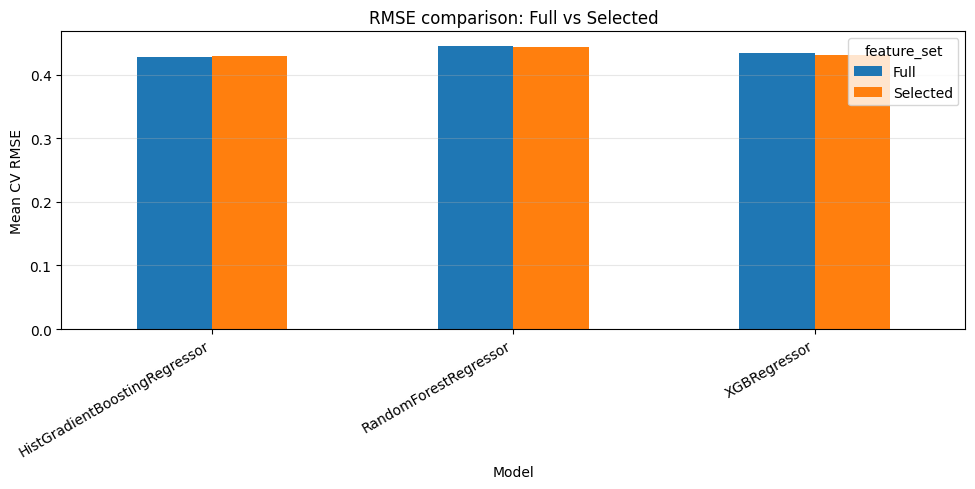

Saved: ml/outputs/price_modeling/charts/02_feature_selection_mae_comparison.png


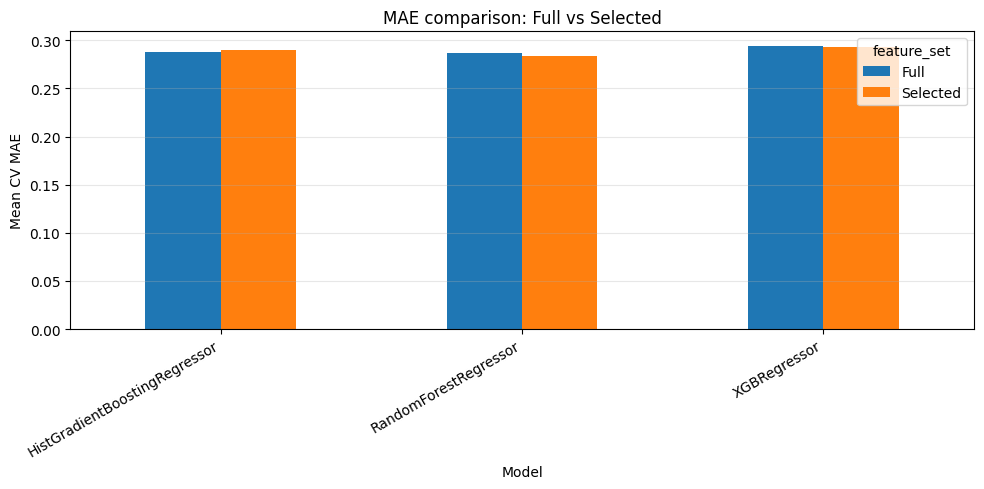

Saved: ml/outputs/price_modeling/charts/03_feature_selection_r2_comparison.png


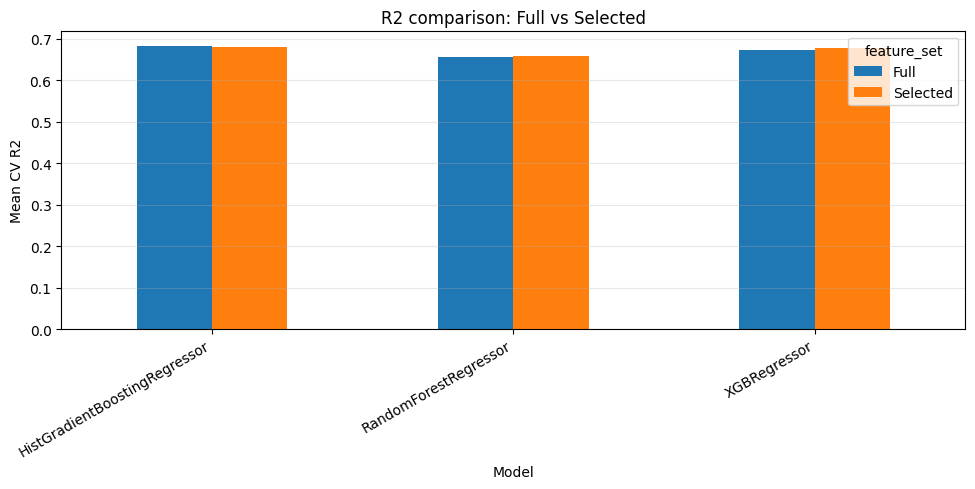

Saved: ml/outputs/price_modeling/charts/04_tree_feature_importance.png


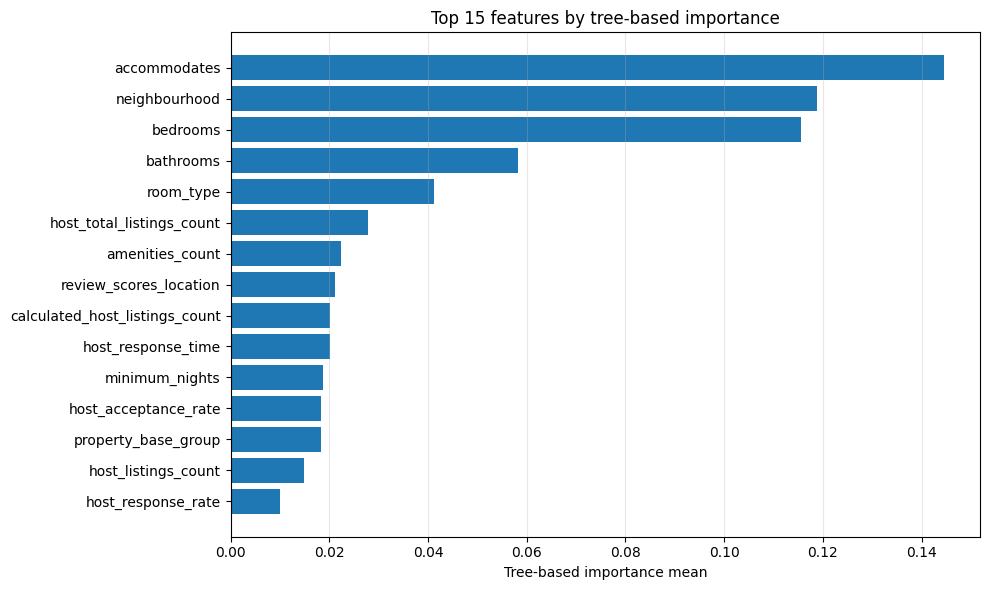

Saved: ml/outputs/price_modeling/charts/05_univariate_feature_score.png


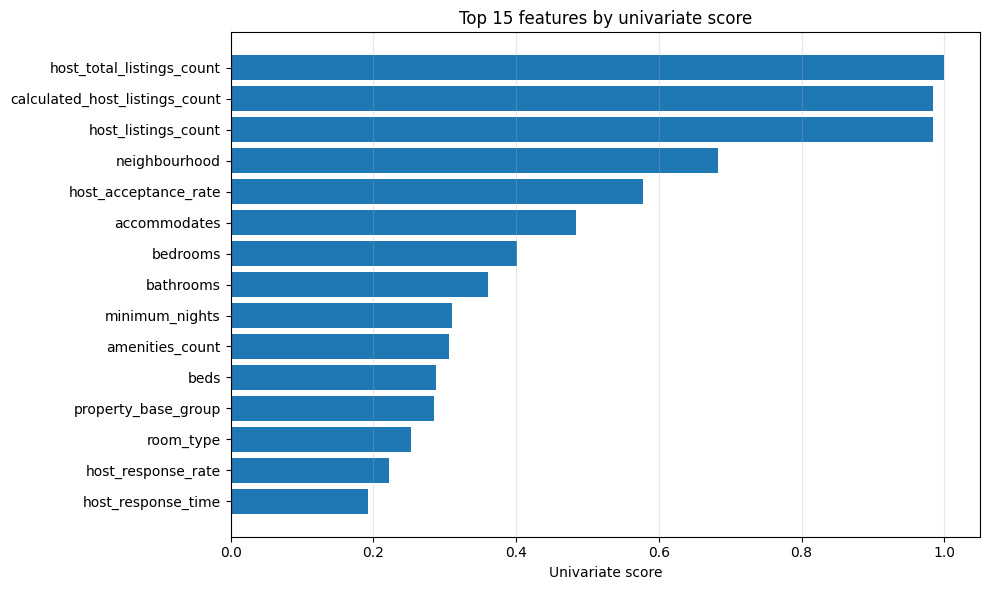

In [31]:
def plot_full_selected_metric(summary, metric, title, ylabel, filename):
    if summary.empty:
        print("No data available for plotting.")
        return

    plot_data = summary.pivot(index="model", columns="feature_set", values=metric)
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_data.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    save_figure(filename, fig)
    plt.show()
    plt.close(fig)


plot_full_selected_metric(
    feature_selection_model_summary,
    "rmse_mean",
    "RMSE comparison: Full vs Selected",
    "Mean CV RMSE",
    "01_feature_selection_rmse_comparison.png",
)
plot_full_selected_metric(
    feature_selection_model_summary,
    "mae_mean",
    "MAE comparison: Full vs Selected",
    "Mean CV MAE",
    "02_feature_selection_mae_comparison.png",
)
plot_full_selected_metric(
    feature_selection_model_summary,
    "r2_mean",
    "R2 comparison: Full vs Selected",
    "Mean CV R2",
    "03_feature_selection_r2_comparison.png",
)

if not tree_feature_summary.empty:
    top_tree_features = tree_feature_summary.sort_values("tree_importance_mean", ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_tree_features["feature"], top_tree_features["tree_importance_mean"])
    ax.invert_yaxis()
    ax.set_xlabel("Tree-based importance mean")
    ax.set_title("Top 15 features by tree-based importance")
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    save_figure("04_tree_feature_importance.png", fig)
    plt.show()
    plt.close(fig)

if not univariate_feature_summary.empty:
    top_univariate_features = univariate_feature_summary.sort_values("univariate_score", ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_univariate_features["feature"], top_univariate_features["univariate_score"])
    ax.invert_yaxis()
    ax.set_xlabel("Univariate score")
    ax.set_title("Top 15 features by univariate score")
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    save_figure("05_univariate_feature_score.png", fig)
    plt.show()
    plt.close(fig)


## Kết luận lựa chọn feature set

Full luôn được đưa vào danh sách ứng viên cuối cùng. Selected chỉ được đưa vào khi giảm đủ số lượng feature, không làm RMSE xấu đi vượt quá ngưỡng cho phép, không làm độ biến động của RMSE tăng mạnh và không khiến thời gian huấn luyện tăng quá mức.

In [32]:
MAX_RMSE_DEGRADATION_PCT = 0.01
MIN_FEATURE_REDUCTION_PCT = 0.10
MAX_RMSE_STD_INCREASE = 0.005
MAX_FIT_TIME_INCREASE_PCT = 0.20
MAX_FIT_TIME_INCREASE_SECONDS = 1.0

feature_selection_thresholds = {
    "max_rmse_degradation_pct": MAX_RMSE_DEGRADATION_PCT,
    "min_feature_reduction_pct": MIN_FEATURE_REDUCTION_PCT,
    "max_rmse_std_increase": MAX_RMSE_STD_INCREASE,
    "max_fit_time_increase_pct": MAX_FIT_TIME_INCREASE_PCT,
    "max_fit_time_increase_seconds": MAX_FIT_TIME_INCREASE_SECONDS,
}


def build_eligibility_reason(row):
    rejection_reasons = []
    if row["rmse_change_pct"] > MAX_RMSE_DEGRADATION_PCT:
        rejection_reasons.append("Rejected: RMSE degradation exceeded tolerance")
    if row["feature_reduction_pct"] < MIN_FEATURE_REDUCTION_PCT:
        rejection_reasons.append("Rejected: insufficient feature reduction")
    if row["rmse_std_change"] > MAX_RMSE_STD_INCREASE:
        rejection_reasons.append("Rejected: RMSE variability increased excessively")
    if (
        row["fit_time_change"] > MAX_FIT_TIME_INCREASE_SECONDS
        and row["fit_time_change_pct"] > MAX_FIT_TIME_INCREASE_PCT
    ):
        rejection_reasons.append("Rejected: fit time increased excessively")

    if rejection_reasons:
        return "; ".join(rejection_reasons)
    if row["rmse_change_pct"] < 0:
        return "Eligible: improved RMSE and reduced feature count"
    return "Eligible: RMSE degradation within 1% tolerance"


best_model_metrics = {}
best_model_parameters = {}

if feature_selection_model_summary.empty:
    best_feature_set = None
    best_model_after_feature_selection = None
    selected_feature_eligibility = pd.DataFrame()
    print("No feature selection results available for conclusion.")
else:
    selected_eligibility_rows = []
    for model_name in feature_selection_model_summary["model"].unique():
        model_rows = feature_selection_model_summary.query("model == @model_name")
        full_row = model_rows.query("feature_set == 'Full'")
        selected_row = model_rows.query("feature_set == 'Selected'")
        if full_row.empty or selected_row.empty:
            continue

        full_row = full_row.iloc[0]
        selected_row = selected_row.iloc[0]
        full_feature_count = full_row["n_selected_features"]
        selected_feature_count = selected_row["n_selected_features"]
        rmse_change_pct = (selected_row["rmse_mean"] - full_row["rmse_mean"]) / full_row["rmse_mean"]
        mae_change_pct = (selected_row["mae_mean"] - full_row["mae_mean"]) / full_row["mae_mean"]
        r2_change = selected_row["r2_mean"] - full_row["r2_mean"]
        rmse_std_change = selected_row["rmse_std"] - full_row["rmse_std"]
        feature_reduction_pct = (full_feature_count - selected_feature_count) / full_feature_count
        fit_time_change = selected_row["fit_time_mean"] - full_row["fit_time_mean"]
        fit_time_change_pct = fit_time_change / full_row["fit_time_mean"]
        selected_eligible = (
            rmse_change_pct <= MAX_RMSE_DEGRADATION_PCT
            and feature_reduction_pct >= MIN_FEATURE_REDUCTION_PCT
            and rmse_std_change <= MAX_RMSE_STD_INCREASE
            and (
                fit_time_change <= MAX_FIT_TIME_INCREASE_SECONDS
                or fit_time_change_pct <= MAX_FIT_TIME_INCREASE_PCT
            )
        )
        selected_eligibility_rows.append({
            "model": model_name,
            "selected_eligible": selected_eligible,
            "full_feature_count": full_feature_count,
            "selected_feature_count": selected_feature_count,
            "feature_reduction_pct": feature_reduction_pct,
            "rmse_change_pct": rmse_change_pct,
            "mae_change_pct": mae_change_pct,
            "r2_change": r2_change,
            "rmse_std_change": rmse_std_change,
            "fit_time_change": fit_time_change,
            "fit_time_change_pct": fit_time_change_pct,
        })

    selected_feature_eligibility = pd.DataFrame(selected_eligibility_rows)
    if not selected_feature_eligibility.empty:
        selected_feature_eligibility["eligibility_reason"] = selected_feature_eligibility.apply(
            build_eligibility_reason,
            axis=1,
        )
        selected_feature_eligibility = selected_feature_eligibility[[
            "model",
            "selected_eligible",
            "eligibility_reason",
            "full_feature_count",
            "selected_feature_count",
            "feature_reduction_pct",
            "rmse_change_pct",
            "mae_change_pct",
            "r2_change",
            "rmse_std_change",
            "fit_time_change",
            "fit_time_change_pct",
        ]]

    candidate_summary = feature_selection_model_summary.merge(
        selected_feature_eligibility[["model", "selected_eligible"]],
        on="model",
        how="left",
    )
    candidate_summary["candidate_allowed"] = (
        (candidate_summary["feature_set"] == "Full")
        | candidate_summary["selected_eligible"].fillna(False)
    )
    best_row = (
        candidate_summary
        .query("candidate_allowed")
        .sort_values(
            ["rmse_mean", "mae_mean", "r2_mean", "rmse_std"],
            ascending=[True, True, False, True],
        )
        .iloc[0]
    )

    best_feature_set = best_row["feature_set"]
    best_model_after_feature_selection = best_row["model"]
    best_model_metrics = best_row.to_dict()
    best_pipeline = make_candidate_pipelines(best_feature_set).get(best_model_after_feature_selection)
    if best_pipeline is not None:
        best_model_parameters = best_pipeline.named_steps["model"].get_params()

    print(f"Selected final feature set: {best_feature_set}")
    print(f"Best model after feature selection: {best_model_after_feature_selection}")
    print(f"CV RMSE: {best_row['rmse_mean']:.6f}")
    print(f"CV MAE: {best_row['mae_mean']:.6f}")
    print(f"CV R2: {best_row['r2_mean']:.6f}")
    print(f"Feature count: {len(all_original_features)} -> {best_row['n_selected_features']}")

save_dataframe(selected_feature_eligibility, "14_selected_feature_eligibility.csv")

save_json(
    {
        "run_started_at": RUN_STARTED_AT,
        "run_completed_at": datetime.now().isoformat(timespec="seconds"),
        "target": TARGET,
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "n_splits": N_SPLITS,
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "input_feature_count": len(X.columns),
        "original_model_feature_count": len(all_original_features),
        "selected_feature_count": len(selected_features),
        "best_model_name": best_model_after_feature_selection,
        "best_feature_set": best_feature_set,
        "best_model_metrics": best_model_metrics,
        "best_model_parameters": best_model_parameters,
        "selected_feature_eligibility": selected_feature_eligibility.to_dict(orient="records"),
        "feature_selection_thresholds": feature_selection_thresholds,
        "metrics": ["mae", "rmse", "r2", "adjusted_r2"],
        "xgboost_available": XGBOOST_AVAILABLE,
        "catboost_available": CATBOOST_AVAILABLE,
        "tree_importance_errors": tree_importance_errors,
        "output_directories": {
            key: format_output_path(path)
            for key, path in OUTPUT_DIRS.items()
        },
        "model_artifact_saved": False,
    },
    "02_modeling_run_metadata.json",
)

selected_feature_eligibility


Selected final feature set: Full
Best model after feature selection: HistGradientBoostingRegressor
CV RMSE: 0.427621
CV MAE: 0.288344
CV R2: 0.683504
Feature count: 29 -> 29
Saved: ml/outputs/price_modeling/csv/14_selected_feature_eligibility.csv
Saved: ml/outputs/price_modeling/metadata/02_modeling_run_metadata.json


,model,selected_eligible,eligibility_reason,full_feature_count,selected_feature_count,feature_reduction_pct,rmse_change_pct,mae_change_pct,r2_change,rmse_std_change,fit_time_change,fit_time_change_pct
0,HistGradientBoostingRegressor,True,Eligible: RMSE degradation within 1% tolerance,29,22,0.241379,0.005395,0.004505,-0.003355,-0.000244,-0.146,-0.053304
1,RandomForestRegressor,False,Rejected: fit time increased excessively,29,22,0.241379,-0.005086,-0.012255,0.003504,-0.000247,615.693,15.867967
2,XGBRegressor,False,Rejected: fit time increased excessively,29,22,0.241379,-0.005869,-0.004121,0.003885,-0.002463,3.541,1.101057


**Nhận xét:**
- Feature selection được đánh giá theo từng mô hình bằng cách so sánh Selected với Full dựa trên RMSE, MAE, R², độ ổn định của RMSE, mức giảm số lượng feature và thời gian huấn luyện. Selected chỉ được xem là ứng viên hợp lệ khi không làm giảm chất lượng mô hình vượt quá ngưỡng cho phép và thực sự giúp giảm số lượng feature; trong khi đó, Full luôn được giữ lại làm baseline an toàn. Mô hình cuối cùng được lựa chọn từ các ứng viên hợp lệ theo thứ tự ưu tiên RMSE, MAE, R² và RMSE std, sau đó chuyển sang bước lưu artifact, tạo dự đoán hoặc diễn giải insight.
Kết quả cho thấy việc giảm từ 29 xuống còn 22 feature, tương ứng giảm khoảng 24,14%, tạo ra tác động khác nhau đối với từng mô hình.

- Với HistGradientBoostingRegressor, tập Full đạt kết quả tốt hơn nhẹ so với Selected. RMSE tăng từ 0,427621 lên 0,429928 và MAE tăng từ 0,288344 lên 0,289643 khi sử dụng tập feature đã chọn. Mặc dù thời gian huấn luyện giảm nhẹ từ 3,746 giây xuống 3,543 giây, mức cải thiện về tốc độ không đủ lớn để bù lại sự suy giảm về độ chính xác. Vì vậy, tập Full phù hợp hơn với mô hình này.

- Đối với RandomForestRegressor, tập Selected giúp cải thiện nhẹ các chỉ số dự báo. MAE giảm từ 0,287313 xuống 0,283792, RMSE giảm từ 0,445948 xuống 0,443680 và R² tăng từ 0,655829 lên 0,659333. Tuy nhiên, thời gian huấn luyện tăng mạnh từ 45,988 giây lên 457,135 giây. Mức tăng bất thường này khiến tập Selected không được xem là ứng viên hợp lệ cho Random Forest, dù kết quả dự báo có cải thiện.

- Với XGBRegressor, tập Selected mang lại kết quả tốt hơn trên cả độ chính xác và tốc độ. RMSE giảm từ 0,434179 xuống 0,431631, MAE giảm từ 0,294620 xuống 0,293406 và R² tăng từ 0,673764 lên 0,677649. Đồng thời, thời gian huấn luyện giảm từ 3,408 giây xuống 2,394 giây. Do đó, tập Selected là lựa chọn phù hợp hơn đối với XGBRegressor.

- Xét trên toàn bộ các cấu hình hợp lệ, HistGradientBoostingRegressor sử dụng tập Full đạt RMSE thấp nhất là 0,427621 và R² cao nhất là 0,683504. Vì vậy, đây là cấu hình được lựa chọn làm mô hình tốt nhất sau bước feature selection. Kết quả này cho thấy feature selection không cải thiện đồng nhất trên tất cả mô hình và cần được đánh giá riêng cho từng thuật toán thay vì áp dụng một tập feature chung.

# Hyperparameter Tuning

## 1. Cấu hình tuning

In [39]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

required_tuning_objects = [
    "X_train",
    "y_train",
    "X_test",
    "y_test",
    "all_original_features",
    "selected_features",
    "preprocessor_native_missing",
    "selected_preprocessor_native_missing",
    "feature_selection_model_summary",
]
missing_tuning_objects = [name for name in required_tuning_objects if name not in globals()]
assert not missing_tuning_objects, f"Missing required objects: {missing_tuning_objects}"
assert len(all_original_features) > 0, "all_original_features must not be empty."
assert len(selected_features) > 0, "selected_features must not be empty."
assert TARGET == "log_price", "Hyperparameter tuning expects log_price as target."
assert N_SPLITS == 5, "Hyperparameter tuning uses 5-fold CV."
assert RANDOM_STATE == 42, "Hyperparameter tuning expects RANDOM_STATE=42."
assert XGBOOST_AVAILABLE, f"XGBoost is required for tuning: {globals().get('XGBOOST_IMPORT_ERROR', '')}"

full_feature_list = list(all_original_features)
selected_feature_list = list(selected_features)

# Follow the accepted feature-selection result per model:
# HGBR keeps Full features, while XGBoost uses the Selected feature subset.
tuning_model_feature_sets = {
    "HistGradientBoostingRegressor": "Full",
    "XGBRegressor": "Selected",
}
tuning_model_features = {
    "Full": full_feature_list,
    "Selected": selected_feature_list,
}

tuning_cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

tuning_output_dirs = {
    "csv": OUTPUT_DIRS["csv"],
    "charts": OUTPUT_DIRS["charts"],
    "models": OUTPUT_DIRS["models"],
    "metadata": OUTPUT_DIRS["metadata"],
}
for output_dir in tuning_output_dirs.values():
    output_dir.mkdir(parents=True, exist_ok=True)

print("Full features used for HGBR tuning:", len(full_feature_list))
print("Selected features used for XGB tuning:", len(selected_feature_list))
print("Tuning model feature sets:", tuning_model_feature_sets)
print("Tuning CV:", tuning_cv)


Full features used for HGBR tuning: 29
Selected features used for XGB tuning: 22
Tuning model feature sets: {'HistGradientBoostingRegressor': 'Full', 'XGBRegressor': 'Selected'}
Tuning CV: KFold(n_splits=5, random_state=42, shuffle=True)


## 2. Hàm đánh giá cross-validation

In [40]:
def get_tuning_feature_set_name(model_key):
    return tuning_model_feature_sets[model_key]


def get_tuning_feature_list(model_key):
    return tuning_model_features[get_tuning_feature_set_name(model_key)]


def get_tuning_preprocessor_for_model(model_key):
    feature_set_name = get_tuning_feature_set_name(model_key)
    if feature_set_name == "Full":
        preprocessor = clone(preprocessor_native_missing)
    else:
        preprocessor = clone(selected_preprocessor_native_missing)

    if model_key == "HistGradientBoostingRegressor":
        preprocessor.set_params(sparse_threshold=0.0)
    return preprocessor


def calculate_regression_metrics(y_true, y_pred):
    return {
        "rmse": calculate_rmse(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


def summarize_fold_metrics(fold_rows):
    fold_metrics = pd.DataFrame(fold_rows)
    return {
        "best_cv_rmse": fold_metrics["rmse"].mean(),
        "best_cv_mae": fold_metrics["mae"].mean(),
        "best_cv_r2": fold_metrics["r2"].mean(),
        "cv_rmse_std": fold_metrics["rmse"].std(ddof=1),
        "mean_fit_time": fold_metrics["fit_time_seconds"].mean(),
        "mean_best_iteration": fold_metrics["best_iteration"].dropna().mean()
        if "best_iteration" in fold_metrics else np.nan,
    }


def build_hgbr_model(params):
    supported_params = HistGradientBoostingRegressor().get_params().keys()
    base_params = {
        "early_stopping": True,
        "validation_fraction": 0.1,
        "n_iter_no_change": HGB_N_ITER_NO_CHANGE,
        "tol": 1e-4,
        "max_iter": HGB_MAX_ITER,
        "random_state": RANDOM_STATE,
    }
    model_params = {**base_params, **params}
    model_params = {key: value for key, value in model_params.items() if key in supported_params}
    return HistGradientBoostingRegressor(**model_params)


def build_xgb_model(params, *, n_estimators=XGB_MAX_ESTIMATORS, early_stopping=True):
    model_params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "tree_method": "hist",
        "n_estimators": n_estimators,
        "random_state": RANDOM_STATE,
        "n_jobs": N_JOBS,
        **params,
    }
    if early_stopping:
        model_params["early_stopping_rounds"] = EARLY_STOPPING_ROUNDS
    return XGBRegressor(**model_params)


def get_xgb_best_iteration(model):
    best_iteration = getattr(model, "best_iteration", None)
    if best_iteration is None:
        booster = model.get_booster()
        best_iteration = getattr(booster, "best_iteration", None)
    if best_iteration is None:
        return np.nan
    return int(best_iteration)


def get_trial_fold_rows(trial, model_name):
    return trial.user_attrs.get(f"{model_name}_fold_rows", [])


## 3. Tuning HistGradientBoostingRegressor

In [41]:
def suggest_hgbr_params(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.20, log=True),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 63),
        "max_depth": trial.suggest_categorical("max_depth", [None, 4, 6, 8, 10, 12]),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 60),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 10.0, log=True),
        "max_bins": trial.suggest_categorical("max_bins", [63, 127, 255]),
    }


def objective_hgbr(trial):
    model_name = "HistGradientBoostingRegressor"
    feature_set_name = get_tuning_feature_set_name(model_name)
    model_feature_list = get_tuning_feature_list(model_name)
    params = suggest_hgbr_params(trial)
    fold_rows = []
    rmse_values = []

    for fold_index, (train_index, validation_index) in enumerate(tuning_cv.split(X_train, y_train), start=1):
        X_fold_train = X_train.iloc[train_index][model_feature_list]
        X_fold_validation = X_train.iloc[validation_index][model_feature_list]
        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]

        preprocessor = get_tuning_preprocessor_for_model(model_name)
        model = build_hgbr_model(params)

        fit_start = time.perf_counter()
        X_fold_train_transformed = preprocessor.fit_transform(X_fold_train)
        X_fold_validation_transformed = preprocessor.transform(X_fold_validation)
        model.fit(X_fold_train_transformed, y_fold_train)
        fit_time = time.perf_counter() - fit_start

        y_pred = model.predict(X_fold_validation_transformed)
        metrics = calculate_regression_metrics(y_fold_validation, y_pred)
        rmse_values.append(metrics["rmse"])

        fold_rows.append({
            "model": model_name,
            "feature_set": feature_set_name,
            "trial_number": trial.number,
            "fold": fold_index,
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
            "fit_time_seconds": fit_time,
            "best_iteration": getattr(model, "n_iter_", np.nan),
        })

        current_mean_rmse = float(np.mean(rmse_values))
        trial.report(current_mean_rmse, step=fold_index)
        if trial.should_prune():
            trial.set_user_attr("HistGradientBoostingRegressor_fold_rows", fold_rows)
            raise optuna.TrialPruned()

    trial.set_user_attr("HistGradientBoostingRegressor_fold_rows", fold_rows)
    trial.set_user_attr("best_cv_mae", float(np.mean([row["mae"] for row in fold_rows])))
    trial.set_user_attr("best_cv_r2", float(np.mean([row["r2"] for row in fold_rows])))
    trial.set_user_attr("cv_rmse_std", float(np.std(rmse_values, ddof=1)))
    trial.set_user_attr("mean_fit_time", float(np.mean([row["fit_time_seconds"] for row in fold_rows])))
    trial.set_user_attr("mean_best_iteration", float(np.nanmean([row["best_iteration"] for row in fold_rows])))
    return float(np.mean(rmse_values))


hgbr_tuning_start = time.perf_counter()
hgbr_study = optuna.create_study(
    study_name="hgbr_full_rmse",
    direction="minimize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2),
)
hgbr_study.optimize(
    objective_hgbr,
    n_trials=N_TRIALS_HGBR,
    timeout=TUNING_TIMEOUT,
    n_jobs=1,
    show_progress_bar=True,
)
hgbr_tuning_time_seconds = time.perf_counter() - hgbr_tuning_start
hgbr_best_fold_rows = get_trial_fold_rows(hgbr_study.best_trial, "HistGradientBoostingRegressor")
hgbr_best_fold_results = pd.DataFrame(hgbr_best_fold_rows)

print("Best HGBR feature set:", get_tuning_feature_set_name("HistGradientBoostingRegressor"))
print("Best HGBR CV RMSE:", round(hgbr_study.best_value, 6))
print("Best HGBR params:", hgbr_study.best_params)
print("Completed trials:", sum(trial.state == optuna.trial.TrialState.COMPLETE for trial in hgbr_study.trials))
print("Pruned trials:", sum(trial.state == optuna.trial.TrialState.PRUNED for trial in hgbr_study.trials))
print("Tuning time seconds:", round(hgbr_tuning_time_seconds, 2))
print("Best trial fold RMSE:", hgbr_best_fold_results["rmse"].round(6).tolist())


  0%|          | 0/30 [00:00<?, ?it/s]

Best HGBR feature set: Full
Best HGBR CV RMSE: 0.421738
Best HGBR params: {'learning_rate': 0.05632931184860345, 'max_leaf_nodes': 59, 'max_depth': None, 'min_samples_leaf': 26, 'l2_regularization': 0.0002500332825499957, 'max_bins': 255}
Completed trials: 17
Pruned trials: 13
Tuning time seconds: 830.55
Best trial fold RMSE: [0.41648, 0.409979, 0.424926, 0.439235, 0.418068]


## 4. Tuning XGBRegressor

In [42]:
def suggest_xgb_params(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
    }


def objective_xgb(trial):
    model_name = "XGBRegressor"
    feature_set_name = get_tuning_feature_set_name(model_name)
    model_feature_list = get_tuning_feature_list(model_name)
    params = suggest_xgb_params(trial)
    fold_rows = []
    rmse_values = []

    for fold_index, (train_index, validation_index) in enumerate(tuning_cv.split(X_train, y_train), start=1):
        X_fold_train = X_train.iloc[train_index][model_feature_list]
        X_fold_validation = X_train.iloc[validation_index][model_feature_list]
        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]

        preprocessor = get_tuning_preprocessor_for_model(model_name)
        fit_start = time.perf_counter()
        X_fold_train_transformed = preprocessor.fit_transform(X_fold_train)
        X_fold_validation_transformed = preprocessor.transform(X_fold_validation)

        model = build_xgb_model(params)
        model.fit(
            X_fold_train_transformed,
            y_fold_train,
            eval_set=[(X_fold_validation_transformed, y_fold_validation)],
            verbose=False,
        )
        fit_time = time.perf_counter() - fit_start

        y_pred = model.predict(X_fold_validation_transformed)
        metrics = calculate_regression_metrics(y_fold_validation, y_pred)
        rmse_values.append(metrics["rmse"])
        best_iteration = get_xgb_best_iteration(model)

        fold_rows.append({
            "model": model_name,
            "feature_set": feature_set_name,
            "trial_number": trial.number,
            "fold": fold_index,
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
            "fit_time_seconds": fit_time,
            "best_iteration": best_iteration,
            "best_n_estimators": best_iteration + 1 if not np.isnan(best_iteration) else np.nan,
        })

        current_mean_rmse = float(np.mean(rmse_values))
        trial.report(current_mean_rmse, step=fold_index)
        if trial.should_prune():
            trial.set_user_attr("XGBRegressor_fold_rows", fold_rows)
            raise optuna.TrialPruned()

    trial.set_user_attr("XGBRegressor_fold_rows", fold_rows)
    trial.set_user_attr("best_cv_mae", float(np.mean([row["mae"] for row in fold_rows])))
    trial.set_user_attr("best_cv_r2", float(np.mean([row["r2"] for row in fold_rows])))
    trial.set_user_attr("cv_rmse_std", float(np.std(rmse_values, ddof=1)))
    trial.set_user_attr("mean_fit_time", float(np.mean([row["fit_time_seconds"] for row in fold_rows])))
    trial.set_user_attr("mean_best_iteration", float(np.nanmean([row["best_iteration"] for row in fold_rows])))
    return float(np.mean(rmse_values))


xgb_tuning_start = time.perf_counter()
xgb_study = optuna.create_study(
    study_name="xgb_selected_rmse",
    direction="minimize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2),
)
xgb_study.optimize(
    objective_xgb,
    n_trials=N_TRIALS_XGB,
    timeout=TUNING_TIMEOUT,
    n_jobs=1,
    show_progress_bar=True,
)
xgb_tuning_time_seconds = time.perf_counter() - xgb_tuning_start
xgb_best_fold_rows = get_trial_fold_rows(xgb_study.best_trial, "XGBRegressor")
xgb_best_fold_results = pd.DataFrame(xgb_best_fold_rows)

print("Best XGB feature set:", get_tuning_feature_set_name("XGBRegressor"))
print("Best XGB CV RMSE:", round(xgb_study.best_value, 6))
print("Best XGB params:", xgb_study.best_params)
print("Completed trials:", sum(trial.state == optuna.trial.TrialState.COMPLETE for trial in xgb_study.trials))
print("Pruned trials:", sum(trial.state == optuna.trial.TrialState.PRUNED for trial in xgb_study.trials))
print("Tuning time seconds:", round(xgb_tuning_time_seconds, 2))
print("Best trial fold RMSE:", xgb_best_fold_results["rmse"].round(6).tolist())


  0%|          | 0/30 [00:00<?, ?it/s]

Best XGB feature set: Selected
Best XGB CV RMSE: 0.409269
Best XGB params: {'learning_rate': 0.018103950419565393, 'max_depth': 7, 'min_child_weight': 3, 'subsample': 0.7730982444721965, 'colsample_bytree': 0.847910950256661, 'gamma': 0.1010314624038641, 'reg_alpha': 0.0023061715793567497, 'reg_lambda': 0.09587856471308707}
Completed trials: 12
Pruned trials: 18
Tuning time seconds: 1660.84
Best trial fold RMSE: [0.40756, 0.400377, 0.411441, 0.422113, 0.404853]


## 5. Tổng hợp kết quả tuning

In [43]:
def study_trials_to_dataframe(study, model_name):
    rows = []
    for trial in study.trials:
        row = {
            "model": model_name,
            "feature_set": get_tuning_feature_set_name(model_name),
            "trial_number": trial.number,
            "state": trial.state.name,
            "value": trial.value,
            "duration_seconds": trial.duration.total_seconds() if trial.duration else np.nan,
            **trial.params,
        }
        row.update(trial.user_attrs)
        rows.append(row)
    return pd.DataFrame(rows)


def get_baseline_rmse(model_name, feature_set_name):
    if "feature_selection_model_summary" not in globals() or feature_selection_model_summary.empty:
        return np.nan
    baseline_rows = feature_selection_model_summary.query(
        "model == @model_name and feature_set == @feature_set_name"
    )
    if baseline_rows.empty:
        return np.nan
    return float(baseline_rows.iloc[0]["rmse_mean"])


def build_study_summary_row(study, model_name, tuning_time_seconds):
    feature_set_name = get_tuning_feature_set_name(model_name)
    best_trial = study.best_trial
    fold_results = pd.DataFrame(get_trial_fold_rows(best_trial, model_name))
    summary = summarize_fold_metrics(fold_results)
    baseline_rmse = get_baseline_rmse(model_name, feature_set_name)
    rmse_improvement = baseline_rmse - summary["best_cv_rmse"] if not np.isnan(baseline_rmse) else np.nan
    return {
        "model": model_name,
        "feature_set": feature_set_name,
        "n_trials": len(study.trials),
        "completed_trials": sum(trial.state == optuna.trial.TrialState.COMPLETE for trial in study.trials),
        "pruned_trials": sum(trial.state == optuna.trial.TrialState.PRUNED for trial in study.trials),
        **summary,
        "best_params": best_trial.params,
        "tuning_time_seconds": tuning_time_seconds,
        "baseline_rmse": baseline_rmse,
        "rmse_improvement": rmse_improvement,
        "rmse_improvement_pct": rmse_improvement / baseline_rmse if baseline_rmse and not np.isnan(baseline_rmse) else np.nan,
    }


hgbr_trials = study_trials_to_dataframe(hgbr_study, "HistGradientBoostingRegressor")
xgb_trials = study_trials_to_dataframe(xgb_study, "XGBRegressor")

save_dataframe(hgbr_trials, "10_hgbr_optuna_trials.csv")
save_dataframe(xgb_trials, "11_xgb_optuna_trials.csv")

tuning_summary = pd.DataFrame([
    build_study_summary_row(hgbr_study, "HistGradientBoostingRegressor", hgbr_tuning_time_seconds),
    build_study_summary_row(xgb_study, "XGBRegressor", xgb_tuning_time_seconds),
])

tuning_summary_display = tuning_summary.copy()
tuning_summary_display["best_params"] = tuning_summary_display["best_params"].apply(json.dumps)
save_dataframe(tuning_summary_display, "12_tuning_summary.csv")
tuning_summary


Saved: ml/outputs/price_modeling/csv/10_hgbr_optuna_trials.csv
Saved: ml/outputs/price_modeling/csv/11_xgb_optuna_trials.csv
Saved: ml/outputs/price_modeling/csv/12_tuning_summary.csv


,model,feature_set,n_trials,completed_trials,pruned_trials,best_cv_rmse,best_cv_mae,best_cv_r2,cv_rmse_std,mean_fit_time,mean_best_iteration,best_params,tuning_time_seconds,baseline_rmse,rmse_improvement,rmse_improvement_pct
0,HistGradientBoostingRegressor,Full,30,17,13,0.421738,0.280176,0.692189,0.011132,10.266496,372.6,"{'learning_rate': 0.05632931184860345, 'max_le...",830.554991,0.427621,0.005883,0.013758
1,XGBRegressor,Selected,30,12,18,0.409269,0.269299,0.710175,0.008233,32.810239,1956.0,"{'learning_rate': 0.018103950419565393, 'max_d...",1660.844242,0.431631,0.022362,0.051808


## 6. Chọn mô hình tốt nhất theo CV RMSE

In [44]:
selection_tolerance = 1e-6
candidate_tuning_summary = tuning_summary.sort_values(
    ["best_cv_rmse", "cv_rmse_std", "mean_fit_time", "model"],
    ascending=[True, True, True, True],
).reset_index(drop=True)

best_tuned_model_row = candidate_tuning_summary.iloc[0]
best_tuned_model_name = best_tuned_model_row["model"]
best_tuned_params = best_tuned_model_row["best_params"]

if best_tuned_model_name == "HistGradientBoostingRegressor":
    best_tuned_study = hgbr_study
    best_tuned_cv_folds = hgbr_best_fold_results.copy()
else:
    best_tuned_study = xgb_study
    best_tuned_cv_folds = xgb_best_fold_results.copy()

save_dataframe(best_tuned_cv_folds, "13_best_tuned_cv_folds.csv")
print("Best tuned model:", best_tuned_model_name)
print("Best CV RMSE:", round(best_tuned_model_row["best_cv_rmse"], 6))
print("Best params:", best_tuned_params)


Saved: ml/outputs/price_modeling/csv/13_best_tuned_cv_folds.csv
Best tuned model: XGBRegressor
Best CV RMSE: 0.409269
Best params: {'learning_rate': 0.018103950419565393, 'max_depth': 7, 'min_child_weight': 3, 'subsample': 0.7730982444721965, 'colsample_bytree': 0.847910950256661, 'gamma': 0.1010314624038641, 'reg_alpha': 0.0023061715793567497, 'reg_lambda': 0.09587856471308707}


## 7. Huấn luyện mô hình cuối cùng

In [45]:
best_tuned_feature_set = best_tuned_model_row["feature_set"]
final_feature_list = get_tuning_feature_list(best_tuned_model_name)
final_preprocessor = get_tuning_preprocessor_for_model(best_tuned_model_name)
X_train_final = X_train[final_feature_list]
X_test_final = X_test[final_feature_list]

final_fit_start = time.perf_counter()

if best_tuned_model_name == "HistGradientBoostingRegressor":
    final_model = build_hgbr_model(best_tuned_params)
    final_pipeline = Pipeline(steps=[
        ("preprocessor", final_preprocessor),
        ("model", final_model),
    ])
    final_pipeline.fit(X_train_final, y_train)
    final_iteration_value = getattr(final_pipeline.named_steps["model"], "n_iter_", np.nan)
    final_n_estimators = np.nan
else:
    best_n_estimators_per_fold = best_tuned_cv_folds["best_n_estimators"].dropna().to_numpy()
    assert len(best_n_estimators_per_fold) > 0, "XGB best_n_estimators from CV must be available."
    final_n_estimators = int(np.median(best_n_estimators_per_fold))
    final_model = build_xgb_model(
        best_tuned_params,
        n_estimators=final_n_estimators,
        early_stopping=False,
    )
    final_pipeline = Pipeline(steps=[
        ("preprocessor", final_preprocessor),
        ("model", final_model),
    ])
    final_pipeline.fit(X_train_final, y_train)
    final_iteration_value = final_n_estimators

final_fit_time_seconds = time.perf_counter() - final_fit_start

final_model_artifact = {
    "model_name": best_tuned_model_name,
    "feature_set": best_tuned_feature_set,
    "model_features": final_feature_list,
    "selected_features": selected_feature_list,
    "pipeline": final_pipeline,
    "target_transform": "log1p",
    "inverse_transform": "expm1",
}

print("Final model:", best_tuned_model_name)
print("Final feature set:", best_tuned_feature_set)
print("Final fit time seconds:", round(final_fit_time_seconds, 2))
print("Final iteration/tree count:", final_iteration_value)


Final model: XGBRegressor
Final feature set: Selected
Final fit time seconds: 108.62
Final iteration/tree count: 1997


## 8. Đánh giá duy nhất trên tập test

In [46]:
predicted_log_price = final_pipeline.predict(X_test_final)
actual_log_price = y_test.to_numpy()

final_test_metrics = {
    "model": best_tuned_model_name,
    "feature_set": best_tuned_feature_set,
    "rmse_log": calculate_rmse(actual_log_price, predicted_log_price),
    "mae_log": mean_absolute_error(actual_log_price, predicted_log_price),
    "r2_log": r2_score(actual_log_price, predicted_log_price),
}

actual_price = np.expm1(actual_log_price)
predicted_price = np.maximum(np.expm1(predicted_log_price), 0)
final_test_metrics["rmse_price"] = calculate_rmse(actual_price, predicted_price)
final_test_metrics["mae_price"] = mean_absolute_error(actual_price, predicted_price)

final_test_metrics_df = pd.DataFrame([final_test_metrics])

final_test_predictions = pd.DataFrame({
    "actual_log_price": actual_log_price,
    "predicted_log_price": predicted_log_price,
    "residual_log": actual_log_price - predicted_log_price,
    "actual_price": actual_price,
    "predicted_price": predicted_price,
    "absolute_error_price": np.abs(actual_price - predicted_price),
}, index=y_test.index)

if "meta_test" in globals() and "listing_id" in meta_test.columns:
    final_test_predictions.insert(0, "listing_id", meta_test.loc[y_test.index, "listing_id"].to_numpy())

final_test_metrics_df


,model,feature_set,rmse_log,mae_log,r2_log,rmse_price,mae_price
0,XGBRegressor,Selected,0.406715,0.265202,0.707021,20133.799876,1132.965122


## 9. Lưu kết quả và model artifact

In [47]:
best_hyperparameters = pd.DataFrame([
    {
        "model": "HistGradientBoostingRegressor",
        "feature_set": get_tuning_feature_set_name("HistGradientBoostingRegressor"),
        "best_params": json.dumps(hgbr_study.best_params),
        "best_cv_rmse": hgbr_study.best_value,
    },
    {
        "model": "XGBRegressor",
        "feature_set": get_tuning_feature_set_name("XGBRegressor"),
        "best_params": json.dumps(xgb_study.best_params),
        "best_cv_rmse": xgb_study.best_value,
    },
])

save_dataframe(final_test_metrics_df, "14_final_test_metrics.csv")
save_dataframe(final_test_predictions.reset_index(names="row_index"), "15_final_test_predictions.csv")
save_dataframe(best_hyperparameters, "16_best_hyperparameters.csv")

final_model_path = OUTPUT_DIRS["models"] / "final_price_model.joblib"
joblib.dump(final_model_artifact, final_model_path)
print(f"Saved: {format_output_path(final_model_path)}")

final_metadata = {
    "model_name": best_tuned_model_name,
    "feature_set": best_tuned_feature_set,
    "model_features": final_feature_list,
    "selected_features": selected_feature_list,
    "best_params": best_tuned_params,
    "cv_rmse": best_tuned_model_row["best_cv_rmse"],
    "cv_rmse_std": best_tuned_model_row["cv_rmse_std"],
    "test_rmse_log": final_test_metrics["rmse_log"],
    "test_mae_log": final_test_metrics["mae_log"],
    "test_r2_log": final_test_metrics["r2_log"],
    "test_rmse_price": final_test_metrics["rmse_price"],
    "test_mae_price": final_test_metrics["mae_price"],
    "final_n_estimators": final_n_estimators,
    "n_iter_": final_iteration_value if best_tuned_model_name == "HistGradientBoostingRegressor" else np.nan,
    "random_state": RANDOM_STATE,
    "target_column": TARGET,
    "target_transform": "log1p",
    "inverse_transform": "expm1",
    "created_at": datetime.now().isoformat(timespec="seconds"),
}

final_metadata_path = OUTPUT_DIRS["models"] / "final_price_model_metadata.json"
with final_metadata_path.open("w", encoding="utf-8") as file:
    json.dump(final_metadata, file, indent=4, ensure_ascii=False, default=json_default)
print(f"Saved: {format_output_path(final_metadata_path)}")


Saved: ml/outputs/price_modeling/csv/14_final_test_metrics.csv
Saved: ml/outputs/price_modeling/csv/15_final_test_predictions.csv
Saved: ml/outputs/price_modeling/csv/16_best_hyperparameters.csv
Saved: ml/outputs/price_modeling/models/final_price_model.joblib
Saved: ml/outputs/price_modeling/models/final_price_model_metadata.json


## 10. Biểu đồ

Saved: ml/outputs/price_modeling/charts/06_hgbr_optimization_history.png


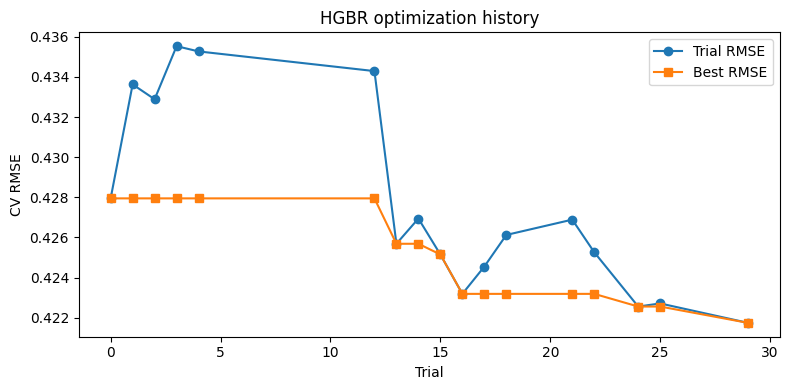

Saved: ml/outputs/price_modeling/charts/07_xgb_optimization_history.png


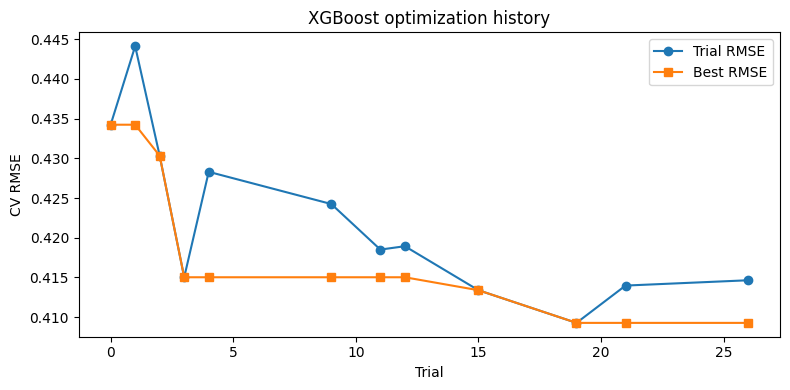

Saved: ml/outputs/price_modeling/charts/08_hgbr_parameter_importance.png


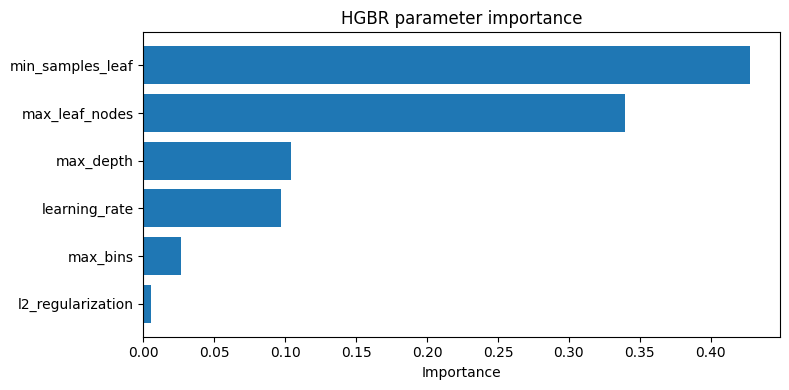

Saved: ml/outputs/price_modeling/charts/09_xgb_parameter_importance.png


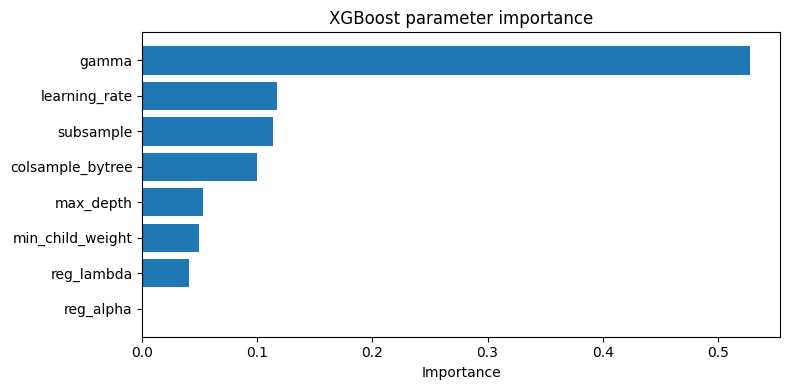

Saved: ml/outputs/price_modeling/charts/10_baseline_vs_tuned_rmse.png


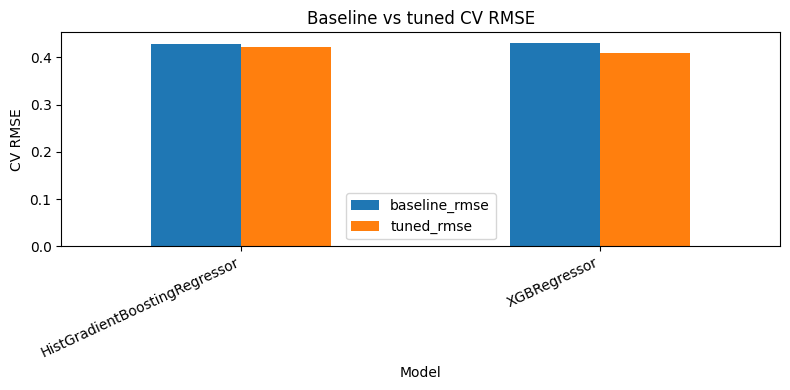

Saved: ml/outputs/price_modeling/charts/11_final_predicted_vs_actual_price.png


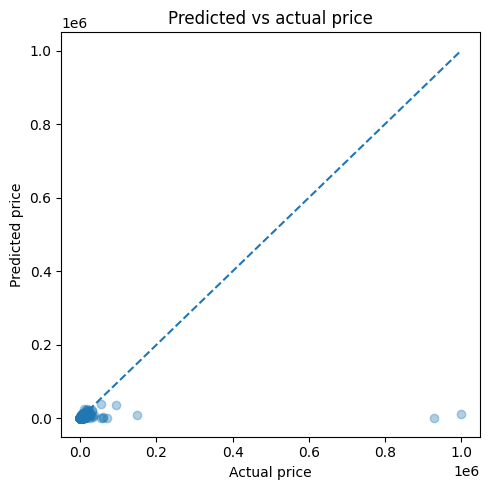

Saved: ml/outputs/price_modeling/charts/12_final_residual_distribution.png


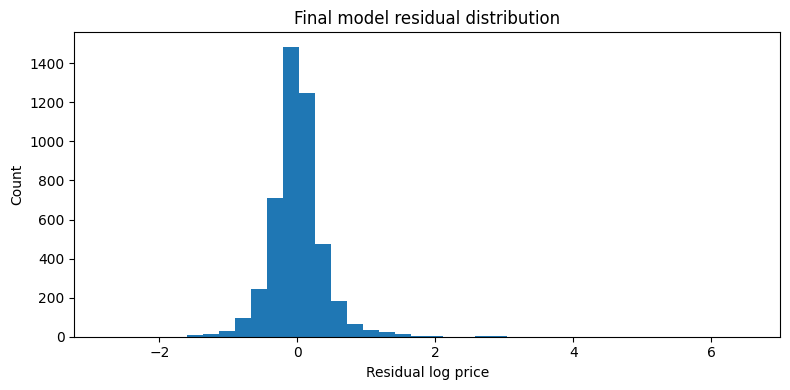

In [48]:
def save_tuning_plot(filename):
    output_path = OUTPUT_DIRS["charts"] / filename
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {format_output_path(output_path)}")
    plt.show()


def plot_optimization_history(study, title, filename):
    complete_trials = [trial for trial in study.trials if trial.state == optuna.trial.TrialState.COMPLETE]
    if not complete_trials:
        print(f"No completed trials for {title}.")
        return
    trial_numbers = [trial.number for trial in complete_trials]
    values = [trial.value for trial in complete_trials]
    best_values = np.minimum.accumulate(values)
    plt.figure(figsize=(8, 4))
    plt.plot(trial_numbers, values, marker="o", label="Trial RMSE")
    plt.plot(trial_numbers, best_values, marker="s", label="Best RMSE")
    plt.title(title)
    plt.xlabel("Trial")
    plt.ylabel("CV RMSE")
    plt.legend()
    save_tuning_plot(filename)


def plot_param_importance(study, title, filename):
    complete_trials = [trial for trial in study.trials if trial.state == optuna.trial.TrialState.COMPLETE]
    if len(complete_trials) < 2:
        print(f"Not enough completed trials for parameter importance: {title}.")
        return
    importances = get_param_importances(study)
    if not importances:
        print(f"No parameter importance available for {title}.")
        return
    importance_df = pd.DataFrame({
        "parameter": list(importances.keys()),
        "importance": list(importances.values()),
    }).sort_values("importance")
    plt.figure(figsize=(8, 4))
    plt.barh(importance_df["parameter"], importance_df["importance"])
    plt.title(title)
    plt.xlabel("Importance")
    save_tuning_plot(filename)


plot_optimization_history(hgbr_study, "HGBR optimization history", "06_hgbr_optimization_history.png")
plot_optimization_history(xgb_study, "XGBoost optimization history", "07_xgb_optimization_history.png")
plot_param_importance(hgbr_study, "HGBR parameter importance", "08_hgbr_parameter_importance.png")
plot_param_importance(xgb_study, "XGBoost parameter importance", "09_xgb_parameter_importance.png")

baseline_tuned_plot = tuning_summary[["model", "baseline_rmse", "best_cv_rmse"]].copy()
baseline_tuned_plot = baseline_tuned_plot.rename(columns={"best_cv_rmse": "tuned_rmse"})
baseline_tuned_plot = baseline_tuned_plot.set_index("model")
plt.figure(figsize=(8, 4))
baseline_tuned_plot.plot(kind="bar", ax=plt.gca())
plt.title("Baseline vs tuned CV RMSE")
plt.xlabel("Model")
plt.ylabel("CV RMSE")
plt.xticks(rotation=25, ha="right")
save_tuning_plot("10_baseline_vs_tuned_rmse.png")

plt.figure(figsize=(5, 5))
plt.scatter(actual_price, predicted_price, alpha=0.35)
price_limit = max(np.nanmax(actual_price), np.nanmax(predicted_price))
plt.plot([0, price_limit], [0, price_limit], linestyle="--")
plt.title("Predicted vs actual price")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
save_tuning_plot("11_final_predicted_vs_actual_price.png")

plt.figure(figsize=(8, 4))
plt.hist(final_test_predictions["residual_log"], bins=40)
plt.title("Final model residual distribution")
plt.xlabel("Residual log price")
plt.ylabel("Count")
save_tuning_plot("12_final_residual_distribution.png")


**Nhận xét:**

- Sau khi tuning bằng Optuna, `XGBRegressor` với tập feature `Selected` là cấu hình tốt nhất theo CV RMSE. Mô hình này đạt CV RMSE = `0.409269`, thấp hơn `HistGradientBoostingRegressor` với tập `Full` có CV RMSE = `0.421738`. Như vậy, dù HGBR là mô hình tốt nhất sau Feature Selection, bước tuning đã giúp XGBoost vượt lên rõ ràng hơn trên cross-validation.

- So với baseline tương ứng của từng mô hình, HGBR giảm RMSE từ `0.427621` xuống `0.421738`, tương ứng cải thiện khoảng `1.38%`. XGBoost giảm RMSE từ `0.431631` xuống `0.409269`, tương ứng cải thiện khoảng `5.18%`. Mức cải thiện của XGBoost đáng kể hơn, cho thấy mô hình này nhạy với hyperparameter và hưởng lợi nhiều hơn từ Bayesian Optimization.

- Best params của XGBoost dùng learning rate khá thấp (`0.0181`) và số cây cuối cùng khi refit là `1997`, gần giới hạn `XGB_MAX_ESTIMATORS = 2000`. Điều này cho thấy mô hình cần nhiều boosting rounds để hội tụ với learning rate nhỏ. Kết quả này hợp lý, nhưng cũng là dấu hiệu nên theo dõi thêm thời gian huấn luyện nếu mở rộng dữ liệu hoặc tăng số trial.

- Trên tập test, mô hình cuối cùng đạt RMSE log = `0.406715`, MAE log = `0.265202`, R² = `0.707021`. Test RMSE log thấp hơn nhẹ so với CV RMSE (`0.406715` so với `0.409269`), nên chưa thấy dấu hiệu overfitting rõ ràng từ kết quả tổng thể. Tuy nhiên, kết luận này chỉ ở mức tổng quan; cần phân tích residual và các nhóm listing cụ thể ở phần Error Analysis phía sau.

- Trên price scale, RMSE = `20,133.80 THB` trong khi MAE = `1,132.97 THB`. Khoảng cách rất lớn giữa RMSE và MAE cho thấy có thể tồn tại một số listing sai số rất lớn hoặc outlier giá cao làm RMSE bị kéo lên mạnh. Vì vậy, phần Error Analysis cần tập trung kiểm tra top errors, phân khúc giá cao, neighbourhood, room type và property group để xem sai số tập trung ở đâu.


# Error Analysis

## 1. Chuẩn bị dữ liệu sai số

In [49]:
error_predictions_path = OUTPUT_DIRS["csv"] / "15_final_test_predictions.csv"

if "final_test_predictions" in globals():
    error_predictions_base = final_test_predictions.copy()
else:
    assert error_predictions_path.exists(), f"Missing prediction file: {error_predictions_path}"
    error_predictions_base = pd.read_csv(error_predictions_path)

if "row_index" not in error_predictions_base.columns:
    error_predictions_base = error_predictions_base.copy()
    error_predictions_base.insert(0, "row_index", error_predictions_base.index)

required_prediction_columns = [
    "actual_log_price",
    "predicted_log_price",
    "actual_price",
    "predicted_price",
]
missing_prediction_columns = [
    column for column in required_prediction_columns
    if column not in error_predictions_base.columns
]
assert not missing_prediction_columns, f"Missing prediction columns: {missing_prediction_columns}"
assert len(error_predictions_base) == len(y_test), "Prediction row count must match test row count."
assert error_predictions_base[required_prediction_columns].notna().all().all(), "Missing actual/predicted values."
assert (error_predictions_base["actual_price"] > 0).all(), "actual_price must be positive."

error_analysis_predictions = error_predictions_base.copy()
error_analysis_predictions["residual_log"] = (
    error_analysis_predictions["actual_log_price"]
    - error_analysis_predictions["predicted_log_price"]
)
error_analysis_predictions["absolute_error_log"] = error_analysis_predictions["residual_log"].abs()
error_analysis_predictions["residual_price"] = (
    error_analysis_predictions["actual_price"]
    - error_analysis_predictions["predicted_price"]
)
error_analysis_predictions["absolute_error_price"] = error_analysis_predictions["residual_price"].abs()
error_analysis_predictions["relative_error_price"] = (
    error_analysis_predictions["absolute_error_price"]
    / error_analysis_predictions["actual_price"]
)
error_analysis_predictions["absolute_percentage_error"] = (
    error_analysis_predictions["relative_error_price"] * 100
)
error_analysis_predictions["prediction_direction"] = np.select(
    [
        error_analysis_predictions["residual_price"] > 0,
        error_analysis_predictions["residual_price"] < 0,
    ],
    [
        "Under-prediction",
        "Over-prediction",
    ],
    default="Exact",
)

finite_relative_error = np.isfinite(error_analysis_predictions["relative_error_price"])
assert finite_relative_error.all(), "relative_error_price contains non-finite values."

x_test_context = X_test.copy()
x_test_context = x_test_context.reset_index(names="row_index")
context_columns = [
    "row_index",
    "neighbourhood",
    "room_type",
    "property_group",
    "property_base_group",
    "property_type",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "number_of_reviews",
    "has_reviews",
]
context_columns = [column for column in context_columns if column in x_test_context.columns]
x_test_context = x_test_context[context_columns]

if "meta_test" in globals():
    meta_context = meta_test.copy().reset_index(names="row_index")
    meta_columns = [column for column in ["row_index", "listing_id"] if column in meta_context.columns]
    if "listing_id" in meta_columns and "listing_id" not in error_analysis_predictions.columns:
        error_analysis_predictions = error_analysis_predictions.merge(
            meta_context[meta_columns],
            on="row_index",
            how="left",
            validate="one_to_one",
        )

rows_before_merge = len(error_analysis_predictions)
error_analysis_predictions = error_analysis_predictions.merge(
    x_test_context,
    on="row_index",
    how="left",
    validate="one_to_one",
)
assert len(error_analysis_predictions) == rows_before_merge, "Context merge changed row count."

if "property_group" not in error_analysis_predictions.columns and "property_base_group" in error_analysis_predictions.columns:
    error_analysis_predictions["property_group"] = error_analysis_predictions["property_base_group"]

save_dataframe(error_analysis_predictions, "17_error_analysis_predictions.csv")
error_analysis_predictions.head()


Saved: ml/outputs/price_modeling/csv/17_error_analysis_predictions.csv


,row_index,listing_id,actual_log_price,predicted_log_price,residual_log,actual_price,predicted_price,absolute_error_price,absolute_error_log,residual_price,...,neighbourhood,room_type,property_base_group,accommodates,bedrooms,bathrooms,beds,number_of_reviews,has_reviews,property_group
0,13468,984821026486856232,7.301822,7.180935,0.120887,1482.0,1313.136230,168.863770,0.120887,168.863770,...,Sathon,Entire home/apt,Apartment / Condo,2,1.0,1.0,1.0,61,1,Apartment / Condo
1,21450,1360457685179774081,6.514713,6.842782,-0.328069,674.0,936.092529,262.092529,0.328069,-262.092529,...,Chatu Chak,Private room,House / Home,2,1.0,1.0,1.0,0,0,House / Home
2,4149,1464698180400141983,5.897154,6.383020,-0.485866,363.0,590.711914,227.711914,0.485866,-227.711914,...,Phasi Charoen,Private room,House / Home,1,1.0,1.0,1.0,0,0,House / Home
3,15356,1298451859161450722,8.243019,7.917841,0.325179,3800.0,2744.836182,1055.163818,0.325179,1055.163818,...,Vadhana,Entire home/apt,Apartment / Condo,4,2.0,2.0,2.0,15,1,Apartment / Condo
4,12532,1373923412931060621,8.160804,8.457598,-0.296794,3500.0,4709.728027,1209.728027,0.296794,-1209.728027,...,Huai Khwang,Entire home/apt,Apartment / Condo,6,3.0,3.0,3.0,0,0,Apartment / Condo


## 2. Phân tích sai số tổng thể

In [50]:
overall_error_summary = pd.DataFrame([{
    "n_test": len(error_analysis_predictions),
    "mean_residual_log": error_analysis_predictions["residual_log"].mean(),
    "median_residual_log": error_analysis_predictions["residual_log"].median(),
    "mean_residual_price": error_analysis_predictions["residual_price"].mean(),
    "median_residual_price": error_analysis_predictions["residual_price"].median(),
    "mae_log": error_analysis_predictions["absolute_error_log"].mean(),
    "rmse_log": calculate_rmse(
        error_analysis_predictions["actual_log_price"],
        error_analysis_predictions["predicted_log_price"],
    ),
    "mae_price": error_analysis_predictions["absolute_error_price"].mean(),
    "rmse_price": calculate_rmse(
        error_analysis_predictions["actual_price"],
        error_analysis_predictions["predicted_price"],
    ),
    "median_absolute_error_price": error_analysis_predictions["absolute_error_price"].median(),
    "median_absolute_percentage_error": error_analysis_predictions["absolute_percentage_error"].median(),
    "under_prediction_count": (error_analysis_predictions["prediction_direction"] == "Under-prediction").sum(),
    "under_prediction_pct": (error_analysis_predictions["prediction_direction"] == "Under-prediction").mean() * 100,
    "over_prediction_count": (error_analysis_predictions["prediction_direction"] == "Over-prediction").sum(),
    "over_prediction_pct": (error_analysis_predictions["prediction_direction"] == "Over-prediction").mean() * 100,
}])

if "final_test_metrics" in globals():
    assert np.isclose(overall_error_summary.loc[0, "mae_log"], final_test_metrics["mae_log"], rtol=1e-6)
    assert np.isclose(overall_error_summary.loc[0, "rmse_log"], final_test_metrics["rmse_log"], rtol=1e-6)
    assert np.isclose(overall_error_summary.loc[0, "mae_price"], final_test_metrics["mae_price"], rtol=1e-6)
    assert np.isclose(overall_error_summary.loc[0, "rmse_price"], final_test_metrics["rmse_price"], rtol=1e-6)

save_dataframe(overall_error_summary, "18_error_overall_summary.csv")
overall_error_summary


Saved: ml/outputs/price_modeling/csv/18_error_overall_summary.csv


,n_test,mean_residual_log,median_residual_log,mean_residual_price,median_residual_price,mae_log,rmse_log,mae_price,rmse_price,median_absolute_error_price,median_absolute_percentage_error,under_prediction_count,under_prediction_pct,over_prediction_count,over_prediction_pct
0,4655,0.000043,-0.009149,675.140486,-9.824951,0.265202,0.406715,1132.965122,20133.799876,247.406311,18.202581,2260,48.549946,2395,51.450054


Saved: ml/outputs/price_modeling/charts/10_actual_vs_predicted_log.png


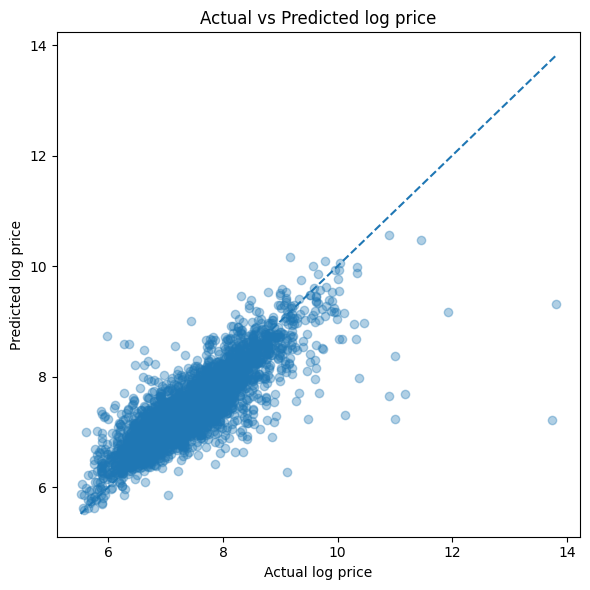

Saved: ml/outputs/price_modeling/charts/11_residual_distribution_log.png


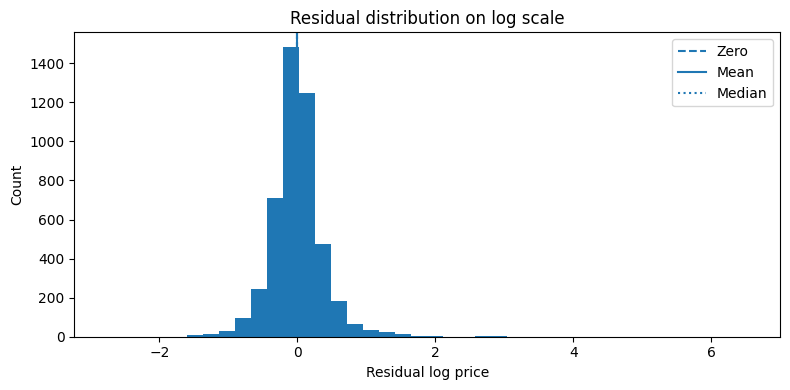

Saved: ml/outputs/price_modeling/charts/12_residual_vs_predicted_log.png


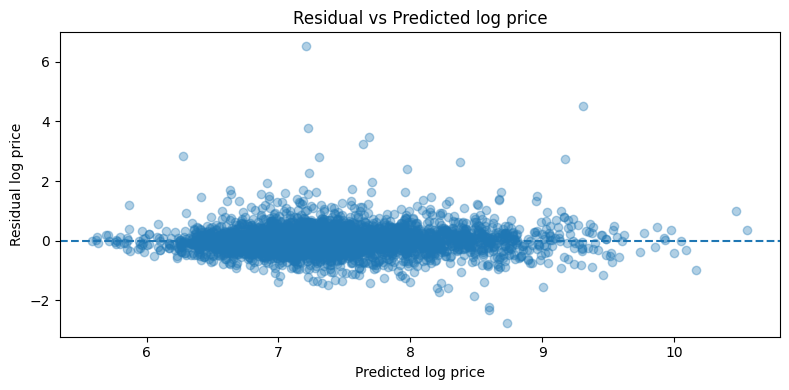

In [51]:
def save_error_figure(filename):
    output_path = OUTPUT_DIRS["charts"] / filename
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {format_output_path(output_path)}")
    plt.show()
    plt.close()


plt.figure(figsize=(6, 6))
plt.scatter(
    error_analysis_predictions["actual_log_price"],
    error_analysis_predictions["predicted_log_price"],
    alpha=0.35,
)
axis_min = min(
    error_analysis_predictions["actual_log_price"].min(),
    error_analysis_predictions["predicted_log_price"].min(),
)
axis_max = max(
    error_analysis_predictions["actual_log_price"].max(),
    error_analysis_predictions["predicted_log_price"].max(),
)
plt.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--")
plt.title("Actual vs Predicted log price")
plt.xlabel("Actual log price")
plt.ylabel("Predicted log price")
save_error_figure("10_actual_vs_predicted_log.png")

plt.figure(figsize=(8, 4))
plt.hist(error_analysis_predictions["residual_log"], bins=40)
plt.axvline(0, linestyle="--", label="Zero")
plt.axvline(error_analysis_predictions["residual_log"].mean(), linestyle="-", label="Mean")
plt.axvline(error_analysis_predictions["residual_log"].median(), linestyle=":", label="Median")
plt.title("Residual distribution on log scale")
plt.xlabel("Residual log price")
plt.ylabel("Count")
plt.legend()
save_error_figure("11_residual_distribution_log.png")

plt.figure(figsize=(8, 4))
plt.scatter(
    error_analysis_predictions["predicted_log_price"],
    error_analysis_predictions["residual_log"],
    alpha=0.35,
)
plt.axhline(0, linestyle="--")
plt.title("Residual vs Predicted log price")
plt.xlabel("Predicted log price")
plt.ylabel("Residual log price")
save_error_figure("12_residual_vs_predicted_log.png")


## 3. Phân tích sai số theo phân khúc giá

In [52]:
price_bins = [-np.inf, 1000, 2000, 5000, 10000, np.inf]
price_labels = [
    "< 1,000 THB",
    "1,000-2,000 THB",
    "2,000-5,000 THB",
    "5,000-10,000 THB",
    "> 10,000 THB",
]

error_analysis_predictions["price_segment"] = pd.cut(
    error_analysis_predictions["actual_price"],
    bins=price_bins,
    labels=price_labels,
    ordered=True,
)


def summarize_error_group(dataframe, group_column):
    grouped = dataframe.groupby(group_column, observed=False)
    summary = grouped.apply(
        lambda group: pd.Series({
            "sample_count": len(group),
            "sample_pct": len(group) / len(dataframe) * 100,
            "actual_price_median": group["actual_price"].median(),
            "predicted_price_median": group["predicted_price"].median(),
            "mae_log": group["absolute_error_log"].mean(),
            "rmse_log": calculate_rmse(group["actual_log_price"], group["predicted_log_price"]),
            "mae_price": group["absolute_error_price"].mean(),
            "rmse_price": calculate_rmse(group["actual_price"], group["predicted_price"]),
            "median_absolute_percentage_error": group["absolute_percentage_error"].median(),
            "mean_residual_price": group["residual_price"].mean(),
            "median_residual_price": group["residual_price"].median(),
            "under_prediction_pct": (group["prediction_direction"] == "Under-prediction").mean() * 100,
            "over_prediction_pct": (group["prediction_direction"] == "Over-prediction").mean() * 100,
        })
    ).reset_index()
    summary["is_reliable_group"] = summary["sample_count"] >= 30
    return summary


error_by_price_segment = summarize_error_group(
    error_analysis_predictions,
    "price_segment",
)
save_dataframe(error_by_price_segment, "19_error_by_price_segment.csv")
error_by_price_segment


Saved: ml/outputs/price_modeling/csv/19_error_by_price_segment.csv


,price_segment,sample_count,sample_pct,actual_price_median,predicted_price_median,mae_log,rmse_log,mae_price,rmse_price,median_absolute_percentage_error,mean_residual_price,median_residual_price,under_prediction_pct,over_prediction_pct,is_reliable_group
0,"< 1,000 THB",1358.0,29.172932,764.0,891.697571,0.274570,0.390564,254.239499,469.239590,20.774019,-219.268345,-132.242584,20.544919,79.455081,True
1,"1,000-2,000 THB",1914.0,41.117078,1389.0,1393.335693,0.182417,0.250915,273.812031,428.133865,13.267126,-43.344531,11.259338,51.985371,48.014629,True
2,"2,000-5,000 THB",1039.0,22.320086,2784.0,2414.304932,0.311136,0.412977,844.592497,1191.596886,22.990535,262.421739,331.221924,68.046198,31.953802,True
3,"5,000-10,000 THB",254.0,5.456498,6340.5,4983.825195,0.409879,0.562696,2167.079453,2837.939515,27.412922,1277.367154,1373.153198,77.952756,22.047244,True
4,"> 10,000 THB",90.0,1.933405,15233.0,8611.826172,0.945819,1.432720,33073.882109,144638.478693,45.520978,32515.548493,6799.796631,90.000000,10.000000,True


Saved: ml/outputs/price_modeling/charts/13_error_by_price_segment.png


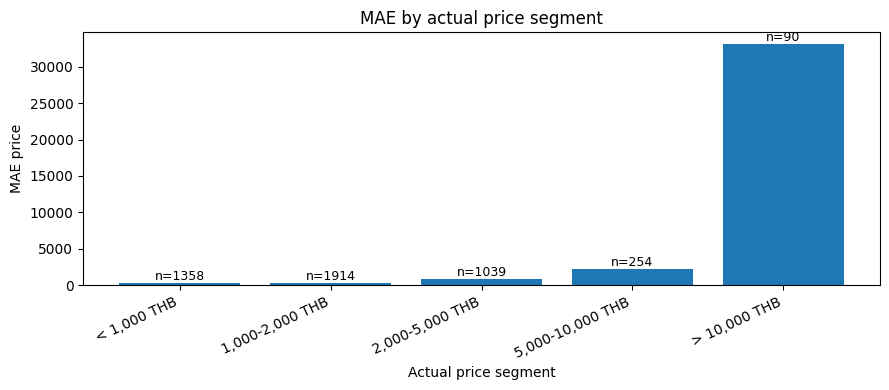

In [53]:
price_segment_plot = error_by_price_segment.copy()
plt.figure(figsize=(9, 4))
plt.bar(price_segment_plot["price_segment"].astype(str), price_segment_plot["mae_price"])
for index, row in price_segment_plot.iterrows():
    plt.text(index, row["mae_price"], f"n={int(row['sample_count'])}", ha="center", va="bottom", fontsize=9)
plt.title("MAE by actual price segment")
plt.xlabel("Actual price segment")
plt.ylabel("MAE price")
plt.xticks(rotation=25, ha="right")
save_error_figure("13_error_by_price_segment.png")


## 4. Phân tích sai số theo nhóm nghiệp vụ

In [54]:
def summarize_business_group(dataframe, group_column):
    summary = summarize_error_group(dataframe.dropna(subset=[group_column]), group_column)
    summary = summary.rename(columns={group_column: "group"})
    summary.insert(0, "business_variable", group_column)
    return summary.sort_values(["is_reliable_group", "rmse_log"], ascending=[False, False])


business_group_outputs = {}
for business_column, filename in [
    ("neighbourhood", "20_error_by_neighbourhood.csv"),
    ("room_type", "21_error_by_room_type.csv"),
    ("property_group", "22_error_by_property_group.csv"),
]:
    if business_column in error_analysis_predictions.columns:
        business_group_outputs[business_column] = summarize_business_group(
            error_analysis_predictions,
            business_column,
        )
        save_dataframe(business_group_outputs[business_column], filename)
    else:
        print(f"Skipped {filename}: missing column {business_column}")

business_group_outputs.keys()


Saved: ml/outputs/price_modeling/csv/20_error_by_neighbourhood.csv
Saved: ml/outputs/price_modeling/csv/21_error_by_room_type.csv
Saved: ml/outputs/price_modeling/csv/22_error_by_property_group.csv


dict_keys(['neighbourhood', 'room_type', 'property_group'])

Saved: ml/outputs/price_modeling/charts/14_high_error_neighbourhoods.png


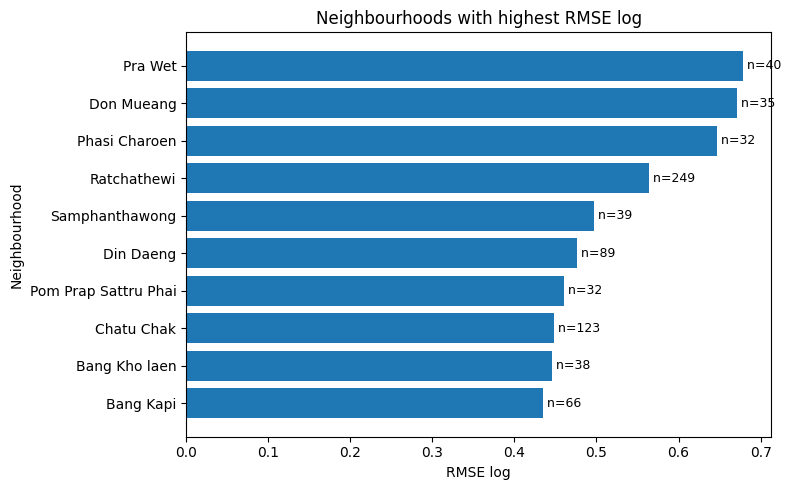

Saved: ml/outputs/price_modeling/charts/15_error_by_business_group.png


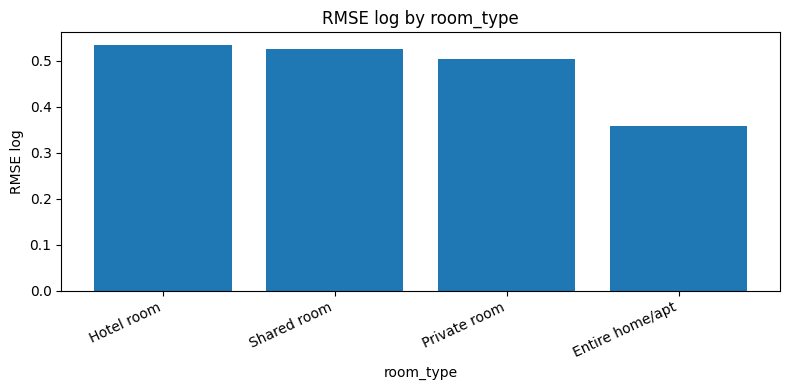

In [55]:
if "neighbourhood" in business_group_outputs:
    high_error_neighbourhoods = (
        business_group_outputs["neighbourhood"]
        .query("is_reliable_group")
        .sort_values("rmse_log", ascending=False)
        .head(10)
    )
    if not high_error_neighbourhoods.empty:
        plt.figure(figsize=(8, 5))
        plt.barh(high_error_neighbourhoods["group"].astype(str), high_error_neighbourhoods["rmse_log"])
        plt.gca().invert_yaxis()
        for index, row in enumerate(high_error_neighbourhoods.itertuples(index=False)):
            plt.text(row.rmse_log, index, f" n={int(row.sample_count)}", va="center", fontsize=9)
        plt.title("Neighbourhoods with highest RMSE log")
        plt.xlabel("RMSE log")
        plt.ylabel("Neighbourhood")
        save_error_figure("14_high_error_neighbourhoods.png")

business_plot_column = None
if "room_type" in business_group_outputs:
    reliable_room_types = business_group_outputs["room_type"].query("is_reliable_group")
    if len(reliable_room_types) >= 2:
        business_plot_column = "room_type"
if business_plot_column is None and "property_group" in business_group_outputs:
    reliable_property_groups = business_group_outputs["property_group"].query("is_reliable_group")
    if len(reliable_property_groups) >= 2:
        business_plot_column = "property_group"

if business_plot_column is not None:
    business_plot_data = (
        business_group_outputs[business_plot_column]
        .query("is_reliable_group")
        .sort_values("rmse_log", ascending=False)
    )
    plt.figure(figsize=(8, 4))
    plt.bar(business_plot_data["group"].astype(str), business_plot_data["rmse_log"])
    plt.title(f"RMSE log by {business_plot_column}")
    plt.xlabel(business_plot_column)
    plt.ylabel("RMSE log")
    plt.xticks(rotation=25, ha="right")
    save_error_figure("15_error_by_business_group.png")
else:
    print("Skipped business group chart: no reliable room_type or property_group groups.")


## 5. Phân tích các trường hợp sai số lớn

In [56]:
error_case_columns = [
    "listing_id",
    "neighbourhood",
    "room_type",
    "property_group",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "number_of_reviews",
    "actual_price",
    "predicted_price",
    "residual_price",
    "absolute_error_price",
    "residual_log",
    "absolute_error_log",
    "absolute_percentage_error",
    "prediction_direction",
]
error_case_columns = [column for column in error_case_columns if column in error_analysis_predictions.columns]

top_absolute_errors = (
    error_analysis_predictions
    .sort_values("absolute_error_log", ascending=False)
    .head(20)[error_case_columns]
)
top_under_predictions = (
    error_analysis_predictions
    .sort_values("residual_log", ascending=False)
    .head(10)[error_case_columns]
)
top_over_predictions = (
    error_analysis_predictions
    .sort_values("residual_log", ascending=True)
    .head(10)[error_case_columns]
)

save_dataframe(top_absolute_errors, "23_top_absolute_errors.csv")
save_dataframe(top_under_predictions, "24_top_under_predictions.csv")
save_dataframe(top_over_predictions, "25_top_over_predictions.csv")

top_absolute_errors


Saved: ml/outputs/price_modeling/csv/23_top_absolute_errors.csv
Saved: ml/outputs/price_modeling/csv/24_top_under_predictions.csv
Saved: ml/outputs/price_modeling/csv/25_top_over_predictions.csv


,listing_id,neighbourhood,room_type,property_group,accommodates,bedrooms,bathrooms,beds,number_of_reviews,actual_price,predicted_price,residual_price,absolute_error_price,residual_log,absolute_error_log,absolute_percentage_error,prediction_direction
3923,21462529,Ratchathewi,Private room,Apartment / Condo,3,1.0,1.0,1.0,1,928572.0,1353.155396,927218.844604,927218.844604,6.530471,6.530471,99.854276,Under-prediction
1710,8880974,Huai Khwang,Entire home/apt,Apartment / Condo,4,1.0,1.0,3.0,45,1000000.0,11059.202148,988940.797852,988940.797852,4.504403,4.504403,98.894080,Under-prediction
2979,39929656,Huai Khwang,Private room,Apartment / Condo,2,2.0,1.0,2.0,0,60000.0,1372.348267,58627.651733,58627.651733,3.777109,3.777109,97.712753,Under-prediction
1206,20493267,Ratchathewi,Private room,Apartment / Condo,1,2.0,2.0,2.0,12,70886.0,2173.246094,68712.753906,68712.753906,3.484405,3.484405,96.934167,Under-prediction
1661,18063987,Vadhana,Entire home/apt,Apartment / Condo,2,1.0,1.5,2.0,31,53633.0,2082.805420,51550.194580,51550.194580,3.247987,3.247987,96.116560,Under-prediction
1229,35589034,Lat Phrao,Private room,Apartment / Condo,2,1.0,1.0,1.0,0,9130.0,529.616089,8600.383911,8600.383911,2.845392,2.845392,94.199167,Under-prediction
1567,1042390573301230049,Phasi Charoen,Entire home/apt,Apartment / Condo,2,1.0,1.0,2.0,0,25000.0,1494.363892,23505.636108,23505.636108,2.816546,2.816546,94.022544,Under-prediction
3197,28101168,Chatu Chak,Hotel room,Guesthouse / B&B,16,16.0,2.0,26.0,0,390.0,6221.966309,-5831.966309,5831.966309,-2.767294,2.767294,1495.375977,Over-prediction
1121,1386767523243801168,Don Mueang,Entire home/apt,House / Home,4,5.0,6.0,2.0,0,150000.0,9672.191406,140327.808594,140327.808594,2.741284,2.741284,93.551872,Under-prediction
2268,1060783934533350500,Pra Wet,Entire home/apt,House / Home,6,2.0,2.0,1.0,0,60000.0,4349.350586,55650.649414,55650.649414,2.624105,2.624105,92.751082,Under-prediction


In [57]:
top_20_error_rows = error_analysis_predictions.loc[top_absolute_errors.index]


def safe_median(dataframe, column):
    return dataframe[column].median() if column in dataframe.columns else np.nan


def safe_rate(dataframe, condition):
    return condition.mean() * 100 if len(dataframe) else np.nan

property_counts = error_analysis_predictions["property_group"].value_counts() if "property_group" in error_analysis_predictions.columns else pd.Series(dtype=int)
rare_property_groups = set(property_counts[property_counts < 30].index)

top_error_profile_rows = [
    {
        "metric": "median_actual_price",
        "all_test": safe_median(error_analysis_predictions, "actual_price"),
        "top_20_errors": safe_median(top_20_error_rows, "actual_price"),
    },
    {
        "metric": "median_accommodates",
        "all_test": safe_median(error_analysis_predictions, "accommodates"),
        "top_20_errors": safe_median(top_20_error_rows, "accommodates"),
    },
    {
        "metric": "median_bedrooms",
        "all_test": safe_median(error_analysis_predictions, "bedrooms"),
        "top_20_errors": safe_median(top_20_error_rows, "bedrooms"),
    },
    {
        "metric": "median_bathrooms",
        "all_test": safe_median(error_analysis_predictions, "bathrooms"),
        "top_20_errors": safe_median(top_20_error_rows, "bathrooms"),
    },
    {
        "metric": "price_above_5000_pct",
        "all_test": safe_rate(error_analysis_predictions, error_analysis_predictions["actual_price"] > 5000),
        "top_20_errors": safe_rate(top_20_error_rows, top_20_error_rows["actual_price"] > 5000),
    },
]

if "property_group" in error_analysis_predictions.columns:
    top_error_profile_rows.append({
        "metric": "rare_property_group_pct",
        "all_test": safe_rate(error_analysis_predictions, error_analysis_predictions["property_group"].isin(rare_property_groups)),
        "top_20_errors": safe_rate(top_20_error_rows, top_20_error_rows["property_group"].isin(rare_property_groups)),
    })

if "has_reviews" in error_analysis_predictions.columns:
    top_error_profile_rows.append({
        "metric": "no_review_pct",
        "all_test": safe_rate(error_analysis_predictions, error_analysis_predictions["has_reviews"] == 0),
        "top_20_errors": safe_rate(top_20_error_rows, top_20_error_rows["has_reviews"] == 0),
    })

top_error_profile = pd.DataFrame(top_error_profile_rows)
top_error_profile


,metric,all_test,top_20_errors
0,median_actual_price,1395.000000,14598.0
1,median_accommodates,2.000000,4.0
2,median_bedrooms,1.000000,1.0
3,median_bathrooms,1.000000,1.0
4,price_above_5000_pct,7.389903,70.0
5,rare_property_group_pct,1.095596,0.0
6,no_review_pct,29.817401,55.0


## 6. Kiểm định thống kê cần thiết

In [60]:
def interpret_correlation_strength(rho):
    absolute_rho = abs(rho)
    if absolute_rho < 0.10:
        return "Rất yếu"
    if absolute_rho < 0.30:
        return "Yếu"
    if absolute_rho < 0.50:
        return "Trung bình"
    return "Mạnh"


statistical_test_rows = []
for variable_x, variable_y in [
    ("absolute_error_log", "actual_log_price"),
    ("absolute_error_price", "actual_price"),
]:
    test_data = error_analysis_predictions[[variable_x, variable_y]].dropna()
    rho, p_value = spearmanr(test_data[variable_x], test_data[variable_y])
    statistical_test_rows.append({
        "test": "Spearman correlation",
        "variable_x": variable_x,
        "variable_y": variable_y,
        "spearman_rho": rho,
        "p_value": p_value,
        "n": len(test_data),
        "interpretation": interpret_correlation_strength(rho),
    })

kruskal_source = error_analysis_predictions.dropna(subset=["price_segment", "absolute_error_log"])
valid_segment_counts = kruskal_source["price_segment"].value_counts()
valid_segments = valid_segment_counts[valid_segment_counts >= 30].index.tolist()
kruskal_groups = [
    kruskal_source.loc[kruskal_source["price_segment"] == segment, "absolute_error_log"]
    for segment in valid_segments
]

if len(kruskal_groups) >= 2:
    kruskal_statistic, kruskal_p_value = kruskal(*kruskal_groups)
    number_of_groups = len(kruskal_groups)
    number_of_observations = sum(len(group) for group in kruskal_groups)
    epsilon_squared = max(
        0,
        (kruskal_statistic - number_of_groups + 1)
        / (number_of_observations - number_of_groups),
    )
    statistical_test_rows.append({
        "test": "Kruskal-Wallis",
        "variable_x": "price_segment",
        "variable_y": "absolute_error_log",
        "statistic": kruskal_statistic,
        "p_value": kruskal_p_value,
        "alpha": 0.05,
        "reject_h0": kruskal_p_value < 0.05,
        "n_groups": number_of_groups,
        "group_names": ", ".join(map(str, valid_segments)),
        "epsilon_squared": epsilon_squared,
    })
else:
    print("Skipped Kruskal-Wallis: fewer than two price segments have at least 30 samples.")

error_statistical_tests = pd.DataFrame(statistical_test_rows)
save_dataframe(error_statistical_tests, "26_error_statistical_tests.csv")
error_statistical_tests


Saved: ml/outputs/price_modeling/csv/26_error_statistical_tests.csv


,test,variable_x,variable_y,spearman_rho,p_value,n,interpretation,statistic,alpha,reject_h0,n_groups,group_names,epsilon_squared
0,Spearman correlation,absolute_error_log,actual_log_price,0.092908,2.140352e-10,4655.0,Rất yếu,NaN,NaN,NaN,NaN,NaN,NaN
1,Spearman correlation,absolute_error_price,actual_price,0.489469,4.461327e-279,4655.0,Trung bình,NaN,NaN,NaN,NaN,NaN,NaN
2,Kruskal-Wallis,price_segment,absolute_error_log,NaN,5.450686e-76,NaN,NaN,356.9817,0.05,True,5.0,"1,000-2,000 THB, < 1,000 THB, 2,000-5,000 THB,...",0.07591


**Nhận xét:**

- Trên tập test gồm `4,655` listing, residual log trung bình gần như bằng 0 (`0.000043`) và median residual log là `-0.009149`. Điều này cho thấy mô hình không có bias tổng thể quá lớn trên log scale. Tuy nhiên, tỷ lệ over-prediction (`51.45%`) cao hơn nhẹ so với under-prediction (`48.55%`), nên mô hình hơi có xu hướng dự báo cao hơn thực tế ở mức rất nhẹ.

- MAE log của mô hình là `0.265202`, RMSE log là `0.406715`; trên thang giá, MAE là `1,132.97 THB` trong khi RMSE lên tới `20,133.80 THB`. Khoảng cách rất lớn giữa MAE và RMSE cho thấy sai số bị chi phối mạnh bởi một số listing có giá rất cao hoặc outlier. Median absolute error price chỉ khoảng `247.41 THB` và median absolute percentage error là `18.20%`, nên với phần lớn listing thông thường, sai số ở mức chấp nhận được hơn so với nhìn vào RMSE price.

- Sai số tăng rõ theo phân khúc giá. Nhóm `1,000-2,000 THB` có RMSE log thấp nhất (`0.250915`), trong khi nhóm `> 10,000 THB` có RMSE log cao nhất (`1.432720`) và MAE price rất lớn (`33,073.88 THB`). Đây là nhóm đủ mẫu (`90` listing) nhưng chỉ chiếm `1.93%` test set, nên mô hình có thể chưa học đủ tín hiệu cho phân khúc luxury. Tỷ lệ under-prediction ở nhóm này lên tới `90%`, cho thấy mô hình thường đánh giá thấp các listing giá cao.

- Kiểm định Spearman cho thấy tương quan giữa `absolute_error_log` và `actual_log_price` là `0.092908`, mức rất yếu dù p-value rất nhỏ. Ngược lại, tương quan giữa `absolute_error_price` và `actual_price` là `0.489469`, mức trung bình. Diễn giải thận trọng là: trên log scale, sai số không tăng quá mạnh theo giá; nhưng khi quay về THB, listing giá cao làm sai số tuyệt đối tăng rõ rệt.

- Kruskal-Wallis cho `absolute_error_log` theo `price_segment` có p-value `5.45e-76`, reject H0, và epsilon-squared khoảng `0.07591`. Kết quả này cho thấy phân phối sai số log khác nhau giữa các phân khúc giá, nhưng effect size không quá lớn. Vì vậy, price segment là một tín hiệu cần quan tâm trong phân tích lỗi, nhưng không nên xem đây là nguyên nhân duy nhất.

- Theo nhóm nghiệp vụ, các neighbourhood có sai số cao trong nhóm đủ mẫu gồm `Pra Wet` (RMSE log `0.678942`, n=`40`), `Don Mueang` (`0.670805`, n=`35`) và `Phasi Charoen` (`0.647510`, n=`32`). Theo `room_type`, `Hotel room`, `Shared room` và `Private room` có RMSE log cao hơn `Entire home/apt`. Theo `property_group`, `Guesthouse / B&B` có RMSE log cao nhất (`0.570643`), tiếp theo là `House / Home` (`0.477885`) và `Hostel` (`0.460212`). Các nhóm này có thể có độ đa dạng cao hơn hoặc thiếu feature mô tả chất lượng listing.

- Top 20 listing có sai số lớn cho thấy lỗi tập trung mạnh ở các listing giá cao: median actual price của toàn bộ test set là `1,395 THB`, trong khi top 20 errors có median actual price `14,598 THB`. Tỷ lệ listing trên `5,000 THB` trong toàn test set chỉ `7.39%`, nhưng trong top 20 errors là `70%`. Ngoài ra, tỷ lệ listing không có review trong top errors là `55%`, cao hơn toàn test set (`29.82%`). Điều này gợi ý sai số lớn thường xuất hiện ở listing đắt tiền, ít review hoặc có đặc điểm bất thường mà feature hiện tại chưa phản ánh đủ.

- Hướng cải thiện nên ưu tiên bổ sung feature thay vì chỉ tuning thêm: chi tiết amenities, đặc trưng vị trí vi mô, khoảng cách đến BTS/MRT/điểm du lịch, tín hiệu về chất lượng listing, calendar/mùa vụ nếu mục tiêu là dynamic pricing, và cân nhắc xử lý riêng phân khúc luxury/outlier khi có đủ dữ liệu.


# Model Explainability

## 1. Chuẩn bị mô hình và dữ liệu giải thích

In [62]:
explain_model_path = OUTPUT_DIRS["models"] / "final_price_model.joblib"

if "final_model_artifact" in globals():
    explain_artifact = final_model_artifact
else:
    assert explain_model_path.exists(), f"Missing final model artifact: {explain_model_path}"
    explain_artifact = joblib.load(explain_model_path)

final_pipeline_for_explain = None
final_preprocessor = None
final_model = None
final_selected_features = None
final_model_name = None

if isinstance(explain_artifact, dict):
    final_model_name = explain_artifact.get("model_name")
    final_selected_features = explain_artifact.get("model_features") or explain_artifact.get("selected_features")
    final_pipeline_for_explain = explain_artifact.get("pipeline")
    final_preprocessor = explain_artifact.get("preprocessor")
    final_model = explain_artifact.get("model")

    if final_pipeline_for_explain is not None and hasattr(final_pipeline_for_explain, "named_steps"):
        named_steps = final_pipeline_for_explain.named_steps
        if final_preprocessor is None:
            final_preprocessor = named_steps.get("preprocessor")
        if final_model is None:
            final_model = named_steps.get("model")
else:
    final_pipeline_for_explain = explain_artifact
    final_model_name = type(explain_artifact).__name__

if final_pipeline_for_explain is not None and hasattr(final_pipeline_for_explain, "named_steps"):
    named_steps = final_pipeline_for_explain.named_steps
    if final_preprocessor is None:
        transformer_steps = [
            step for step in named_steps.values()
            if hasattr(step, "transform") and not hasattr(step, "predict")
        ]
        final_preprocessor = transformer_steps[0] if transformer_steps else None
    if final_model is None:
        predictor_steps = [step for step in named_steps.values() if hasattr(step, "predict")]
        final_model = predictor_steps[-1] if predictor_steps else None

if final_pipeline_for_explain is None and final_preprocessor is not None and final_model is not None:
    final_pipeline_for_explain = Pipeline([
        ("preprocessor", final_preprocessor),
        ("model", final_model),
    ])

if final_model_name is None and final_model is not None:
    final_model_name = type(final_model).__name__
if final_selected_features is None and "final_feature_list" in globals():
    final_selected_features = list(final_feature_list)
if final_selected_features is None and "selected_feature_list" in globals():
    final_selected_features = list(selected_feature_list)
if final_selected_features is None:
    final_selected_features = list(X_test.columns)

final_selected_features = [feature for feature in final_selected_features if feature in X_test.columns]

assert final_model is not None, "final_model could not be resolved."
assert final_preprocessor is not None, "final_preprocessor could not be resolved."
assert hasattr(final_model, "predict"), "final_model must implement predict()."
assert final_pipeline_for_explain is not None, "A prediction pipeline is required for explainability."
assert len(final_selected_features) > 0, "Final feature list must not be empty."

print("Final model for explainability:", final_model_name)
print("Raw features used:", len(final_selected_features))
print("Artifact type:", type(explain_artifact).__name__)


Final model for explainability: XGBRegressor
Raw features used: 22
Artifact type: dict


In [66]:
if "error_analysis_predictions" in globals():
    explain_error_predictions = error_analysis_predictions.copy()
else:
    error_analysis_path = OUTPUT_DIRS["csv"] / "17_error_analysis_predictions.csv"
    assert error_analysis_path.exists(), f"Missing error analysis file: {error_analysis_path}"
    explain_error_predictions = pd.read_csv(error_analysis_path)

assert len(explain_error_predictions) == len(X_test), "Error analysis row count must match X_test."

X_explain_raw = X_test[final_selected_features].copy()
y_explain = y_test.copy()
assert len(X_explain_raw) == len(y_explain), "X/y explain row count mismatch."

permutation_n = min(PERMUTATION_SAMPLE_SIZE, len(X_explain_raw))
shap_n = min(SHAP_SAMPLE_SIZE, len(X_explain_raw))
background_n = min(SHAP_BACKGROUND_SIZE, shap_n)

permutation_index = X_explain_raw.sample(
    n=permutation_n,
    random_state=EXPLAIN_RANDOM_STATE,
).index
shap_index = X_explain_raw.sample(
    n=shap_n,
    random_state=EXPLAIN_RANDOM_STATE,
).index
background_index = X_explain_raw.loc[shap_index].sample(
    n=background_n,
    random_state=EXPLAIN_RANDOM_STATE,
).index

permutation_sample = X_explain_raw.loc[permutation_index]
permutation_y = y_explain.loc[permutation_index]
shap_sample = X_explain_raw.loc[shap_index]
shap_background = X_explain_raw.loc[background_index]

assert len(permutation_sample) == len(permutation_y)
assert list(shap_sample.index).count(shap_sample.index[0]) >= 1
print("Permutation sample rows:", len(permutation_sample))
print("SHAP sample rows:", len(shap_sample))
print("SHAP background rows:", len(shap_background))


Permutation sample rows: 2000
SHAP sample rows: 1000
SHAP background rows: 200


## 2. Permutation Importance

In [67]:
permutation_result = permutation_importance(
    estimator=final_pipeline_for_explain,
    X=permutation_sample,
    y=permutation_y,
    scoring="neg_root_mean_squared_error",
    n_repeats=PERMUTATION_REPEATS,
    random_state=EXPLAIN_RANDOM_STATE,
    n_jobs=EXPLAIN_N_JOBS,
)

permutation_importance_raw = pd.DataFrame({
    "feature": permutation_sample.columns,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)
permutation_importance_raw["importance_rank"] = np.arange(1, len(permutation_importance_raw) + 1)

save_dataframe(permutation_importance_raw, "27_permutation_importance_raw_features.csv")
permutation_importance_raw.head(TOP_N_IMPORTANCE)


Saved: ml/outputs/price_modeling/csv/27_permutation_importance_raw_features.csv


,feature,importance_mean,importance_std,importance_rank
0,accommodates,0.127061,0.005792,1
1,neighbourhood,0.107022,0.004876,2
2,bedrooms,0.097136,0.003490,3
3,host_total_listings_count,0.074110,0.009633,4
4,host_listings_count,0.044587,0.002419,5
5,room_type,0.040154,0.002568,6
6,minimum_nights,0.035130,0.001928,7
7,host_acceptance_rate,0.034317,0.001322,8
8,bathrooms,0.029750,0.001604,9
9,amenities_count,0.029719,0.003734,10


Saved: ml/outputs/price_modeling/charts/16_permutation_importance_raw_features.png


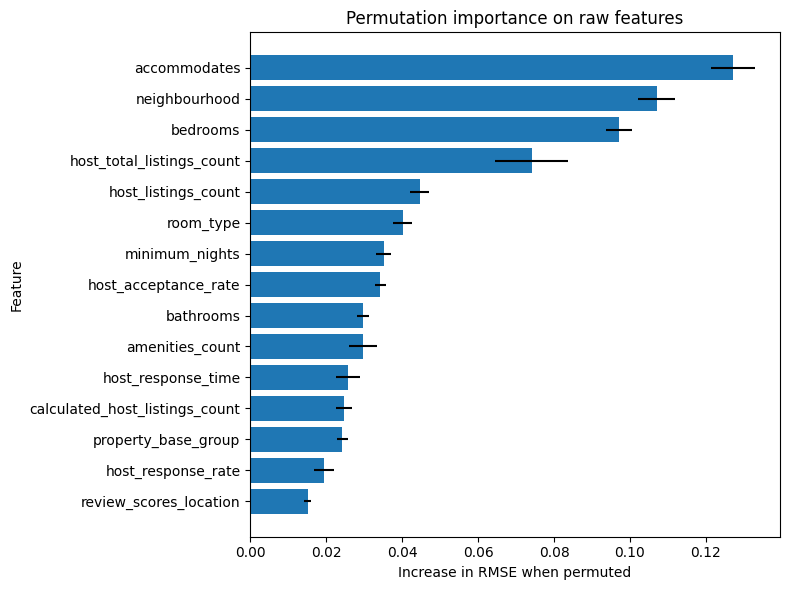

In [68]:
top_permutation_plot = permutation_importance_raw.head(TOP_N_IMPORTANCE).sort_values("importance_mean")
plt.figure(figsize=(8, 6))
plt.barh(
    top_permutation_plot["feature"],
    top_permutation_plot["importance_mean"],
    xerr=top_permutation_plot["importance_std"],
)
plt.title("Permutation importance on raw features")
plt.xlabel("Increase in RMSE when permuted")
plt.ylabel("Feature")
explain_plot_path = OUTPUT_DIRS["charts"] / "16_permutation_importance_raw_features.png"
plt.tight_layout()
plt.savefig(explain_plot_path, dpi=150, bbox_inches="tight")
print(f"Saved: {format_output_path(explain_plot_path)}")
plt.show()
plt.close()


## 3. SHAP Global Explanation

In [74]:
def to_dense_if_sparse(matrix, label):
    if sparse.issparse(matrix):
        dense_size_mb = matrix.shape[0] * matrix.shape[1] * 8 / (1024 ** 2)
        assert dense_size_mb < 512, f"{label} is too large to safely densify: {dense_size_mb:.1f} MB"
        return matrix.toarray()
    return np.asarray(matrix)


X_shap_transformed = final_preprocessor.transform(shap_sample)
X_background_transformed = final_preprocessor.transform(shap_background)
transformed_feature_names = final_preprocessor.get_feature_names_out()

assert X_shap_transformed.shape[1] == len(transformed_feature_names), "Transformed feature count mismatch."
assert X_background_transformed.shape[1] == len(transformed_feature_names), "Background feature count mismatch."

X_shap_dense = to_dense_if_sparse(X_shap_transformed, "X_shap_transformed")
X_background_dense = to_dense_if_sparse(X_background_transformed, "X_background_transformed")

clean_transformed_feature_names = []
for feature_name in transformed_feature_names:
    feature_name = str(feature_name)
    clean_transformed_feature_names.append(feature_name.split("__", 1)[1] if "__" in feature_name else feature_name)

TREE_EXPLAINER_MODEL_NAMES = {
    "XGBRegressor",
    "HistGradientBoostingRegressor",
    "RandomForestRegressor",
    "CatBoostRegressor",
}

if final_model_name in TREE_EXPLAINER_MODEL_NAMES:
    try:
        shap_explainer = shap.TreeExplainer(final_model)
    except (TypeError, ValueError) as error:
        raise RuntimeError(
            "Không thể khởi tạo TreeExplainer phù hợp cho final model hiện tại."
        ) from error

    shap_values = shap_explainer.shap_values(X_shap_dense)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 0]

    expected_value = shap_explainer.expected_value
    if isinstance(expected_value, (list, tuple, np.ndarray)):
        expected_value = np.asarray(expected_value).ravel()[0]
    base_values = np.repeat(float(expected_value), shap_values.shape[0])
else:
    raise RuntimeError(
        "Không thể khởi tạo SHAP explainer phù hợp cho final model hiện tại mà không dùng KernelExplainer."
    )

assert shap_values.shape[1] == len(transformed_feature_names), "SHAP columns must match transformed features."

model_predictions_for_shap = final_model.predict(X_shap_transformed)
reconstructed_predictions = base_values + shap_values.sum(axis=1)
shap_reconstruction_abs_errors = np.abs(model_predictions_for_shap - reconstructed_predictions)
shap_reconstruction_max_abs_error = float(np.max(shap_reconstruction_abs_errors))
shap_reconstruction_mean_abs_error = float(np.mean(shap_reconstruction_abs_errors))
assert shap_reconstruction_max_abs_error < 1e-3, f"SHAP reconstruction error too high: {shap_reconstruction_max_abs_error}"
print("SHAP reconstruction max abs error:", shap_reconstruction_max_abs_error)
print("SHAP reconstruction mean abs error:", shap_reconstruction_mean_abs_error)


AssertionError: SHAP reconstruction error too high: 2.4574190378189087

In [71]:
def map_transformed_to_raw_features(transformed_names, raw_features):
    mapping_rows = []
    raw_features_sorted = sorted(raw_features, key=len, reverse=True)
    for transformed_name in transformed_names:
        transformed_name = str(transformed_name)
        display_name = transformed_name.split("__", 1)[1] if "__" in transformed_name else transformed_name
        matched_raw = None
        for raw_feature in raw_features_sorted:
            if display_name == raw_feature or display_name.startswith(f"{raw_feature}_"):
                matched_raw = raw_feature
                break
        if matched_raw is None:
            matched_raw = display_name
        mapping_rows.append({
            "transformed_feature": transformed_name,
            "display_feature": display_name,
            "raw_feature": matched_raw,
        })
    return pd.DataFrame(mapping_rows)


feature_name_mapping = map_transformed_to_raw_features(transformed_feature_names, final_selected_features)

shap_importance_transformed = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "display_feature": clean_transformed_feature_names,
    "mean_abs_shap": np.mean(np.abs(shap_values), axis=0),
    "mean_signed_shap": np.mean(shap_values, axis=0),
}).merge(
    feature_name_mapping[["transformed_feature", "raw_feature"]],
    on="transformed_feature",
    how="left",
    validate="one_to_one",
)
shap_importance_transformed = shap_importance_transformed.sort_values(
    "mean_abs_shap",
    ascending=False,
).reset_index(drop=True)
shap_importance_transformed["importance_rank"] = np.arange(1, len(shap_importance_transformed) + 1)

shap_importance_grouped = (
    shap_importance_transformed
    .groupby("raw_feature", as_index=False)
    .agg(
        mean_abs_shap_sum=("mean_abs_shap", "sum"),
        mean_abs_shap_mean=("mean_abs_shap", "mean"),
        n_transformed_features=("transformed_feature", "count"),
    )
    .sort_values("mean_abs_shap_sum", ascending=False)
    .reset_index(drop=True)
)
shap_importance_grouped["importance_rank"] = np.arange(1, len(shap_importance_grouped) + 1)

save_dataframe(shap_importance_transformed, "28_shap_importance_transformed.csv")
save_dataframe(shap_importance_grouped, "29_shap_importance_grouped_features.csv")
shap_importance_grouped.head(TOP_N_IMPORTANCE)


Saved: ml/outputs/price_modeling/csv/28_shap_importance_transformed.csv
Saved: ml/outputs/price_modeling/csv/29_shap_importance_grouped_features.csv


,raw_feature,mean_abs_shap_sum,mean_abs_shap_mean,n_transformed_features,importance_rank
0,neighbourhood,3.597710,0.081766,44,1
1,property_base_group,0.740059,0.067278,11,2
2,host_response_time,0.722475,0.120413,6,3
3,room_type,0.527963,0.131991,4,4
4,bedrooms,0.222079,0.222079,1,5
5,amenities_count,0.091538,0.091538,1,6
6,accommodates,0.090780,0.090780,1,7
7,review_scores_location,0.087333,0.087333,1,8
8,host_total_listings_count,0.085058,0.085058,1,9
9,calculated_host_listings_count,0.081564,0.081564,1,10


Saved: ml/outputs/price_modeling/charts/17_shap_global_grouped_bar.png


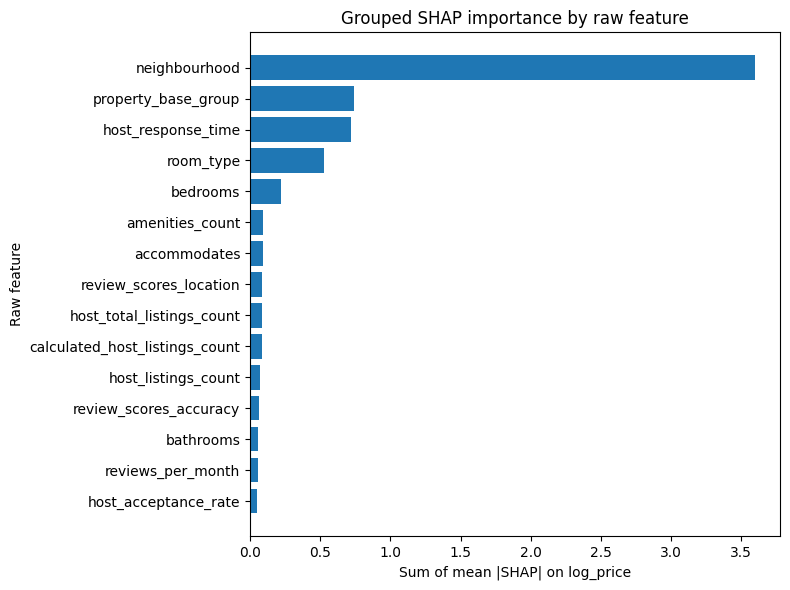

Saved: ml/outputs/price_modeling/charts/18_shap_global_beeswarm.png


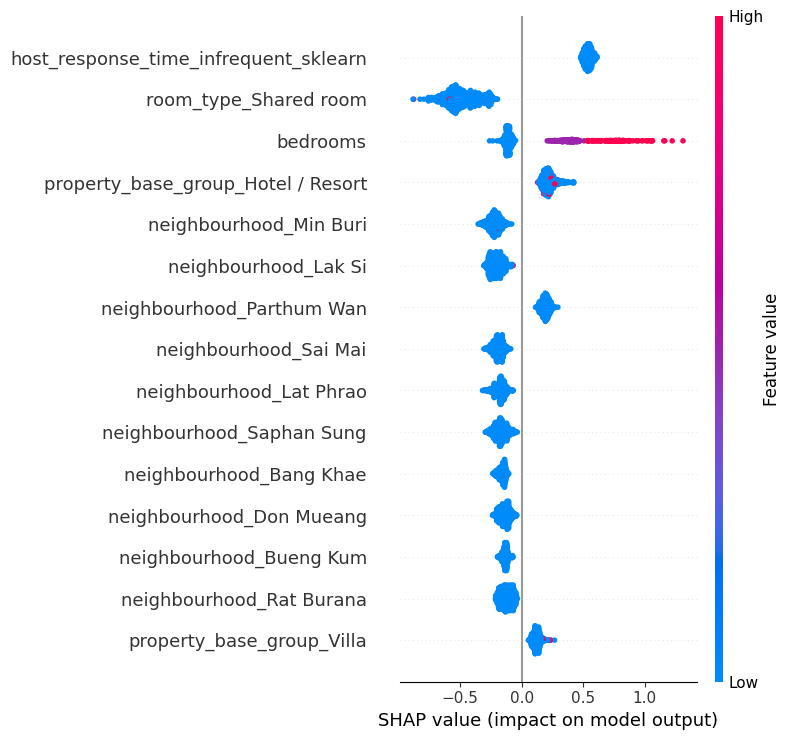

In [72]:
top_grouped_shap = shap_importance_grouped.head(TOP_N_IMPORTANCE).sort_values("mean_abs_shap_sum")
plt.figure(figsize=(8, 6))
plt.barh(top_grouped_shap["raw_feature"], top_grouped_shap["mean_abs_shap_sum"])
plt.title("Grouped SHAP importance by raw feature")
plt.xlabel("Sum of mean |SHAP| on log_price")
plt.ylabel("Raw feature")
shap_grouped_path = OUTPUT_DIRS["charts"] / "17_shap_global_grouped_bar.png"
plt.tight_layout()
plt.savefig(shap_grouped_path, dpi=150, bbox_inches="tight")
print(f"Saved: {format_output_path(shap_grouped_path)}")
plt.show()
plt.close()

top_transformed_indices = shap_importance_transformed.head(TOP_N_IMPORTANCE).index.to_numpy()
# The DataFrame was sorted, so map back to original transformed column positions.
top_transformed_feature_names = shap_importance_transformed.head(TOP_N_IMPORTANCE)["transformed_feature"].tolist()
top_transformed_positions = [list(transformed_feature_names).index(feature) for feature in top_transformed_feature_names]
shap.summary_plot(
    shap_values[:, top_transformed_positions],
    X_shap_dense[:, top_transformed_positions],
    feature_names=[clean_transformed_feature_names[position] for position in top_transformed_positions],
    show=False,
    max_display=TOP_N_IMPORTANCE,
)
beeswarm_path = OUTPUT_DIRS["charts"] / "18_shap_global_beeswarm.png"
plt.tight_layout()
plt.savefig(beeswarm_path, dpi=150, bbox_inches="tight")
print(f"Saved: {format_output_path(beeswarm_path)}")
plt.show()
plt.close()


## 4. SHAP Feature Effects

In [73]:
explainability_comparison = permutation_importance_raw[[
    "feature",
    "importance_mean",
    "importance_rank",
]].rename(columns={
    "importance_mean": "permutation_importance",
    "importance_rank": "permutation_rank",
}).merge(
    shap_importance_grouped[["raw_feature", "mean_abs_shap_sum", "importance_rank"]].rename(columns={
        "raw_feature": "feature",
        "mean_abs_shap_sum": "grouped_mean_abs_shap",
        "importance_rank": "shap_rank",
    }),
    on="feature",
    how="outer",
)

permutation_total = explainability_comparison["permutation_importance"].clip(lower=0).sum()
shap_total = explainability_comparison["grouped_mean_abs_shap"].sum()
explainability_comparison["permutation_importance_pct"] = np.where(
    permutation_total > 0,
    explainability_comparison["permutation_importance"].clip(lower=0) / permutation_total * 100,
    np.nan,
)
explainability_comparison["shap_importance_pct"] = np.where(
    shap_total > 0,
    explainability_comparison["grouped_mean_abs_shap"] / shap_total * 100,
    np.nan,
)
explainability_comparison["rank_difference"] = (
    explainability_comparison["permutation_rank"] - explainability_comparison["shap_rank"]
).abs()
explainability_comparison = explainability_comparison.sort_values(
    ["shap_rank", "permutation_rank"],
    na_position="last",
).reset_index(drop=True)

rank_overlap = explainability_comparison.dropna(subset=["permutation_rank", "shap_rank"])
if len(rank_overlap) >= 3:
    explain_rank_spearman_rho, explain_rank_spearman_p_value = spearmanr(
        rank_overlap["permutation_rank"],
        rank_overlap["shap_rank"],
    )
else:
    explain_rank_spearman_rho = np.nan
    explain_rank_spearman_p_value = np.nan

explainability_method_comparison = explainability_comparison.copy()
explainability_method_comparison["spearman_rho"] = explain_rank_spearman_rho
explainability_method_comparison["p_value"] = explain_rank_spearman_p_value
explainability_method_comparison["n_features"] = len(rank_overlap)

save_dataframe(explainability_method_comparison, "30_explainability_method_comparison.csv")
print("Spearman rank correlation:", explain_rank_spearman_rho)
explainability_method_comparison.head(TOP_N_IMPORTANCE)


Saved: ml/outputs/price_modeling/csv/30_explainability_method_comparison.csv
Spearman rank correlation: 0.6250705815923208


,feature,permutation_importance,permutation_rank,grouped_mean_abs_shap,shap_rank,permutation_importance_pct,shap_importance_pct,rank_difference,spearman_rho,p_value,n_features
0,neighbourhood,0.107022,2,3.597710,1,14.100863,53.224998,1,0.625071,0.001868,22
1,property_base_group,0.024286,13,0.740059,2,3.199792,10.948525,11,0.625071,0.001868,22
2,host_response_time,0.025793,11,0.722475,3,3.398405,10.688392,8,0.625071,0.001868,22
3,room_type,0.040154,6,0.527963,4,5.290628,7.810749,2,0.625071,0.001868,22
4,bedrooms,0.097136,3,0.222079,5,12.798426,3.285460,2,0.625071,0.001868,22
5,amenities_count,0.029719,10,0.091538,6,3.915631,1.354230,4,0.625071,0.001868,22
6,accommodates,0.127061,1,0.090780,7,16.741207,1.343007,6,0.625071,0.001868,22
7,review_scores_location,0.015116,15,0.087333,8,1.991688,1.292023,7,0.625071,0.001868,22
8,host_total_listings_count,0.074110,4,0.085058,9,9.764476,1.258364,5,0.625071,0.001868,22
9,calculated_host_listings_count,0.024681,12,0.081564,10,3.251868,1.206674,2,0.625071,0.001868,22


In [ ]:
numeric_dependence_candidates = [
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "host_response_rate",
    "host_acceptance_rate",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
]

selected_dependence_features = []
for feature in shap_importance_grouped["raw_feature"]:
    if feature in numeric_dependence_candidates and feature in final_selected_features and feature in shap_sample.columns:
        if pd.api.types.is_numeric_dtype(shap_sample[feature]):
            selected_dependence_features.append(feature)
    if len(selected_dependence_features) >= N_DEPENDENCE_FEATURES:
        break

for plot_number, feature in enumerate(selected_dependence_features, start=19):
    transformed_positions = feature_name_mapping.index[feature_name_mapping["raw_feature"] == feature].tolist()
    if not transformed_positions:
        print(f"Skipped dependence plot for {feature}: no transformed column found.")
        continue
    if len(transformed_positions) > 1:
        # Numeric features should usually map to one transformed column. Skip ambiguous mappings.
        print(f"Skipped dependence plot for {feature}: ambiguous transformed mapping.")
        continue
    position = transformed_positions[0]
    plt.figure(figsize=(7, 4))
    plt.scatter(shap_sample[feature], shap_values[:, position], alpha=0.35)
    plt.axhline(0, linestyle="--")
    plt.title(f"SHAP dependence for {feature}")
    plt.xlabel(feature)
    plt.ylabel("SHAP value on log_price")
    safe_feature_name = feature.replace("/", "_").replace(" ", "_")
    output_path = OUTPUT_DIRS["charts"] / f"{plot_number}_shap_dependence_{safe_feature_name}.png"
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {format_output_path(output_path)}")
    plt.show()
    plt.close()

print("Dependence features:", selected_dependence_features)


## 5. SHAP Local Explanation

In [ ]:
def get_local_case_rows(error_predictions):
    case_specs = [
        ("accurate_prediction", error_predictions["absolute_error_log"].idxmin()),
        ("under_prediction", error_predictions["residual_log"].idxmax()),
        ("over_prediction", error_predictions["residual_log"].idxmin()),
    ]
    rows = []
    for case_type, row_index in case_specs:
        row = error_predictions.loc[row_index].copy()
        row["case_type"] = case_type
        rows.append(row)
    return pd.DataFrame(rows)


local_case_rows = get_local_case_rows(explain_error_predictions)
local_case_rows


In [ ]:
local_summary_rows = []
local_contribution_rows = []
waterfall_filenames = {
    "accurate_prediction": "22_shap_waterfall_accurate_prediction.png",
    "under_prediction": "23_shap_waterfall_under_prediction.png",
    "over_prediction": "24_shap_waterfall_over_prediction.png",
}

for _, case_row in local_case_rows.iterrows():
    case_type = case_row["case_type"]
    raw_index = case_row["row_index"] if "row_index" in case_row.index else case_row.name
    assert raw_index in X_explain_raw.index, f"Local explanation row {raw_index} not found in X_test."

    local_raw = X_explain_raw.loc[[raw_index], final_selected_features]
    local_transformed = final_preprocessor.transform(local_raw)
    local_dense = to_dense_if_sparse(local_transformed, f"local_{case_type}")
    local_explanation = shap_explainer(local_dense)
    local_values = np.asarray(local_explanation.values)
    if local_values.ndim == 3:
        local_values = local_values[:, :, 0]
    local_values = local_values[0]
    local_base_values = np.asarray(local_explanation.base_values)
    local_base_value = float(local_base_values.ravel()[0])
    reconstructed_prediction = local_base_value + local_values.sum()
    model_prediction = float(final_model.predict(local_transformed)[0])
    assert np.isclose(reconstructed_prediction, model_prediction, atol=1e-4), "Local SHAP reconstruction mismatch."

    local_feature_values = local_dense[0]
    local_contributions = pd.DataFrame({
        "case_type": case_type,
        "listing_id": case_row.get("listing_id", np.nan),
        "feature": clean_transformed_feature_names,
        "feature_value": local_feature_values,
        "shap_value_log": local_values,
    })
    local_contributions["direction"] = np.where(
        local_contributions["shap_value_log"] >= 0,
        "Increase predicted log_price",
        "Decrease predicted log_price",
    )
    local_contributions["absolute_shap_value"] = local_contributions["shap_value_log"].abs()
    local_contributions = local_contributions.sort_values(
        "absolute_shap_value",
        ascending=False,
    ).reset_index(drop=True)
    local_contributions["importance_rank"] = np.arange(1, len(local_contributions) + 1)
    local_contribution_rows.append(local_contributions.head(15))

    top_positive_features = local_contributions.query("shap_value_log > 0").head(5)["feature"].tolist()
    top_negative_features = local_contributions.query("shap_value_log < 0").head(5)["feature"].tolist()
    local_summary_rows.append({
        "case_type": case_type,
        "listing_id": case_row.get("listing_id", np.nan),
        "actual_log_price": case_row["actual_log_price"],
        "predicted_log_price": case_row["predicted_log_price"],
        "actual_price": case_row["actual_price"],
        "predicted_price": case_row["predicted_price"],
        "residual_log": case_row["residual_log"],
        "base_value_log": local_base_value,
        "shap_sum": local_values.sum(),
        "reconstructed_prediction_log": reconstructed_prediction,
        "top_positive_features": ", ".join(top_positive_features),
        "top_negative_features": ", ".join(top_negative_features),
    })

    shap.waterfall_plot(
        shap.Explanation(
            values=local_values,
            base_values=local_base_value,
            data=local_feature_values,
            feature_names=clean_transformed_feature_names,
        ),
        max_display=15,
        show=False,
    )
    waterfall_path = OUTPUT_DIRS["charts"] / waterfall_filenames[case_type]
    plt.tight_layout()
    plt.savefig(waterfall_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {format_output_path(waterfall_path)}")
    plt.show()
    plt.close()

local_explanations_summary = pd.DataFrame(local_summary_rows)
local_feature_contributions = pd.concat(local_contribution_rows, ignore_index=True)

save_dataframe(local_explanations_summary, "31_local_explanations_summary.csv")
save_dataframe(local_feature_contributions, "32_local_feature_contributions.csv")
local_explanations_summary


## 6. Tổng hợp insight mô hình

In [ ]:
def infer_general_effect(raw_feature):
    transformed_rows = shap_importance_transformed.query("raw_feature == @raw_feature")
    if transformed_rows.empty:
        return "Mixed/non-linear"
    if len(transformed_rows) > 1:
        return "Category-dependent"
    transformed_feature = transformed_rows.iloc[0]["transformed_feature"]
    position = list(transformed_feature_names).index(transformed_feature)
    if raw_feature not in shap_sample.columns or not pd.api.types.is_numeric_dtype(shap_sample[raw_feature]):
        return "Mixed/non-linear"
    rho, _ = spearmanr(shap_sample[raw_feature], shap_values[:, position])
    if np.isnan(rho) or abs(rho) < 0.15:
        return "Mixed/non-linear"
    return "Positive tendency" if rho > 0 else "Negative tendency"


def make_dashboard_description(feature, effect):
    if effect == "Positive tendency":
        return f"Giá trị {feature} cao hơn thường liên hệ với dự báo giá cao hơn, nhưng không chứng minh quan hệ nhân quả."
    if effect == "Negative tendency":
        return f"Giá trị {feature} cao hơn thường liên hệ với dự báo giá thấp hơn trong dữ liệu mô hình học được."
    if effect == "Category-dependent":
        return f"Tác động của {feature} phụ thuộc vào từng nhóm/category cụ thể sau encoding."
    return f"Tác động của {feature} có xu hướng phi tuyến hoặc phụ thuộc vào tương tác với các feature khác."


streamlit_insights = explainability_method_comparison.head(10).copy()
streamlit_insights = streamlit_insights[[
    "feature",
    "permutation_rank",
    "shap_rank",
    "shap_importance_pct",
]]
streamlit_insights["general_effect"] = streamlit_insights["feature"].apply(infer_general_effect)
streamlit_insights["dashboard_description"] = streamlit_insights.apply(
    lambda row: make_dashboard_description(row["feature"], row["general_effect"]),
    axis=1,
)

save_dataframe(streamlit_insights, "33_model_explainability_insights.csv")
streamlit_insights


In [ ]:
top_permutation_features = permutation_importance_raw.head(5)["feature"].tolist()
top_shap_features = shap_importance_grouped.head(5)["raw_feature"].tolist()
rank_consistency_text = (
    f"Spearman rank correlation giữa Permutation Importance và grouped SHAP là {explain_rank_spearman_rho:.3f} "
    if not np.isnan(explain_rank_spearman_rho)
    else "Không đủ feature chung để tính Spearman rank correlation giữa hai phương pháp "
)
positive_features = streamlit_insights.query("general_effect == 'Positive tendency'")["feature"].head(5).tolist()
category_features = streamlit_insights.query("general_effect == 'Category-dependent'")["feature"].head(5).tolist()
nonlinear_features = streamlit_insights.query("general_effect == 'Mixed/non-linear'")["feature"].head(5).tolist()

accurate_case = local_explanations_summary.query("case_type == 'accurate_prediction'").iloc[0]
under_case = local_explanations_summary.query("case_type == 'under_prediction'").iloc[0]
over_case = local_explanations_summary.query("case_type == 'over_prediction'").iloc[0]

model_explainability_comment = f"""
**Nhận xét Model Explainability:**

- Kết quả Permutation Importance cho thấy 5 feature quan trọng nhất là: `{', '.join(top_permutation_features)}`. Đây là các feature mà khi xáo trộn làm RMSE xấu đi nhiều nhất trên sample test.

- Theo grouped SHAP, 5 feature có tổng mean |SHAP| cao nhất là: `{', '.join(top_shap_features)}`. SHAP đo mức đóng góp trung bình của feature vào dự báo `log_price`, nên có thể khác thứ hạng với permutation importance.

- {rank_consistency_text}. Hai phương pháp không bắt buộc trùng hoàn toàn vì permutation importance đo mức suy giảm hiệu năng khi phá vỡ feature, còn SHAP đo đóng góp vào từng dự báo cụ thể.

- Các feature có xu hướng làm tăng dự báo giá trong Top insight gồm: `{', '.join(positive_features) if positive_features else 'chưa có feature số nào đủ rõ trong Top 10'}`. Các feature có tác động phụ thuộc category gồm: `{', '.join(category_features) if category_features else 'không nổi bật trong Top 10'}`; các feature phi tuyến hoặc phụ thuộc tương tác gồm: `{', '.join(nonlinear_features) if nonlinear_features else 'không nổi bật trong Top 10'}`.

- Với listing dự báo chính xác, tổng SHAP cộng với base value tái tạo dự báo log khoảng `{accurate_case['reconstructed_prediction_log']:.4f}`. Các feature tăng dự báo chính gồm `{accurate_case['top_positive_features']}`, trong khi các feature kéo giảm dự báo gồm `{accurate_case['top_negative_features']}`.

- Với listing bị dự báo thấp, residual log là `{under_case['residual_log']:.4f}`. Các đóng góp SHAP cho thấy mô hình chưa đẩy dự báo lên đủ cao so với giá thực tế; điều này liên hệ với Error Analysis, nơi các listing luxury hoặc outlier giá cao thường bị under-predict.

- Với listing bị dự báo cao, residual log là `{over_case['residual_log']:.4f}`. Các feature đóng góp dương có thể khiến mô hình đánh giá listing cao hơn thực tế, nhưng SHAP chỉ giải thích hành vi của mô hình, không chứng minh nguyên nhân thực tế.

- Hạn chế: SHAP không chứng minh quan hệ nhân quả; các feature tương quan có thể chia sẻ importance; One-Hot Encoding có thể làm importance của feature categorical bị phân tán giữa nhiều category. Dashboard Streamlit nên dùng các insight này để hiển thị top yếu tố tăng/giảm giá, giá cơ sở, giá dự báo và giải thích local cho listing người dùng nhập.
""".strip()

display(Markdown(model_explainability_comment))
